# Miniproyecto 3: ¿Cuánto vale el preentrenamiento?

## BETO sobre reseñas turísticas en español (Rest-Mex 2025)

Maestría · Universidad Icesi · Curso de Procesamiento de Lenguaje Natural

Autores: Juan José Aguado · Juan David Cruz · Juan Diego Ramírez

---

> **Sobre la reutilización del corpus.** Este notebook trabaja sobre el mismo corpus de los
> Miniproyectos 1 y 2 y reproduce su análisis exploratorio **íntegro y sin modificar**, para
> que sea autosuficiente. **Las Secciones 1 a 4 (entorno, corpus, EDA y protocolo) son las del
> Miniproyecto 1, sin modificar**: misma submuestra, mismo split, misma función de evaluación, de
> modo que los números de las tres entregas son directamente comparables. Lo nuevo empieza en
> §4.4: pasamos de entrenar desde cero a **reutilizar un modelo preentrenado en español**, BETO,
> siguiendo el notebook de la Sesión 3.

## 0. El problema

Dada una reseña turística escrita en español sobre un destino mexicano, predecir la polaridad
(1 a 5 estrellas) que le asignó su autor, usando únicamente el texto.

En las dos entregas anteriores, entrenando todo desde cero, ningún modelo superó con claridad a
**TF-IDF + Regresión Logística (macro-F1 0,524)**: ni la LSTM, ni la BiLSTM con vectores de spaCy,
ni el Transformer implementado a mano. El Miniproyecto 1 dejó fuera a BETO porque el
*fine-tuning* se vería en una entrega posterior. Es esta, y la pregunta es:

> **¿Cuánto vale el preentrenamiento sobre esta tarea, y qué parte del modelo hay que ajustar
> para cobrarlo?**

Comparamos las tres formas de usar BERT que muestra el notebook guía -como extractor congelado
con una cabeza lineal, como extractor congelado con una cabeza MLP, y con *fine-tuning* completo-
sobre el mismo split y las mismas métricas que las entregas anteriores.

> **H1.** BETO con *fine-tuning* supera a TF-IDF, y la ganancia se concentra en **2★ y 3★**, las
> fronteras finas donde todos los modelos anteriores fallan.
>
> **H2.** Congelado, BETO **no** supera a TF-IDF: su representación no está organizada por
> sentimiento. Lo que importa es descongelar, no la complejidad de la cabeza.
>
> **H3.** Con ~2.000 reseñas, BETO iguala al Transformer desde cero de MP2 entrenado con 32.000.

### Mapa del notebook

| Sección | Contenido |
|---|---|
| 1–4.3 | Entorno, corpus, **EDA** y protocolo (submuestra, splits, métricas, baselines) · *heredados del Miniproyecto 1, sin modificar* |
| 4.4–4.7 | Lo propio de BERT: dependencias y configuración, **tokenizador WordPiece**, `MAX_LEN`, conjuntos |
| 5 | **Técnica A**: BETO congelado + cabeza lineal |
| 6 | **Técnica B**: BETO congelado + cabeza MLP propia |
| 7 | **Técnica C**: *fine-tuning* completo |
| 8 | Comparación de las tres técnicas y de las tres entregas |
| 9 | ¿Cuántas capas hay que descongelar? LR discriminativa |
| 10 | ¿Qué modelo preentrenado? BETO vs. mBERT vs. DistilBETO |
| 11 | Curva de eficiencia de datos |
| 12 | LoRA: *fine-tuning* eficiente en parámetros |
| 13 | Tarea de control: `Type` |
| 14 | ¿Qué aprendió el *fine-tuning*? Embeddings e *Integrated Gradients* |
| 15 | Demo con pruebas de estrés |
| 16 | Análisis de errores |
| 17 | Conclusiones y limitaciones |

---

> ### Nota sobre las Secciones 1 a 4
>
> Todo lo que sigue hasta los baselines de §4.3 está **copiado sin modificar** del notebook del
> Miniproyecto 1: mismo código, mismas gráficas, mismas lecturas. Es lo que garantiza que BETO
> se evalúe sobre exactamente la misma submuestra, el mismo Split A y con la misma función
> `evaluar(...)` que los modelos de las entregas anteriores.
>
> Sus textos hablan de los modelos de aquella entrega (TF-IDF, LSTM, BETO «excluido»…). **No es
> un descuido**: alterar el texto habría significado no reutilizar lo mismo. Al terminar el
> bloque, una celda puente retraduce cada hallazgo a las decisiones de este notebook. Algunas
> piezas heredadas (el vocabulario por palabras de §4.1, el Split B) no se usan aquí; se
> conservan para no romper la identidad del bloque.

---

## 1. Entorno y reproducibilidad

Antes de cualquier análisis fijamos las condiciones que hacen que este notebook produzca los
mismos números en cada ejecución, y que corra igual en Colab con GPU, en Colab sin GPU y en
una máquina local.


In [1]:
import sys, os, warnings

warnings.filterwarnings('ignore')
os.environ['TOKENIZERS_PARALLELISM'] = 'false'

try:
    import google.colab  # noqa: F401
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

print(f'Ejecutando en Colab: {IN_COLAB}')
print(f'Python: {sys.version.split()[0]}')

Ejecutando en Colab: False
Python: 3.12.2


Instalamos únicamente lo que falte. En Colab casi todo viene preinstalado; el modelo de
vectores de spaCy en español es la descarga pesada (~570 MB) y solo se necesita a partir de
la sección 7.

In [2]:
import torch
print("torch:", torch.__version__, "| CUDA:", torch.cuda.is_available(),
      "|", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "sin GPU")

x = torch.randn(3, 3, device="cuda" if torch.cuda.is_available() else "cpu")
print("prueba tensor OK:", (x @ x).shape)

torch: 2.11.0+cu128 | CUDA: True | NVIDIA GeForce RTX 4060
prueba tensor OK: torch.Size([3, 3])


In [3]:
# =========================================================================
# 1 · Entorno y reproducibilidad
# =========================================================================
import sys, os, platform, random, warnings, time
warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# --- ¿Estamos en Colab? ---
try:
    import google.colab  # noqa: F401
    EN_COLAB = True
except ImportError:
    EN_COLAB = False

# --- Dependencias que podrían faltar en Colab: vectores de spaCy y ftfy ---
import spacy
if not spacy.util.is_package("es_core_news_lg"):
    print("Descargando es_core_news_lg (~570 MB, 1-2 min)...")
    os.system(f"{sys.executable} -m spacy download es_core_news_lg")
    print("Descarga terminada.")

try:
    import ftfy  # noqa: F401
except ImportError:
    os.system(f"{sys.executable} -m pip install -q ftfy")

### Semilla global

Fijamos `SEED = 42` en todas las fuentes de aleatoriedad del pipeline: submuestreo,
particiones, inicialización de pesos y orden de los lotes.

In [4]:
# --- Semilla global ---
import numpy as np
import torch

SEED = 42

def fijar_semilla(sem: int = SEED):
    """Fija la semilla en random, numpy y torch (incl. CUDA)."""
    random.seed(sem)
    np.random.seed(sem)
    torch.manual_seed(sem)
    torch.cuda.manual_seed_all(sem)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

fijar_semilla()
G = torch.Generator().manual_seed(SEED)   # barajado reproducible de los DataLoader

fijar_semilla()
print("\nSemilla global fijada en", SEED)


Semilla global fijada en 42


### Configuración adaptativa

El notebook debe correr en cualquier entorno, no fallar en el que no tenga GPU. Esta celda
detecta el dispositivo y ajusta tamaños de lote, número de épocas y estrategia para el
transformer. La configuración activa se imprime para que quede registrada junto a los
resultados.

In [5]:
# --- Dispositivo y configuración adaptativa ---
DISPOSITIVO = torch.device("cuda" if torch.cuda.is_available() else "cpu")
HAY_GPU = DISPOSITIVO.type == "cuda"

if HAY_GPU:
    CFG = dict(submuestra=40_000, epocas=8, batch=128,
               emb_dim=128, hidden=128, max_vocab=30_000)
else:
    CFG = dict(submuestra=12_000, epocas=4, batch=64,
               emb_dim=96, hidden=96, max_vocab=25_000)
CFG.update(lr=2e-3, paciencia=3, seed=SEED)

# --- Traza del entorno (queda registrada en el .ipynb) ---
import sklearn, pandas as pd
try:
    import datasets
    ver_ds = datasets.__version__
except Exception:
    ver_ds = "no instalado"

print("Python      :", sys.version.split()[0], "| SO:", platform.system())
print("¿En Colab?  :", EN_COLAB)
print("Dispositivo :", DISPOSITIVO,
      f"({torch.cuda.get_device_name(0)})" if HAY_GPU else "")
print("Versiones   : torch", torch.__version__, "| sklearn", sklearn.__version__,
      "| pandas", pd.__version__, "| spacy", spacy.__version__, "| datasets", ver_ds)
print("\nCFG activa  :")
for k, v in CFG.items():
    print(f"  {k:11s}: {v}")

Python      : 3.12.2 | SO: Windows
¿En Colab?  : False
Dispositivo : cuda (NVIDIA GeForce RTX 4060)
Versiones   : torch 2.11.0+cu128 | sklearn 1.9.1 | pandas 3.0.6 | spacy 3.8.16 | datasets 5.0.1

CFG activa  :
  submuestra : 40000
  epocas     : 8
  batch      : 128
  emb_dim    : 128
  hidden     : 128
  max_vocab  : 30000
  lr         : 0.002
  paciencia  : 3
  seed       : 42


---

## 2. El corpus

Trabajamos con [`vg055/Rest-Mex2025`](https://huggingface.co/datasets/vg055/Rest-Mex2025):
208,051 reseñas turísticas en español sobre destinos de México, del shared task
**Rest-Mex 2025** de IberLEF. Licencia CC-BY-4.0.

**Por qué este corpus.** Rest-Mex 2025 además del texto y la polaridad (1–5), trae el pueblo, la región y el tipo de
establecimiento. Eso nos da tres cosas que otros corpus de sentimiento en español no ofrecen
a la vez: una **variable objetivo ordinal**, un **desbalance de clases real** (no fabricado)
y un **eje geográfico** con el que montar una prueba de generalización.

**Entrada de los modelos.** Concatenamos `Title` + `Review`. El título suele ser la señal
más condensada de la reseña («Todo excelente», «Nunca más»), y descartarlo sería desperdiciar información.

In [6]:
# =========================================================================
# 2 · Carga del corpus Rest-Mex 2025
# =========================================================================
from datasets import load_dataset
from datetime import date

t0 = time.time()
ds = load_dataset("vg055/Rest-Mex2025", split="train")
df = ds.to_pandas()
print(f"Descarga + to_pandas: {time.time() - t0:.1f} s  |  fecha de descarga: {date.today().isoformat()}")

# --- Normalización mínima ---
df["Polarity"] = df["Polarity"].astype(int)
df["Title"]  = df["Title"].fillna("").astype(str).str.strip()
df["Review"] = df["Review"].fillna("").astype(str).str.strip()
df["texto"]  = (df["Title"] + ". " + df["Review"]).str.strip()   # entrada única de todos los modelos

# --- Inspección inicial ---
print("\nShape:", df.shape)
print("\nDtypes:")
print(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].dtypes.to_string())
display(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].head())

# --- Verificación contra docs/DATASET.md §3 (si no coincide, el corpus cambió en el Hub) ---
print("\n--- Verificación ---")
print(f"Registros          : {len(df):>8,}     (DATASET.md: 208,051)")
print(f"Regiones / Pueblos : {df['Region'].nunique():>3} / {df['Town'].nunique():<3}   (DATASET.md: 19 / 40)")
print(f"Tipos              : {sorted(df['Type'].unique())}")
print(f"Rango de Polarity  : {df['Polarity'].min()} - {df['Polarity'].max()}")
print("\nDistribución de Polarity (%):")
print((df["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2).to_string())
print("\nDistribución de Type (%):")
print((df["Type"].value_counts(normalize=True) * 100).round(2).to_string())
print("\nNulos por columna:")
print(df[["Title", "Review", "Polarity", "Town", "Region", "Type"]].isna().sum().to_string())

Descarga + to_pandas: 2.0 s  |  fecha de descarga: 2026-09-23

Shape: (208051, 7)

Dtypes:
Title         str
Review        str
Polarity    int64
Town          str
Region        str
Type          str


,Title,Review,Polarity,Town,Region,Type
0,Mi Lugar Favorito!!!!,Excelente lugar para comer y pasar una buena n...,5,Sayulita,Nayarit,Restaurant
1,lugares interesantes para visitar,"andar mucho, así que un poco difícil para pers...",4,Tulum,QuintanaRoo,Attractive
2,No es el mismo Dreams,"Es nuestra cuarta visita a Dreams Tulum, elegi...",3,Tulum,QuintanaRoo,Hotel
3,un buen panorama cerca de CancÃºn,"Estando en CancÃºn, fuimos al puerto y tomamos...",4,Isla_Mujeres,QuintanaRoo,Attractive
4,El mejor,Es un lugar antiguo y por eso me encanto tiene...,5,Patzcuaro,Michoacan,Hotel



--- Verificación ---
Registros          :  208,051     (DATASET.md: 208,051)
Regiones / Pueblos :  19 / 40    (DATASET.md: 19 / 40)
Tipos              : ['Attractive', 'Hotel', 'Restaurant']
Rango de Polarity  : 1 - 5

Distribución de Polarity (%):
Polarity
1     2.62
2     2.64
3     7.46
4    21.65
5    65.64

Distribución de Type (%):
Type
Restaurant    41.68
Attractive    33.61
Hotel         24.71

Nulos por columna:
Title       0
Review      0
Polarity    0
Town        0
Region      0
Type        0


Antes de cualquier estadística, conviene ver el material crudo. Estas tres reseñas (una negativa, una intermedia y una positiva) dan la medida del registro, la extensión y el tipo
de lenguaje al que nos enfrentamos.

In [7]:
# --- Tres reseñas crudas, una por nivel de polaridad ---
fijar_semilla()
for estrellas in (1, 3, 5):
    r = df[df["Polarity"] == estrellas].sample(1, random_state=SEED).iloc[0]
    print("=" * 100)
    print(f"[{estrellas}★]   Región: {r['Region']}   |   Pueblo: {r['Town']}   |   Tipo: {r['Type']}")
    print(f"Título : {r['Title']}")
    cuerpo = r["Review"]
    print(f"Reseña : {cuerpo[:800]}{'...' if len(cuerpo) > 800 else ''}")
    print(f"(longitud real del cuerpo: {len(cuerpo)} caracteres)\n")

[1★]   Región: QuintanaRoo   |   Pueblo: Isla_Mujeres   |   Tipo: Restaurant
Título : La peor experiencia de mi vida
Reseña : Como mexicano, es mi deber de alerta turistas acerca de este lugar. El domingo pasado mi mujer quería comer allí. Hicimos la reserva por teléfono. Como cortesía, ofrecen transporte que te lleva desde/hasta Cancún. Les pedimos que en el lugar de recogida 15 minutos salida...previa. Nos hicieron todo lo que pedimos. Nunca llegó. ( ? !) Cuando llamamos para pedir lo que estaba ocurriendo, sólo decir: "El barco marchamos antes, lo siento".  No aceptamos que una explicación, así que nos exigieron a hablar con el gerente. Se negaron a hagámoslo. Después de varios minutos en el teléfono, que ofrecen para enviar de barco nuevo. En 20 minutos estará allí, dijeron. Pensamos que la solución era satisfactoria. Pero ... lo creas o no el barco nunca llegó. Nos llamar, de nuevo, y que, de nuevo, limitado...
(longitud real del cuerpo: 1050 caracteres)

[3★]   Región: Guerrero  

Lo que se observa en el material crudo:

- **Registro coloquial y reseñas multi-tema.** Una misma reseña cubre reserva, transporte,
  trato y comida (1★) o comida, vino, ubicación y organización (5★). El modelo debe integrar
  señales dispersas, no clasificar una sola frase.
- **La reseña de 3★ es explícitamente mixta:** «gran vista» / «la comida no es buena» /
  «la cerveza es barata». Elogio y queja conviven. Anticipamos que 3★ será la clase más
  difícil, y aquí se ve por qué.
- **Ruido de codificación:** *CancÃºn* en vez de *Cancún*, mojibake por doble codificación
  UTF-8/Latin-1 en el CSV de origen.
- **Marcadores de truncamiento de TripAdvisor:** reseñas que terminan en «...Más» o «….Más»,
  restos del botón «leer más». Ruido a limpiar antes de tokenizar.
- **Texto a veces poco natural** («El barco marchamos antes, lo siento»): parte del corpus
  está traducido automáticamente o escrito por hablantes no nativos. Es dificultad inherente
  a los datos, no del modelo.

---

## 3. Análisis exploratorio

Esta sección no es un requisito administrativo: de aquí salen cuatro decisiones concretas
la métrica principal, la longitud máxima de secuencia, el diseño de la partición
geográfica y el tratamiento de la ordinalidad, y todas quedan justificadas con datos en
§3.8.

El análisis se hace sobre **el corpus completo** (208k). Solo el entrenamiento usará una
submuestra.

### 3.1 Calidad de los datos

Los nulos ya sabemos que son cero. Aquí buscamos lo que sí puede
contaminar el análisis y el entrenamiento: **duplicados exactos** (la misma reseña repetida
caería a la vez en train y test, es decir data-leakage), reseñas demasiado cortas para contener sentimiento, y dos defectos de origen que ya vimos en crudo: el **mojibake** de codificación y los **marcadores `...Más`** de TripAdvisor.

Diagnosticamos primero, decidimos después, y aplicamos solo la limpieza que se pueda
justificar.

In [8]:
# =========================================================================
# 3.1 · Diagnóstico de calidad
# =========================================================================
import re

def tiene_mojibake(s: str) -> bool:
    return ("Ã" in s) or ("Â¿" in s) or ("Â¡" in s) or ("Âº" in s)

_pat_mas = re.compile(r"(?:\.{2,}|…)\s*Más\s*$")

rep = {
    "registros"                     : len(df),
    "Title vacío"                   : int((df["Title"] == "").sum()),
    "Review vacío"                  : int((df["Review"] == "").sum()),
    "Review < 15 caracteres"        : int((df["Review"].str.len() < 15).sum()),
    "duplicados exactos de 'texto'" : int(df["texto"].duplicated().sum()),
    "duplicados (texto, Polarity)"  : int(df.duplicated(["texto", "Polarity"]).sum()),
    "texto con mojibake"            : int(df["texto"].map(tiene_mojibake).sum()),
    "Review termina en '...Más'"    : int(df["Review"].str.contains(_pat_mas).sum()),
    "Polarity fuera de 1..5"        : int((~df["Polarity"].between(1, 5)).sum()),
}
display(pd.DataFrame({"chequeo": list(rep), "valor": list(rep.values())}))

print("\nEjemplos de mojibake (Title):")
for s in df.loc[df["texto"].map(tiene_mojibake), "Title"].head(5).tolist():
    print("  ", repr(s))

print("\nEjemplos de reseñas muy cortas:")
for s in df.loc[df["Review"].str.len() < 15, "Review"].head(5).tolist():
    print("  ", repr(s))

if rep["duplicados exactos de 'texto'"]:
    d = df[df["texto"].duplicated(keep=False)].sort_values("texto")
    print("\nEjemplo de par duplicado:")
    for _, r in d.head(2).iterrows():
        print(f"  [{r['Polarity']}★] {r['texto'][:130]}")

,chequeo,valor
0,registros,208051
1,Title vacío,6
2,Review vacío,0
3,Review < 15 caracteres,0
4,duplicados exactos de 'texto',182
5,"duplicados (texto, Polarity)",182
6,texto con mojibake,4885
7,Review termina en '...Más',16248
8,Polarity fuera de 1..5,0



Ejemplos de mojibake (Title):
   'un buen panorama cerca de CancÃºn'
   'Gran labor del Gerente despuÃ©s de 5 aÃ±os.'
   'Playa hermosa!'
   'FÃ¡cil acceso pÃºblico'
   'Inigualable'

Ejemplos de reseñas muy cortas:



Ejemplo de par duplicado:
  [5★] A debe parar!. Tuvimos la suerte de visitar ayer este maravilloso museo de ropa mexicana en el corazón de Valladolid. Tiene una fa
  [5★] A debe parar!. Tuvimos la suerte de visitar ayer este maravilloso museo de ropa mexicana en el corazón de Valladolid. Tiene una fa


In [9]:
# =========================================================================
# 3.1 · Limpieza (solo lo justificable) — corpus de trabajo para todo el notebook
# =========================================================================
import ftfy   # instalado en la Sección 1 si hacía falta

n0 = len(df)

# 1) Duplicados exactos: se elimina la copia (evita fuga train/test).
df = df.drop_duplicates("texto").reset_index(drop=True)

# 2) Mojibake + marcadores '...Más'. NO se eliminan filas: se corrige el texto.
def limpiar_texto(s: str) -> str:
    s = ftfy.fix_text(s)               # repara doble codificación UTF-8/Latin-1
    s = _pat_mas.sub("", s)            # quita el '...Más' de cola de TripAdvisor
    return s.strip()

df["Title"]  = df["Title"].map(limpiar_texto)
df["Review"] = df["Review"].map(limpiar_texto)
df["texto"]  = (df["Title"] + ". " + df["Review"]).str.strip()

# 3) Las reseñas cortas NO se eliminan: son parte del dominio y la §14 (errores) las usa.

print(f"Duplicados exactos eliminados : {n0 - len(df):,}")
print(f"Corpus de trabajo            : {len(df):,} reseñas")
print(f"texto con mojibake tras limpiar: {int(df['texto'].map(tiene_mojibake).sum())}")
print(f"Review termina en '...Más' tras limpiar: {int(df['Review'].str.contains(_pat_mas).sum())}")
print("\nAntes / después (fila 3 del head original):")
print("  ", repr(df['Title'].iloc[3]))

Duplicados exactos eliminados : 182
Corpus de trabajo            : 207,869 reseñas


texto con mojibake tras limpiar: 8
Review termina en '...Más' tras limpiar: 0

Antes / después (fila 3 del head original):
   'un buen panorama cerca de Cancún'


In [10]:
# =========================================================================
# 3.1 · Chequeos rápidos finales
# =========================================================================
# a) ¿Cada pueblo pertenece a una única región? (si no, sería error de datos)
pueblos_multi = (df.groupby("Town")["Region"].nunique() > 1).sum()
print("Pueblos asignados a más de una región:", int(pueblos_multi))

# b) ¿Están todas las reseñas en español? Heurística por palabras funcionales sobre muestra.
_es = {" el ", " la ", " los ", " las ", " de ", " que ", " y ", " un ", " una ", " con ", " para "}
_en = {" the ", " and ", " is ", " was ", " we ", " very ", " of ", " to ", " this ", " they "}
def idioma_aprox(t):
    t = " " + t.lower() + " "
    return "en" if sum(w in t for w in _en) > sum(w in t for w in _es) else "es"
muestra = df["texto"].sample(5000, random_state=SEED)
prop_en = (muestra.map(idioma_aprox) == "en").mean()
print(f"Reseñas que parecen inglés (muestra de 5.000): {prop_en*100:.1f}%")

# c) Colas largas: ¿hay reseñas monstruosamente largas que distorsionen el EDA de longitudes?
p = np.percentile(df["texto"].str.len(), [50, 95, 99, 99.9, 100]).astype(int)
print(f"\nLongitud de 'texto' (caracteres) — P50 {p[0]} | P95 {p[1]} | P99 {p[2]} | P99.9 {p[3]} | máx {p[4]}")
print("Reseñas con > 4.000 caracteres:", int((df["texto"].str.len() > 4000).sum()))

# d) Title vacío: ¿molesta? (el 'texto' arranca con '. ' en esos casos)
print("Title vacío tras limpieza:", int((df["Title"] == "").sum()))

Pueblos asignados a más de una región: 0
Reseñas que parecen inglés (muestra de 5.000): 0.1%

Longitud de 'texto' (caracteres) — P50 284 | P95 839 | P99 1424 | P99.9 2790 | máx 8299
Reseñas con > 4.000 caracteres: 61
Title vacío tras limpieza: 6


**Diagnóstico.** El corpus está en muy buen estado. Sobre 208.051 reseñas:

- **182 duplicados exactos** (0.09 %), todos con la misma polaridad, no hay etiquetas
  contradictorias. Se eliminan para que una misma reseña no caiga a la vez en train y test.
- **4.885 reseñas con mojibake** (2.3 %) por doble codificación UTF-8/Latin-1 en el CSV de
  origen. `ftfy` corrige el 99.8 %; quedan 8 casos residuales, irrelevantes.
- **16.248 reseñas** (7.8 %) terminaban en el marcador «...Más» de TripAdvisor. Se recorta
  esa cola; el resto del texto no se toca.
- **0 reseñas vacías o degeneradas**, **0 polaridades fuera de rango**, cada pueblo pertenece
  a una única región, y solo ~0.1 % de las reseñas está en otro idioma: el corpus es
  genuinamente español, como se anuncia.
- Longitudes muy asimétricas (mediana 284 caracteres, P99 1.424, máximo 8.299; 61 reseñas
  sobre 4.000).

**Decisiones de limpieza:**

| Problema | Decisión | Por qué |
|---|---|---|
| Duplicados exactos | eliminar (−182) | fuga de información train/test |
| Mojibake | corregir con `ftfy` | ruido de origen, no señal |
| Marcador «...Más» | recortar la cola | artefacto de scraping |
| Reseñas cortas | **conservar** | son parte del dominio|
| Reseñas muy largas | **conservar** | se acotan con `MAX_LEN`|
| Título vacío (6 casos) | **conservar** | despreciable; el cuerpo está intacto |
| Texto traducido / poco natural | **conservar** | dificultad real del corpus, no un defecto |

### 3.2 Distribución de la polaridad

La polaridad es la etiqueta que queremos predecir: las estrellas (1 a 5) que el autor le
puso a su reseña. Antes de entrenar nada miramos cómo se reparten esas estrellas, porque de
ese reparto dependen tanto la métrica con la que mediremos el éxito como la forma de entrenar.

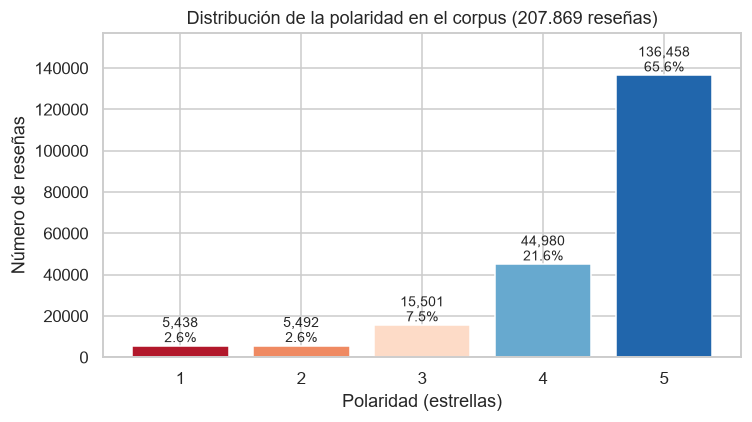

               n      %
Polarity               
1           5438   2.62
2           5492   2.64
3          15501   7.46
4          44980  21.64
5         136458  65.65

Ratio mayoritaria/minoritaria : 25.1 : 1
Polaridad media / mediana     : 4.45 / 5


In [11]:
# =========================================================================
# 3.2 · Distribución de la polaridad
# =========================================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
# Paleta fija por estrella, usada en TODO el notebook (rojo = malo, azul = bueno).
PALETA_POL = {1: "#b2182b", 2: "#ef8a62", 3: "#fddbc7", 4: "#67a9cf", 5: "#2166ac"}

conteo = df["Polarity"].value_counts().sort_index()
pct = conteo / conteo.sum() * 100

fig, ax = plt.subplots(figsize=(7, 4))
barras = ax.bar(conteo.index, conteo.values, color=[PALETA_POL[i] for i in conteo.index])
for b, n, p in zip(barras, conteo.values, pct):
    ax.text(b.get_x() + b.get_width() / 2, b.get_height(),
            f"{n:,}\n{p:.1f}%", ha="center", va="bottom", fontsize=9)
ax.set_xlabel("Polaridad (estrellas)")
ax.set_ylabel("Número de reseñas")
ax.set_title("Distribución de la polaridad en el corpus (207.869 reseñas)")
ax.set_ylim(0, conteo.max() * 1.15)
plt.tight_layout()
plt.show()

print(pd.DataFrame({"n": conteo, "%": pct.round(2)}).to_string())
print(f"\nRatio mayoritaria/minoritaria : {conteo.max() / conteo.min():.1f} : 1")
print(f"Polaridad media / mediana     : {df['Polarity'].mean():.2f} / {df['Polarity'].median():.0f}")

In [12]:
# =========================================================================
# 3.2 · Baseline de clase mayoritaria — de aquí sale la métrica principal
# =========================================================================
from sklearn.metrics import f1_score, accuracy_score

clase_mayoritaria = int(conteo.idxmax())
y_real = df["Polarity"].values
y_pred_may = np.full_like(y_real, clase_mayoritaria)

acc_may = accuracy_score(y_real, y_pred_may)
f1_may = f1_score(y_real, y_pred_may, average="macro", labels=[1, 2, 3, 4, 5], zero_division=0)
f1_por_clase = f1_score(y_real, y_pred_may, average=None, labels=[1, 2, 3, 4, 5], zero_division=0)

print(f"Baseline = predecir SIEMPRE {clase_mayoritaria}★ (sin leer el texto)")
print(f"  accuracy  = {acc_may:.4f}")
print(f"  macro-F1  = {f1_may:.4f}")
print(f"  F1 por clase 1..5 = {[round(v, 3) for v in f1_por_clase]}")

# Línea de referencia para TODAS las tablas de resultados.
BASELINE = {"clase": clase_mayoritaria, "accuracy": float(acc_may), "macro_f1": float(f1_may)}

Baseline = predecir SIEMPRE 5★ (sin leer el texto)
  accuracy  = 0.6565
  macro-F1  = 0.1585
  F1 por clase 1..5 = [np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.0), np.float64(0.793)]


La siguiente celda traduce ese desbalance en tres cosas concretas: cuánto pesará cada clase
al entrenar, si reformular la tarea ayudaría, y con cuántos ejemplos reales contaremos para
las clases poco frecuentes.

In [13]:
# =========================================================================
# 3.2 (extra) · Qué implica el desbalance para el modelado
# =========================================================================
# a) Pesos de clase para la pérdida (inverso de la frecuencia, normalizado a media 1)
frec = conteo / conteo.sum()
w = (1 / frec) / (1 / frec).sum() * len(conteo)
print("class_weight (1..5):", {e: round(v, 2) for e, v in zip([1, 2, 3, 4, 5], w)})
print(f"  -> un error en 1★ pesará ~{w[1] / w[5]:.0f}x más que uno en 5★\n")

# b) ¿Se escapa del desbalance reformulando la tarea?
c3 = pd.Series(np.select([df["Polarity"] <= 2, df["Polarity"] == 3],
                         ["neg (1-2)", "neu (3)"], "pos (4-5)")).value_counts(normalize=True) * 100
c2 = pd.Series(np.where(df["Polarity"] >= 4, "pos (4-5)", "no-pos (1-3)")).value_counts(normalize=True) * 100
print("Colapsando a 3 clases (%):\n", c3.round(1).to_string())
print("\nColapsando a binario (%):\n", c2.round(1).to_string())

# c) Ejemplos de entrenamiento por clase tras la submuestra estratificada de 40k (split 80%)
proj = (frec * CFG["submuestra"] * 0.8).round().astype(int)
print(f"\nEjemplos de train por clase con submuestra de {CFG['submuestra']:,}:")
print({e: int(v) for e, v in zip([1, 2, 3, 4, 5], proj)})

# d) MAE del baseline mayoritario (para completar su fila en las tablas de resultados)
mae_may = float(np.abs(y_real - clase_mayoritaria).mean())
BASELINE["mae"] = mae_may
print(f"\nMAE del baseline 'siempre 5★': {mae_may:.3f} estrellas")

class_weight (1..5): {1: 2.0, 2: 1.98, 3: 0.7, 4: 0.24, 5: 0.08}
  -> un error en 1★ pesará ~25x más que uno en 5★

Colapsando a 3 clases (%):
 pos (4-5)    87.3
neu (3)       7.5
neg (1-2)     5.3



Colapsando a binario (%):
 pos (4-5)       87.3
no-pos (1-3)    12.7

Ejemplos de train por clase con submuestra de 40,000:
{1: 837, 2: 845, 3: 2386, 4: 6924, 5: 21007}

MAE del baseline 'siempre 5★': 0.549 estrellas


Dos de cada tres reseñas tienen 5 estrellas y solo cinco de cada cien tienen 1 o 2. Este sesgo hacia lo positivo es habitual en sitios de reseñas, así que no es un error a corregir sino una característica del problema.

La consecuencia práctica es que el accuracy (porcentaje de aciertos) deja de servir: un modelo que responda siempre "5 estrellas", sin leer el texto, acierta el 65,7 % de las
veces. Por eso medimos el éxito con el macro-F1, que evalúa la calidad clase por clase y luego promedia; ese mismo modelo perezoso saca un macro-F1 de 0,16, porque falla por
completo en cuatro de las cinco clases. Todo el notebook usa macro-F1 como criterio, y el accuracy solo se muestra al lado de este baseline como referencia.

Para que los modelos no ignoren las clases raras, al entrenar daremos a cada clase un peso inverso a su frecuencia, es decir, un error en una reseña de 1★ pesará unas 25 veces más que uno en
una de 5★.

Aun así el problema no desaparece: agrupando en positivo/neutro/negativo el corpus sigue siendo 87 % positivo, y al reducirlo a 40.000 reseñas para que todo corra en tiempo razonable quedarán apenas ~840 ejemplos de 1★ y ~845 de 2★ para entrenar. Es
suficiente para que el macro-F1 sea informativo, pero poco para conclusiones finas sobre esas dos clases; lo consideraremos en las limitaciones.

### 3.3 Tipo de establecimiento, región y pueblo

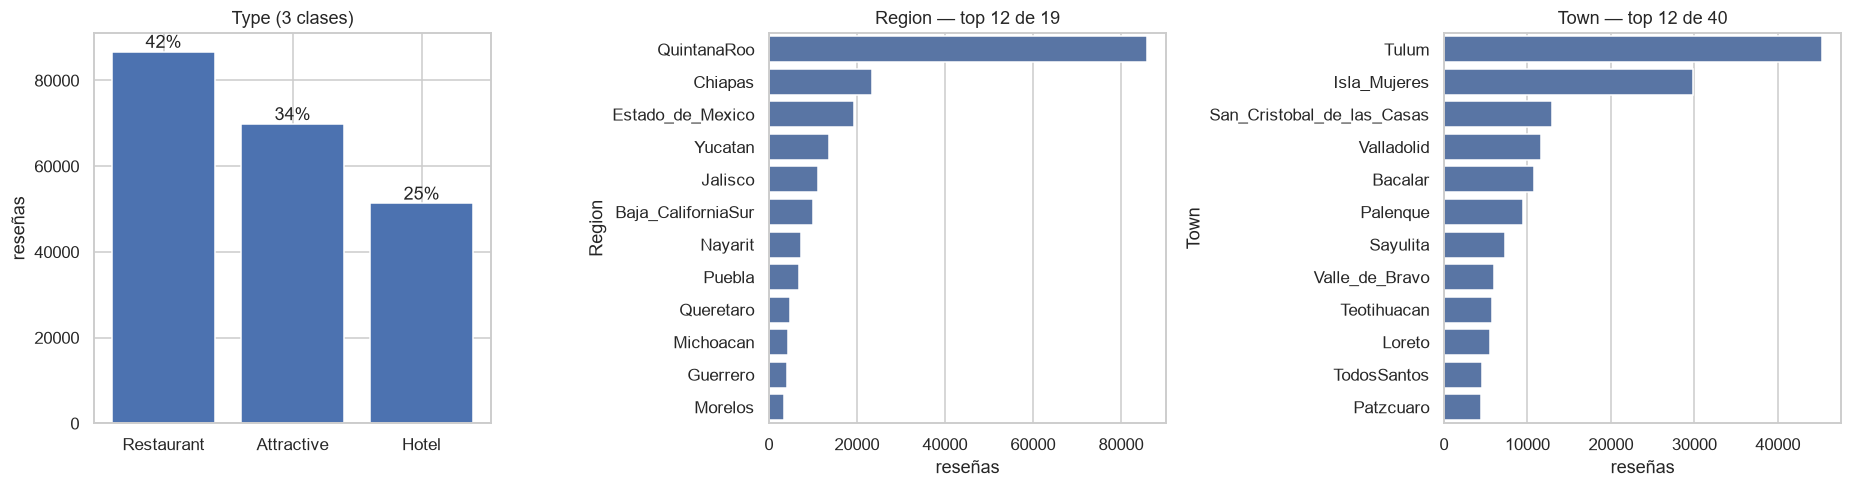

Type (%):
Type
Restaurant    41.7
Attractive    33.6
Hotel         24.7

Concentración geográfica:
  Quintana Roo         : 41.4%
  top 3 regiones       : 62.0%
  Tulum + Isla Mujeres : 36.2%

Regiones completas (n y %):
                        n      %
Region                          
QuintanaRoo         85985  41.36
Chiapas             23427  11.27
Estado_de_Mexico    19437   9.35
Yucatan             13621   6.55
Jalisco             11167   5.37
Baja_CaliforniaSur  10124   4.87
Nayarit              7337   3.53
Puebla               6830   3.29
Queretaro            4879   2.35
Michoacan            4453   2.14
Guerrero             4201   2.02
Morelos              3445   1.66
Veracruz             3335   1.60
San_Luis_Potosi      2217   1.07
Chihuahua            1786   0.86
Coahuila             1741   0.84
Hidalgo              1509   0.73
Oaxaca               1466   0.71
Guanajuato            909   0.44


In [14]:
# =========================================================================
# 3.3 · Tipo de establecimiento, región y pueblo
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(17, 4.6))

vc_type = df["Type"].value_counts()
axes[0].bar(vc_type.index, vc_type.values, color="#4c72b0")
for i, v in enumerate(vc_type.values):
    axes[0].text(i, v, f"{v / len(df) * 100:.0f}%", ha="center", va="bottom")
axes[0].set_title("Type (3 clases)"); axes[0].set_ylabel("reseñas")

vc_reg = df["Region"].value_counts()
sns.barplot(x=vc_reg.head(12).values, y=vc_reg.head(12).index, ax=axes[1], color="#4c72b0")
axes[1].set_title(f"Region — top 12 de {df['Region'].nunique()}"); axes[1].set_xlabel("reseñas")

vc_town = df["Town"].value_counts()
sns.barplot(x=vc_town.head(12).values, y=vc_town.head(12).index, ax=axes[2], color="#4c72b0")
axes[2].set_title(f"Town — top 12 de {df['Town'].nunique()}"); axes[2].set_xlabel("reseñas")

plt.tight_layout(); plt.show()

print("Type (%):")
print((vc_type / len(df) * 100).round(1).to_string())
print("\nConcentración geográfica:")
print(f"  Quintana Roo         : {vc_reg.iloc[0] / len(df) * 100:.1f}%")
print(f"  top 3 regiones       : {vc_reg.head(3).sum() / len(df) * 100:.1f}%")
print(f"  Tulum + Isla Mujeres : {vc_town.head(2).sum() / len(df) * 100:.1f}%")
print("\nRegiones completas (n y %):")
print(pd.DataFrame({"n": vc_reg, "%": (vc_reg / len(df) * 100).round(2)}).to_string())

El tipo de establecimiento está bastante repartido: 41.7 % restaurantes, 33.6 % atracciones (museos, playas, zonas arqueológicas) y 24.7 % hoteles. Es lo contrario al caso de la polaridad. Por eso, nos puede convenir usar `Type` como tarea de control: si un mismo modelo clasifica bien
el tipo pero mal las estrellas, la dificultad está en la tarea de polaridad, no en el modelo.

La geografía, en cambio, está muy concentrada. Quintana Roo (Cancún, Tulum, Isla Mujeres, Bacalar) reúne el 41 % de las reseñas, las tres regiones más grandes suman el 62 %, y solo
Tulum e Isla Mujeres ya son el 36 %. De las 19 regiones, muchas aportan menos del 1 %.

Aqui hay un riesgo para el modelo, si entrenamos y evaluamos mezclando al azar, el modelo ve durante el entrenamiento reseñas de los mismos hoteles y playas que luego tiene que calificar, y podría aprender a reconocer el destino (nombres propios, topónimos) en lugar del sentimiento.

In [15]:
# (opcional) polaridad media por tipo y por región — anticipo de 3.6
print("Polaridad media por Type:")
print(df.groupby("Type")["Polarity"].mean().round(2).to_string())
print("\nPolaridad media — regiones del held-out del Split B vs. resto:")
ho = ["Chiapas", "Baja_CaliforniaSur", "Queretaro"]
print(f"  held-out : {df[df.Region.isin(ho)]['Polarity'].mean():.2f}")
print(f"  resto    : {df[~df.Region.isin(ho)]['Polarity'].mean():.2f}")

Polaridad media por Type:
Type
Attractive    4.52
Hotel         4.32
Restaurant    4.47

Polaridad media — regiones del held-out del Split B vs. resto:
  held-out : 4.44
  resto    : 4.45


Los hoteles reciben calificaciones algo más bajas que atracciones y restaurantes (4,32
frente a 4,52 y 4,47), aunque la diferencia es pequeña y todas las medias siguen muy altas.
Y las tres regiones que podríamos dejar fuera para una prueba de generalización tienen una
polaridad media (4,44) casi idéntica a la del resto (4,45): esa eventual partición no
arrancaría sesgada por el lado de las etiquetas. Queda como observación.

### 3.4 Longitud de las reseñas → de dónde sale `MAX_LEN`

Los notebooks guía fijan la longitud de secuencia en 256 o 512 tokens sin justificarlo.
Aquí la derivamos de la distribución real: `MAX_LEN` será el percentil 95 en tokens, y
reportaremos qué fracción de reseñas queda truncada.

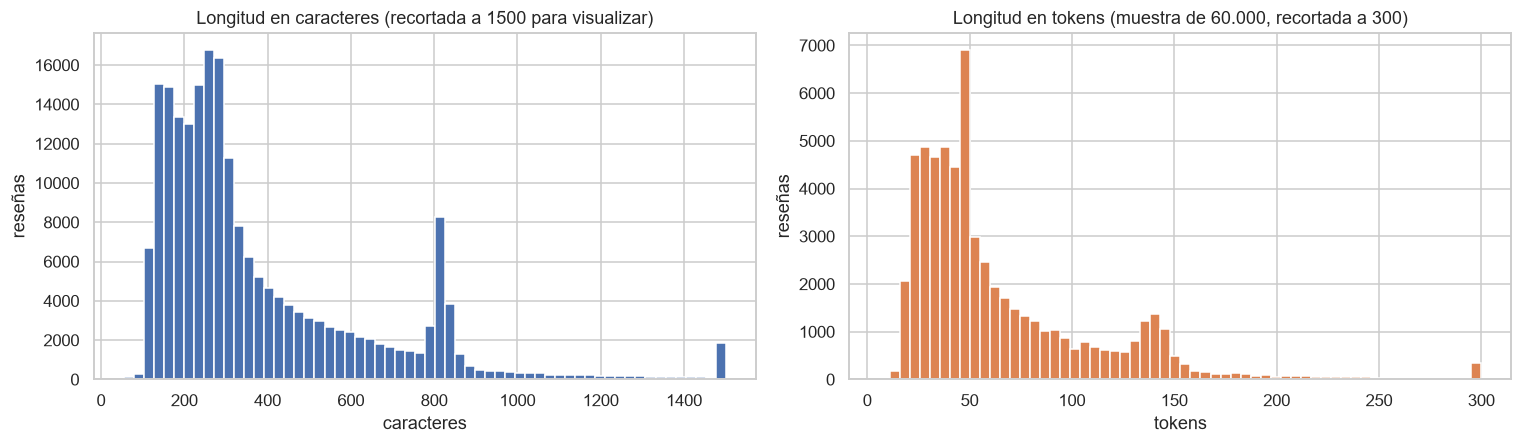

 percentil  caracteres  tokens
        50         284      48
        75         472      81
        90         803     136
        95         839     148
        99        1424     244

Mediana de tokens : 48
MAX_LEN (percentil 95 en tokens, redondeado a decena) = 150
Con ese límite se trunca el 4.4% de las reseñas (solo la cola larga).


In [16]:
# =========================================================================
# 3.4 · Longitud de las reseñas (caracteres y tokens) -> MAX_LEN
# =========================================================================
import re

# Tokenizador de trabajo solo para medir longitudes. El definitivo se fija en 4.1,
# pero usa el mismo criterio: minúsculas, se parte por lo que no sea letra o número,
# se conservan tildes y ñ.
_re_tok = re.compile(r"[^a-záéíóúüñ0-9]+")
def _tok(t):
    return [x for x in _re_tok.sub(" ", t.lower()).split() if x]

df["n_car"] = df["texto"].str.len()

# Contar tokens en las 207k reseñas es lento; usamos una muestra grande y reproducible.
muestra_tok = df["texto"].sample(60000, random_state=SEED).map(lambda t: len(_tok(t)))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
axes[0].hist(df["n_car"].clip(upper=1500), bins=60, color="#4c72b0")
axes[0].set_title("Longitud en caracteres (recortada a 1500 para visualizar)")
axes[0].set_xlabel("caracteres"); axes[0].set_ylabel("reseñas")
axes[1].hist(muestra_tok.clip(upper=300), bins=60, color="#dd8452")
axes[1].set_title("Longitud en tokens (muestra de 60.000, recortada a 300)")
axes[1].set_xlabel("tokens"); axes[1].set_ylabel("reseñas")
plt.tight_layout(); plt.show()

pcts = [50, 75, 90, 95, 99]
tabla_long = pd.DataFrame({
    "percentil": pcts,
    "caracteres": np.percentile(df["n_car"], pcts).round().astype(int),
    "tokens": np.percentile(muestra_tok, pcts).round().astype(int),
})
print(tabla_long.to_string(index=False))

MAX_LEN = int(round(np.percentile(muestra_tok, 95) / 10) * 10)
trunc = (muestra_tok > MAX_LEN).mean()
print(f"\nMediana de tokens : {int(muestra_tok.median())}")
print(f"MAX_LEN (percentil 95 en tokens, redondeado a decena) = {MAX_LEN}")
print(f"Con ese límite se trunca el {trunc * 100:.1f}% de las reseñas (solo la cola larga).")

La mayoría de las reseñas son cortas: la mitad tiene 48 palabras o menos y el 90 % cabe en 136. Pero hay una cola larga que llega a más de 240. Fijamos el límite de longitud (`MAX_LEN`) en 150 palabras, que es el percentil 95: con eso solo se recorta el 4,4 % de las reseñas, y siempre por el final, que suele ser la parte menos informativa.

En los histogramas hay un pico alrededor de las 140 palabras (unos 800 caracteres) que parece un corte fijo del proceso de descarga de las reseñas, no algo propio del lenguaje. El pico del extremo derecho de cada gráfica es solo el efecto de amontonar ahí todo lo que se sale del rango dibujado; los valores reales están en la tabla de percentiles.

### 3.5 Léxico distintivo por polaridad

Las frecuencias crudas están dominadas por palabras funcionales y no distinguen nada. Usamos
**log-odds ratio con prior de Dirichlet**, que mide qué tan sobrerrepresentado está un
término en una clase respecto al resto del corpus y es robusto ante términos poco frecuentes.

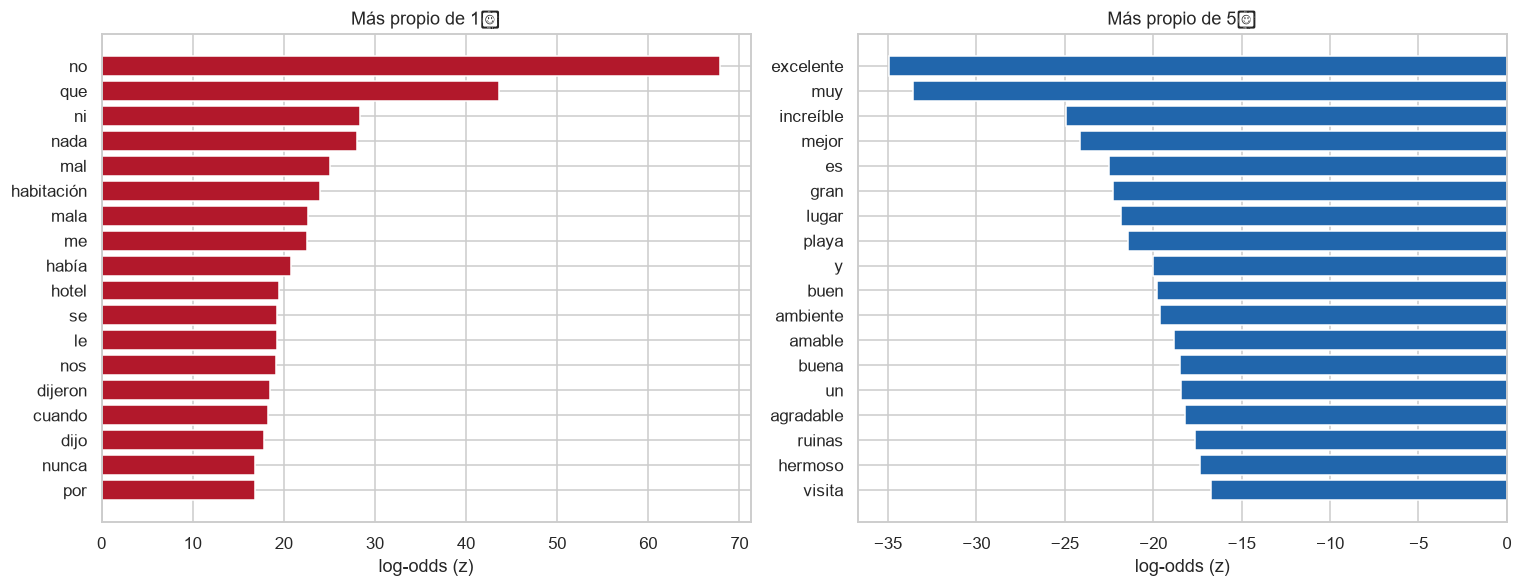

LEXICO[1] (1★): ['no', 'que', 'ni', 'nada', 'mal', 'habitación', 'mala', 'me', 'había', 'hotel', 'se', 'le', 'nos', 'dijeron', 'cuando', 'dijo', 'nunca', 'por']
LEXICO[5] (5★): ['excelente', 'muy', 'increíble', 'mejor', 'es', 'gran', 'lugar', 'playa', 'y', 'buen', 'ambiente', 'amable', 'buena', 'un', 'agradable', 'ruinas', 'hermoso', 'visita']


In [17]:
# =========================================================================
# 3.5 · Léxico distintivo: 1★ frente a 5★ (log-odds con prior de Dirichlet)
# =========================================================================
from collections import Counter

def log_odds(textos_a, textos_b, alpha=0.01, top=18, min_freq=10):
    """z-score de log-odds (Monroe et al. 2008): qué términos distinguen A de B."""
    ca, cb = Counter(), Counter()
    for t in textos_a: ca.update(_tok(t))
    for t in textos_b: cb.update(_tok(t))
    vocab = set(ca) | set(cb)
    na, nb, a0 = sum(ca.values()), sum(cb.values()), alpha * len(vocab)
    z = {}
    for w in vocab:
        if ca[w] + cb[w] < min_freq:
            continue
        la = np.log((ca[w] + alpha) / (na + a0 - ca[w] - alpha))
        lb = np.log((cb[w] + alpha) / (nb + a0 - cb[w] - alpha))
        z[w] = (la - lb) / np.sqrt(1.0 / (ca[w] + alpha) + 1.0 / (cb[w] + alpha))
    ordenado = sorted(z.items(), key=lambda kv: kv[1])
    return ordenado[-top:][::-1], ordenado[:top]   # (más de A, más de B)

txt_1 = df.loc[df["Polarity"] == 1, "texto"]
txt_5 = df.loc[df["Polarity"] == 5, "texto"].sample(len(txt_1) * 2, random_state=SEED)
mas_1, mas_5 = log_odds(txt_1, txt_5)
LEXICO = {1: [w for w, _ in mas_1], 5: [w for w, _ in mas_5]}

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
for ax, datos, titulo, color in [(axes[0], mas_1, "Más propio de 1★", "#b2182b"),
                                 (axes[1], mas_5, "Más propio de 5★", "#2166ac")]:
    palabras, scores = zip(*datos)
    ax.barh(range(len(palabras)), scores, color=color)
    ax.set_yticks(range(len(palabras))); ax.set_yticklabels(palabras); ax.invert_yaxis()
    ax.set_title(titulo); ax.set_xlabel("log-odds (z)")
plt.tight_layout(); plt.show()

print("LEXICO[1] (1★):", LEXICO[1])
print("LEXICO[5] (5★):", LEXICO[5])

En las reseñas de 1★ lo que más pesa es la negación: "no", "ni", "nada", "nunca". Es un hallazgo relevante en cuanto a elegir el modelo, porque un enfoque de bolsa de palabras (que cuenta términos sin mirar el orden) no puede distinguir "no recomiendo" de "recomiendo".
También aparecen mucho "dijeron", "dijo", "nos": en las reseñas malas la gente reconstruye conversaciones con el personal. Y "habitación" y "hotel" se inclinan al lado negativo, lo que encaja con que los hoteles tenían la media de estrellas más baja.

En 5★ dominan los adjetivos de entusiasmo ("excelente", "increíble", "hermoso", "amable", "agradable") mezclados con palabras de lugar ("playa", "ruinas", "lugar", "visita"). Esto
último conviene tenerlo en cuenta: parte de la señal no es sentimiento puro sino relacionado al tema (las atracciones reciben mejores calificaciones que los hoteles), así que un modelo podría acertar en parte fijándose en de qué habla la reseña y no en cómo la valora.

Guardamos ambas listas en `LEXICO` para tenerlas como referencia.

### 3.6 Interacciones

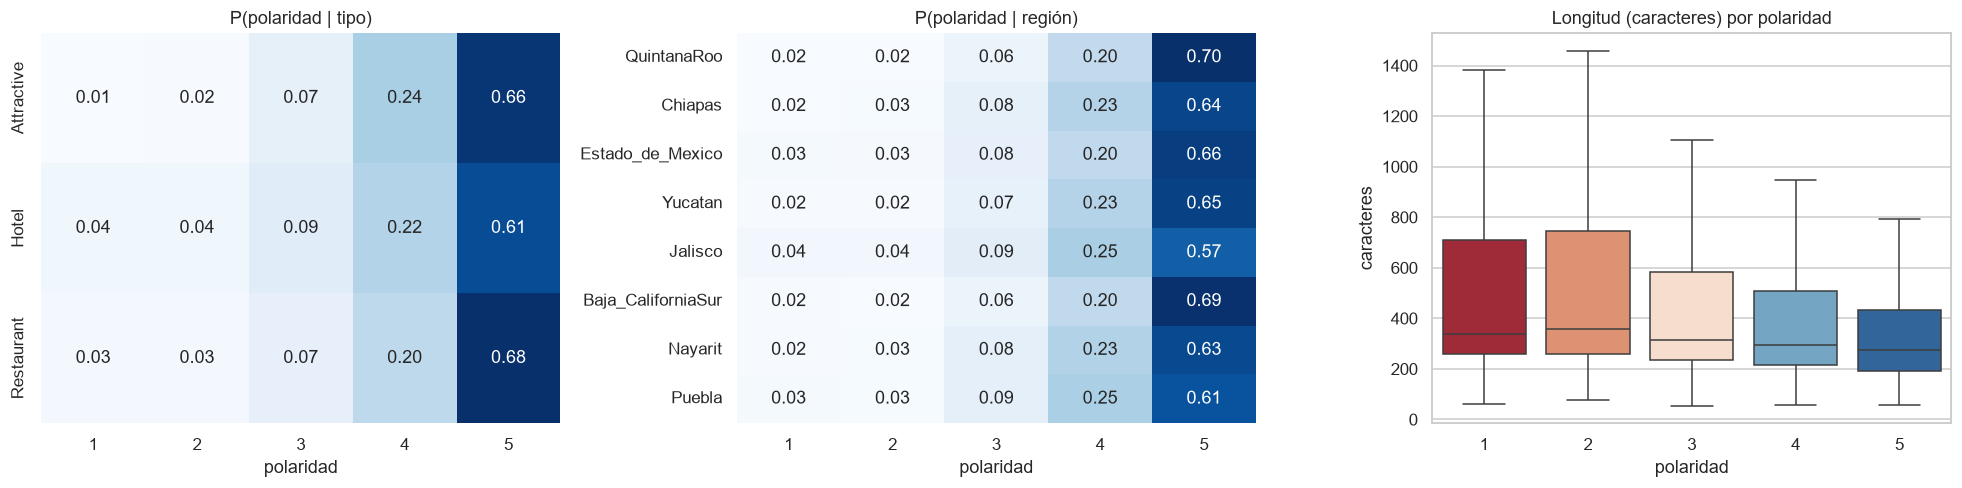

Longitud mediana (caracteres) por polaridad:
Polarity
1    339.0
2    358.0
3    313.0
4    295.0
5    274.0

Polaridad media por región (top 8), de menor a mayor:
Region
Jalisco               4.27
Puebla                4.37
Nayarit               4.42
Estado_de_Mexico      4.43
Chiapas               4.45
Yucatan               4.46
Baja_CaliforniaSur    4.52
QuintanaRoo           4.53


In [18]:
# =========================================================================
# 3.6 · Interacciones: polaridad × tipo, × región, × longitud
# =========================================================================
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))

# 1) P(polaridad | tipo)
ct = pd.crosstab(df["Type"], df["Polarity"], normalize="index")
sns.heatmap(ct, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[0])
axes[0].set_title("P(polaridad | tipo)"); axes[0].set_xlabel("polaridad"); axes[0].set_ylabel("")

# 2) P(polaridad | región) para las 8 regiones con más reseñas
top8 = df["Region"].value_counts().head(8).index
cr = pd.crosstab(df.loc[df["Region"].isin(top8), "Region"], df["Polarity"], normalize="index")
cr = cr.loc[top8]  # ordenadas por volumen
sns.heatmap(cr, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=axes[1])
axes[1].set_title("P(polaridad | región)"); axes[1].set_xlabel("polaridad"); axes[1].set_ylabel("")

# 3) longitud (caracteres) por polaridad
sns.boxplot(data=df, x="Polarity", y="n_car", hue="Polarity", legend=False,
            palette=PALETA_POL, showfliers=False, ax=axes[2])
axes[2].set_title("Longitud (caracteres) por polaridad")
axes[2].set_xlabel("polaridad"); axes[2].set_ylabel("caracteres")

plt.tight_layout(); plt.show()

print("Longitud mediana (caracteres) por polaridad:")
print(df.groupby("Polarity")["n_car"].median().to_string())
print("\nPolaridad media por región (top 8), de menor a mayor:")
print(df[df["Region"].isin(top8)].groupby("Region")["Polarity"].mean().round(2).sort_values().to_string())

El sesgo positivo es bastante parejo. Por tipo, los hoteles concentran algo más de reseñas negativas (4 % de 1★ y 4 % de 2★, frente al 1–2 % de las atracciones) y algo menos de 5★, aunque la diferencia es moderada.

Por región, la proporción de 5★ va del 57 % (Jalisco) al 70 % (Quintana Roo), y las tres regiones que podríamos apartar para una prueba de generalización (Chiapas, Baja California Sur, Querétaro) caen dentro de ese rango: apartarlas no cambiaría de forma brusca la mezcla de etiquetas.

La longitud sí se relaciona con la polaridad: las reseñas negativas son más largas (mediana de ~340–360 caracteres en 1★ y 2★, frente a ~275 en 5★).
Esto tiene sentido, quien se queja justifica el enojo con detalle, mientras que un "todo excelente" se despacha en una frase.

### 3.7 Cobertura del vocabulario frente a los embeddings preentrenados

El modelo 3 inicializará sus embeddings con vectores de spaCy entrenados sobre español
general. Antes de hacerlo, medimos cuánto de nuestro vocabulario turístico y regional está
efectivamente cubierto.

In [19]:
# =========================================================================
# 3.7 · Cobertura del vocabulario en los vectores de spaCy (es_core_news_lg)
# =========================================================================
import spacy

nlp_vec = spacy.load("es_core_news_lg")
print("Vectores en es_core_news_lg:", nlp_vec.vocab.vectors.shape, "(nº de palabras × dimensiones)")

# Vocabulario del corpus (muestra de 50.000 reseñas para que sea rápido)
cont_vocab = Counter()
for t in df["texto"].sample(50000, random_state=SEED):
    cont_vocab.update(_tok(t))

tipos = list(cont_vocab)
con_vector = [w for w in tipos if nlp_vec.vocab[w].has_vector]
cob_tipos = len(con_vector) / len(tipos)
cob_tokens = sum(cont_vocab[w] for w in con_vector) / sum(cont_vocab.values())

oov = [(w, n) for w, n in cont_vocab.most_common() if not nlp_vec.vocab[w].has_vector][:25]

print(f"\nPalabras distintas en el corpus (muestra): {len(tipos):,}")
print(f"Cobertura por TIPOS  (palabras distintas con vector): {cob_tipos * 100:.1f}%")
print(f"Cobertura por TOKENS (apariciones cubiertas)        : {cob_tokens * 100:.1f}%")
print("\nPalabras frecuentes SIN vector (OOV):")
for w, n in oov:
    print(f"  {w:22s} {n}")

Vectores en es_core_news_lg: (500000, 300) (nº de palabras × dimensiones)



Palabras distintas en el corpus (muestra): 56,301
Cobertura por TIPOS  (palabras distintas con vector): 74.4%
Cobertura por TOKENS (apariciones cubiertas)        : 99.1%

Palabras frecuentes SIN vector (OOV):
  bacalar                953
  sayulita               817
  taxco                  503
  chichen                415
  ajijic                 309
  tlaquepaque            304
  teotihuacan            276
  pátzcuaro              229
  izamal                 216
  patzcuaro              189
  ziggy                  173
  creel                  172
  tequisquiapan          144
  rolandi                143
  tepoztlán              121
  nautibeach             113
  mazunte                109
  tepozteco              105
  covid                  103
  teotihuacán            102
  malinalco              98
  qubano                 98
  atlixco                97
  mayan                  95
  xilitla                89


Casi todas las palabras que aparecen en las reseñas (99,1 % de las apariciones) tienen vector preentrenado. La cobertura baja al 74 % si contamos palabras distintas, pero lo que
falta son casi en su totalidad nombres propios: destinos (Bacalar, Sayulita, Taxco, Chichén,
Teotihuacán) y nombres de hoteles y restaurantes (Ziggy, Rolandi, Nautibeach). Vocabulario
de sentimiento sin cubrir prácticamente no hay.

Esto tiene dos lecturas. Partir de vectores preentrenados es una buena apuesta, porque el modelo no tiene que aprender desde cero qué significan "excelente" o "pésimo". Y como los nombres de lugar no tienen vector, un modelo que los use tal cual no puede apoyarse en el destino para adivinar la nota; en cambio, si dejamos que ajuste los vectores durante el entrenamiento, podría construir representaciones para esos nombres y usarlas como atajo.

Por eso conviene probar las dos variantes, vectores congelados y vectores ajustados, y comparar.
También se nota algo de ruido ortográfico: "pátzcuaro" y "patzcuaro", "teotihuacán" y "teotihuacan", cuentan como palabras distintas por la tilde.

In [20]:
# =========================================================================
# 3.7b · Tres cifras para cerrar el diagnóstico
# =========================================================================
# (1) ¿Por qué un vocabulario de 30.000? Cobertura de apariciones según el corte.
cont_full = Counter()
for t in df["texto"].sample(80000, random_state=SEED):
    cont_full.update(_tok(t))
total = sum(cont_full.values())
print("Cobertura de apariciones según el tamaño de vocabulario:")
for k in (10000, 20000, 30000, 50000):
    cub = sum(n for _, n in cont_full.most_common(k))
    print(f"  vocab {k:>6,} -> {cub / total * 100:.2f}%")
print(f"  (palabras distintas en la muestra: {len(cont_full):,})")

# (2) Ruido de etiqueta: texto que contradice las estrellas.
neg_fuerte = {"pésimo", "pesimo", "horrible", "terrible", "asqueroso", "sucio", "estafa",
              "engaño", "robo", "nunca", "jamás", "malísimo", "peor"}
pos_fuerte = {"excelente", "maravilloso", "hermoso", "increíble", "perfecto", "espectacular",
              "encantó", "encanto", "recomiendo"}
def contiene(texto, palabras):
    return len(set(_tok(texto)) & palabras) > 0

r5 = df.loc[df["Polarity"] == 5, "texto"].map(lambda t: contiene(t, neg_fuerte)).mean()
r1 = df.loc[df["Polarity"] == 1, "texto"].map(lambda t: contiene(t, pos_fuerte)).mean()
print(f"\nReseñas de 5★ con vocabulario muy negativo en el texto: {r5 * 100:.1f}%")
print(f"Reseñas de 1★ con vocabulario muy positivo en el texto: {r1 * 100:.1f}%")

# (3) Densidad de negación por polaridad (negaciones por cada 100 palabras).
neg_tok = {"no", "ni", "nada", "nunca", "tampoco", "jamás", "sin"}
def dens_neg(texto):
    toks = _tok(texto)
    return sum(w in neg_tok for w in toks) / max(len(toks), 1) * 100
print("\nNegaciones por cada 100 palabras, según la polaridad:")
for p in (1, 2, 3, 4, 5):
    s = df.loc[df["Polarity"] == p, "texto"].sample(
        min(5000, int((df["Polarity"] == p).sum())), random_state=SEED)
    print(f"  {p}★: {s.map(dens_neg).mean():.2f}")

Cobertura de apariciones según el tamaño de vocabulario:
  vocab 10,000 -> 96.73%
  vocab 20,000 -> 98.47%
  vocab 30,000 -> 99.08%
  vocab 50,000 -> 99.59%
  (palabras distintas en la muestra: 71,266)



Reseñas de 5★ con vocabulario muy negativo en el texto: 3.3%
Reseñas de 1★ con vocabulario muy positivo en el texto: 15.3%

Negaciones por cada 100 palabras, según la polaridad:
  1★: 3.75


  2★: 3.47
  3★: 2.72


  4★: 1.39
  5★: 1.11


### 3.8 Síntesis: del hallazgo a la decisión


| Hallazgo del EDA | Decisión que induce |
|---|---|
| El corpus trae mojibake y colas "...Más" de TripAdvisor, pero cero reseñas vacías y solo 182 duplicados exactos. | Se corrige el texto (`ftfy` + recorte) y se eliminan los duplicados; nada más. Corpus de trabajo: 207.869 reseñas. |
| El 66 % de las reseñas son 5★; predecir siempre "5" da 65,7 % de accuracy pero 0,16 de macro-F1. | La métrica principal es **macro-F1**. El accuracy solo se reporta junto a este baseline. |
| Las clases 1★ y 2★ juntas son el 5 %; tras reducir a 40.000 reseñas quedan ~840 ejemplos de cada una. | Se pondera cada clase por el inverso de su frecuencia al entrenar, y se asume desde ya que las métricas de 1★ y 2★ serán ruidosas (limitación). |
| Longitudes muy asimétricas: mediana 48 palabras, percentil 95 = 148. | **`MAX_LEN` = 150 palabras** (percentil 95); trunca solo el 4 % de las reseñas. |
| En 1★ domina la negación: 3,75 por cada 100 palabras, frente a 1,11 en 5★. | Una bolsa de palabras no distingue "no recomiendo" de "recomiendo": se justifica probar modelos que miran el orden (LSTM) y en ambos sentidos (bidireccional). |
| El 99 % de las apariciones tiene vector preentrenado; lo que falta son nombres de destinos y de hoteles. | Se inicializan los embeddings con los de spaCy y se prueban **congelados y ajustados**, porque ajustar podría reintroducir el destino como atajo. |
| Quintana Roo es el 41 % del corpus; con partición aleatoria el modelo ve en entrenamiento los mismos destinos que evalúa. | Se prueba además una **partición geográfica** (Chiapas, Baja California Sur y Querétaro fuera del entrenamiento) para medir generalización a destinos nuevos. |
| La escala 1–5 está ordenada: confundir 4★ con 5★ no equivale a confundir 1★ con 5★. | Además de macro-F1 se reportan **MAE y QWK**, y se prueba una formulación de regresión con umbrales. |
| `Type` está equilibrado (42/34/25) y no es ordinal. | Sirve de **tarea de control**: la misma arquitectura sobre `Type` dirá si un macro-F1 flojo en polaridad es culpa de la tarea o del modelo. |
| El 15 % de las reseñas de 1★ usan vocabulario muy positivo (y el 3 % de las de 5★, muy negativo). | Hay ruido de etiqueta y reseñas mixtas; ponen un techo al rendimiento y se analizan en la sección de errores. |

---

## 4. Preprocesamiento y protocolo experimental

Para que la comparación entre cuatro modelos signifique algo, todos deben ver exactamente
los mismos datos, la misma partición y las mismas métricas. Esta sección fija ese contrato.

### 4.1 Tokenización

Partimos del tokenizador del notebook guía y corregimos dos cosas: construimos el vocabulario
**por frecuencia** (el notebook 4 lo hace por orden de aparición, ver `docs/DECISIONS.md`
§D-002) y verificamos que la normalización preserve tildes y ñ.

In [21]:
# =========================================================================
# 4.1 · Tokenizador definitivo y construcción del vocabulario
# =========================================================================
_RE_TOKEN = re.compile(r"[^a-záéíóúüñ0-9]+")

def tokenizar(texto: str):
    """Minúsculas; se parte por todo lo que no sea letra o número; se conservan
    tildes y ñ. Mismo criterio que se usó en el EDA."""
    return [t for t in _RE_TOKEN.sub(" ", texto.lower()).split() if t]

PAD, UNK = 0, 1

def construir_vocab(textos, max_vocab):
    """Vocabulario por FRECUENCIA (most_common), con [PAD]=0 y [UNK]=1 reservados.
    El notebook 4 del curso lo construye por orden de aparición: sobre un Counter
    eso no da los tokens más frecuentes sino los que aparecieron primero."""
    cont = Counter()
    for t in textos:
        cont.update(tokenizar(t))
    vocab = {"[PAD]": PAD, "[UNK]": UNK}
    for palabra, _ in cont.most_common(max_vocab - 2):
        vocab[palabra] = len(vocab)
    return vocab

ej = df["texto"].iloc[0]
print("Reseña :", ej[:150], "...")
print("Tokens :", tokenizar(ej)[:25], "...")
print("\nEl vocabulario definitivo se construye en 4.2, solo con el texto de entrenamiento.")

Reseña : Mi Lugar Favorito!!!!. Excelente lugar para comer y pasar una buena noche!!!
El servicio es de primera y la comida exquisita!!! ...
Tokens : ['mi', 'lugar', 'favorito', 'excelente', 'lugar', 'para', 'comer', 'y', 'pasar', 'una', 'buena', 'noche', 'el', 'servicio', 'es', 'de', 'primera', 'y', 'la', 'comida', 'exquisita'] ...

El vocabulario definitivo se construye en 4.2, solo con el texto de entrenamiento.


In [22]:
# --- Cómo se convierte una reseña en entrada para el modelo: tokens -> ids -> padding ---
def codificar(texto, vocab, max_len=MAX_LEN):
    ids = [vocab.get(t, UNK) for t in tokenizar(texto)[:max_len]]
    n_real = max(len(ids), 1)                 # longitud antes del relleno
    ids += [PAD] * (max_len - len(ids))
    return ids, n_real

# Vocabulario temporal (solo para esta demostración; el real se hace en 4.2)
_vocab_demo = construir_vocab(df["texto"], CFG["max_vocab"])
_id2tok = {i: t for t, i in _vocab_demo.items()}

frase = "El hotel estaba sucio y el sargazo cubría toda la playa. No volvería."
ids, n = codificar(frase, _vocab_demo, max_len=20)
print("Texto        :", frase)
print("Tokens       :", tokenizar(frase))
print("IDs          :", ids)
print("Reconstruido :", [_id2tok[i] for i in ids])
print(f"\n{n} tokens reales; los otros {20 - n} son [PAD] (relleno para que todas las")
print("secuencias tengan el mismo largo y se puedan procesar por lotes).")
del _vocab_demo, _id2tok

Texto        : El hotel estaba sucio y el sargazo cubría toda la playa. No volvería.
Tokens       : ['el', 'hotel', 'estaba', 'sucio', 'y', 'el', 'sargazo', 'cubría', 'toda', 'la', 'playa', 'no', 'volvería']
IDs          : [5, 31, 61, 1540, 3, 5, 2041, 23470, 233, 4, 35, 14, 590, 0, 0, 0, 0, 0, 0, 0]
Reconstruido : ['el', 'hotel', 'estaba', 'sucio', 'y', 'el', 'sargazo', 'cubría', 'toda', 'la', 'playa', 'no', 'volvería', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']

13 tokens reales; los otros 7 son [PAD] (relleno para que todas las
secuencias tengan el mismo largo y se puedan procesar por lotes).


El tokenizador parte el texto en palabras, pasa todo a minúsculas y elimina signos y saltos
de línea, pero conserva tildes y ñ (importante en español). Cada palabra se sustituye por un
número, que es su posición en el vocabulario; las palabras que no estén en el vocabulario se
marcan como `[UNK]`, y las secuencias más cortas que `MAX_LEN` se completan con `[PAD]` para
que todos los ejemplos tengan el mismo largo y se puedan procesar por lotes.

El vocabulario se ordena por frecuencia: las palabras más comunes ("el", "y", "la") reciben
los números más bajos y las raras ("cubría"), los más altos. En el ejemplo, las 13 palabras
reales caben de sobra en el límite de 150 y ninguna quedó fuera del vocabulario.

### 4.2 Submuestra y particiones

Entrenamos sobre 40,000 reseñas estratificadas por polaridad. **No balanceamos las clases**:
el desbalance es una propiedad del dominio que queremos estudiar, no un defecto que ocultar.

In [23]:
# =========================================================================
# 4.2 · Submuestra estratificada
# =========================================================================
from sklearn.model_selection import train_test_split

N_SUB = min(CFG["submuestra"], len(df))
sub, _ = train_test_split(df, train_size=N_SUB, random_state=SEED, stratify=df["Polarity"])
sub = sub.reset_index(drop=True)

comp = pd.DataFrame({
    "corpus (%)":     (df["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2),
    "submuestra (%)": (sub["Polarity"].value_counts(normalize=True).sort_index() * 100).round(2),
    "n en submuestra": sub["Polarity"].value_counts().sort_index(),
})
print(f"Submuestra: {len(sub):,} reseñas (de {len(df):,}), estratificada por polaridad.")
print(comp.to_string())

Submuestra: 40,000 reseñas (de 207,869), estratificada por polaridad.
          corpus (%)  submuestra (%)  n en submuestra
Polarity                                             
1               2.62            2.62             1046
2               2.64            2.64             1057
3               7.46            7.46             2983
4              21.64           21.64             8655
5              65.65           65.65            26259


La submuestra de 40.000 reseñas conserva exactamente las proporciones del corpus (66 % de
5★, 2,6 % de 1★).

In [24]:
# =========================================================================
# 4.2 · Split A — aleatorio estratificado 80/10/10 (protocolo estándar)
# =========================================================================
idx = np.arange(len(sub))
y = sub["Polarity"].values

idx_tr, idx_tmp = train_test_split(idx, test_size=0.20, random_state=SEED, stratify=y)
idx_va, idx_te = train_test_split(idx_tmp, test_size=0.50, random_state=SEED, stratify=y[idx_tmp])
SPLIT_A = {"train": idx_tr, "val": idx_va, "test": idx_te}

print("Split A:")
for k, v in SPLIT_A.items():
    d = (pd.Series(y[v]).value_counts(normalize=True).sort_index() * 100).round(1)
    print(f"  {k:5s}: {len(v):>6,} reseñas  |  % por estrella: {d.tolist()}")

# Vocabulario definitivo: SOLO con el texto de entrenamiento de Split A (sin fuga)
vocab = construir_vocab(sub.iloc[SPLIT_A["train"]]["texto"], CFG["max_vocab"])
id2tok = {i: t for t, i in vocab.items()}
print(f"\nVocabulario definitivo: {len(vocab):,} tokens")

# Tasa de [UNK] y de truncamiento sobre el conjunto de test
unk = tot = trunc = 0
for t in sub.iloc[SPLIT_A["test"]]["texto"]:
    toks = tokenizar(t)
    tot += len(toks); unk += sum(w not in vocab for w in toks); trunc += len(toks) > MAX_LEN
print(f"En test -> tokens fuera del vocabulario: {unk / tot * 100:.1f}%  |  "
      f"reseñas truncadas por MAX_LEN: {trunc / len(SPLIT_A['test']) * 100:.1f}%")

Split A:
  train: 32,000 reseñas  |  % por estrella: [2.6, 2.6, 7.5, 21.6, 65.6]
  val  :  4,000 reseñas  |  % por estrella: [2.6, 2.6, 7.4, 21.6, 65.6]
  test :  4,000 reseñas  |  % por estrella: [2.6, 2.6, 7.5, 21.6, 65.6]



Vocabulario definitivo: 30,000 tokens
En test -> tokens fuera del vocabulario: 1.5%  |  reseñas truncadas por MAX_LEN: 4.2%


El Split A la divide en 80/10/10 manteniendo esas proporciones en las tres partes, así que entrenamiento, validación y prueba son comparables entre sí. El vocabulario definitivo (30.000 palabras, construido solo con el texto de entrenamiento) deja fuera apenas el 1,5 % de las palabras del test, y el límite de 150 palabras trunca el 4,2 %, es decir, perdidas pequeñas.

In [25]:
# =========================================================================
# 4.2 · Split B — geográfico (regiones fuera del entrenamiento)
# =========================================================================
REGIONES_FUERA = ["Chiapas", "Baja_CaliforniaSur", "Queretaro"]

es_fuera = sub["Region"].isin(REGIONES_FUERA).values
idx_b_test = idx[es_fuera]
idx_b_rest = idx[~es_fuera]
idx_b_tr, idx_b_va = train_test_split(idx_b_rest, test_size=0.12, random_state=SEED,
                                      stratify=y[idx_b_rest])
SPLIT_B = {"train": idx_b_tr, "val": idx_b_va, "test": idx_b_test}

print(f"Regiones fuera del entrenamiento: {REGIONES_FUERA}")
for k, v in SPLIT_B.items():
    print(f"  {k:5s}: {len(v):>6,} reseñas")

print("\nComprobación de que el test geográfico no está sesgado:")
print(f"  polaridad media : {sub.iloc[idx_b_test]['Polarity'].mean():.2f}  vs  "
      f"{sub.iloc[idx_b_rest]['Polarity'].mean():.2f}  (resto)")
print(f"  % hoteles       : {(sub.iloc[idx_b_test]['Type'] == 'Hotel').mean() * 100:.0f}%  vs  "
      f"{(sub.iloc[idx_b_rest]['Type'] == 'Hotel').mean() * 100:.0f}%  (resto)")
print(f"  % 5★            : {(sub.iloc[idx_b_test]['Polarity'] == 5).mean() * 100:.0f}%  vs  "
      f"{(sub.iloc[idx_b_rest]['Polarity'] == 5).mean() * 100:.0f}%  (resto)")

Regiones fuera del entrenamiento: ['Chiapas', 'Baja_CaliforniaSur', 'Queretaro']
  train: 28,638 reseñas
  val  :  3,906 reseñas
  test :  7,456 reseñas

Comprobación de que el test geográfico no está sesgado:
  polaridad media : 4.43  vs  4.46  (resto)
  % hoteles       : 28%  vs  24%  (resto)
  % 5★            : 64%  vs  66%  (resto)


El Split B aparta tres regiones enteras (Chiapas, Baja California Sur y Querétaro; 7.456 reseñas, el 18,5 %). La polaridad media se ve casi igual (4,43 vs 4,46) y la proporción de 5★ es casi igual (64 % vs 66 %). Tiene algo más de hoteles (28 % vs 24 %), que suelen recibir peores notas, así que si el rendimiento cae en el Split B habrá que descontar esa pequeña diferencia.

### 4.3 Métricas y baselines

Una única función de evaluación que devuelve las seis métricas, usada sin excepción por
todos los modelos del notebook. Es lo que hace que la tabla final sea comparable.

In [26]:
# =========================================================================
# 4.3 · Función de evaluación única — todos los modelos la usan sin excepción
# =========================================================================
from sklearn.metrics import (f1_score, accuracy_score, mean_absolute_error,
                             cohen_kappa_score, confusion_matrix, classification_report)

ESTRELLAS = [1, 2, 3, 4, 5]
RESULTADOS = []   # una fila por modelo
PREDS = {}        # nombre -> (y_true, y_pred) en el test de Split A, para el análisis de errores

def evaluar(y_true, y_pred, nombre, registrar=True, n_params=None, segundos=None):
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    f1c = f1_score(y_true, y_pred, average=None, labels=ESTRELLAS, zero_division=0)
    fila = {
        "modelo":   nombre,
        "macro_f1": f1_score(y_true, y_pred, average="macro", labels=ESTRELLAS, zero_division=0),
        "accuracy": accuracy_score(y_true, y_pred),
        "mae":      mean_absolute_error(y_true, y_pred),
        "qwk":      cohen_kappa_score(y_true, y_pred, weights="quadratic", labels=ESTRELLAS),
        **{f"f1_{e}": v for e, v in zip(ESTRELLAS, f1c)},
        "n_params": n_params, "segundos": segundos,
    }
    if registrar:
        RESULTADOS.append(fila)
    print(f"{nombre:38s} | macro-F1 {fila['macro_f1']:.4f} | acc {fila['accuracy']:.4f} "
          f"| MAE {fila['mae']:.3f} | QWK {fila['qwk']:.4f}")
    return fila

print("evaluar() lista. Métricas que devuelve:")
print("  macro-F1 : media de la F1 de las 5 clases (métrica principal del notebook)")
print("  accuracy : % de aciertos (solo se lee junto al baseline mayoritario)")
print("  MAE      : error medio en estrellas (0.5 = se equivoca media estrella de media)")
print("  QWK      : acuerdo con la nota real penalizando más los errores grandes (1=perfecto, 0=azar)")
print("  f1_1..f1_5 : F1 de cada clase por separado")

evaluar() lista. Métricas que devuelve:
  macro-F1 : media de la F1 de las 5 clases (métrica principal del notebook)
  accuracy : % de aciertos (solo se lee junto al baseline mayoritario)
  MAE      : error medio en estrellas (0.5 = se equivoca media estrella de media)
  QWK      : acuerdo con la nota real penalizando más los errores grandes (1=perfecto, 0=azar)
  f1_1..f1_5 : F1 de cada clase por separado


In [27]:
# =========================================================================
# 4.3 · Baselines — ningún modelo es "útil" si no los supera en macro-F1
# =========================================================================
y_tr_A = sub.iloc[SPLIT_A["train"]]["Polarity"].values
y_te_A = sub.iloc[SPLIT_A["test"]]["Polarity"].values

# 1) Clase mayoritaria: predecir siempre la estrella más frecuente del entrenamiento
clase = int(pd.Series(y_tr_A).value_counts().idxmax())
evaluar(y_te_A, np.full_like(y_te_A, clase), f"Baseline · siempre {clase}★")

# 2) Azar estratificado: sortear según la distribución del entrenamiento
fijar_semilla()
p = pd.Series(y_tr_A).value_counts(normalize=True).sort_index()
y_azar = np.random.choice(p.index.values, size=len(y_te_A), p=p.values)
evaluar(y_te_A, y_azar, "Baseline · azar estratificado")

pd.DataFrame(RESULTADOS)[["modelo", "macro_f1", "accuracy", "mae", "qwk"]].round(4)

Baseline · siempre 5★                  | macro-F1 0.1585 | acc 0.6565 | MAE 0.549 | QWK 0.0000
Baseline · azar estratificado          | macro-F1 0.1931 | acc 0.4798 | MAE 0.834 | QWK 0.0045


,modelo,macro_f1,accuracy,mae,qwk
0,Baseline · siempre 5★,0.1585,0.6565,0.5495,0.0000
1,Baseline · azar estratificado,0.1931,0.4798,0.8342,0.0045


Los dos baselines dejan claro por qué hacen falta varias métricas a la vez. Predecir siempre "5★" tiene buen accuracy (0,66) pero macro-F1 de 0,16, porque cuatro clases quedan en cero.
Sortear al azar respetando las proporciones sube el macro-F1 a 0 19 (todas las clases reciben algo de acierto) pero hunde el accuracy a 0,48 y empeora el error medio a 0,83 estrellas. Y el QWK de ambos es prácticamente cero: ninguno tiene el más mínimo acuerdo real con la nota que puso el autor.

Un modelo solo cuenta como útil si supera el macro-F1 del azar (0,19) sin caer por debajo del accuracy de la clase mayoritaria (0,66), y si además consigue un QWK claramente positivo.

---

> ### Fin del bloque heredado: del EDA a esta entrega
>
> Aquí termina lo copiado del Miniproyecto 1. La tabla de §3.8 mapea hallazgos a las secciones
> de aquel notebook; esta los retraduce a las decisiones de este.

| Hallazgo del EDA | Qué decide en esta entrega | Dónde |
|---|---|---|
| 66 % de 5★: la mayoritaria da 65,7 % de accuracy y 0,16 de macro-F1 | **macro-F1** como métrica principal. El guía reporta solo accuracy | §4.3 (heredada) |
| 1★ y 2★ con ~840 ejemplos cada una en la submuestra | Pérdida ponderada por clase también en el `Trainer` (el guía no pondera) | §7 |
| Mediana 48 palabras, P95 = 148 | `MAX_LEN_BERT` = P95 **en tokens WordPiece**, no los 512 del guía ni las 150 palabras de MP1; padding dinámico | §4.6 |
| 26 % de las palabras distintas sin vector en spaCy | WordPiece no tiene `[UNK]` de palabra completa: fragmenta. Se mide la fertilidad | §4.5 |
| En 1★ domina la negación | Pruebas de estrés dirigidas e *Integrated Gradients* sobre reseñas con negación | §14, §15 |
| `Type` balanceado frente a polaridad desbalanceada | Tarea de control | §13 |


In [28]:
# --- Verificación: el bloque heredado es idéntico al del Miniproyecto 1 ---
# Se ejecuta solo si el notebook de MP1 está disponible (en local); en Colab se omite.
import json, pathlib
_ruta_mp1 = pathlib.Path("../../miniproyecto 1/notebooks/miniproyecto1_restmex.ipynb")
if _ruta_mp1.exists():
    _mp1 = json.loads(_ruta_mp1.read_text(encoding="utf8"))["cells"][3:66]
    _nb = json.loads(pathlib.Path("miniproyecto3_restmex_bert.ipynb").read_text(encoding="utf8"))["cells"]
    _her = [c for c in _nb if "heredado-mp1" in c.get("metadata", {}).get("tags", [])]
    _txt = lambda c: "".join(c["source"]) if isinstance(c["source"], list) else c["source"]
    assert len(_her) == len(_mp1) and all(_txt(a) == _txt(b) for a, b in zip(_her, _mp1))
    print(f"OK: las {len(_her)} celdas heredadas son idénticas a las del Miniproyecto 1.")
else:
    print("Notebook de MP1 no disponible en este entorno; verificación omitida.")

OK: las 63 celdas heredadas son idénticas a las del Miniproyecto 1.


Comprobamos que el protocolo heredado se reprodujo exactamente: si los baselines no dan los
mismos números que en el Miniproyecto 1, el split no es el mismo y ninguna comparación entre
entregas sería válida.

In [29]:
# --- Bloqueante: los baselines heredados reproducen los del Miniproyecto 1 ---
if CFG["submuestra"] == 40_000:
    assert abs(RESULTADOS[0]["accuracy"] - 0.6565) < 1e-3, "El split no reproduce el de MP1"
    assert abs(RESULTADOS[0]["macro_f1"] - 0.1585) < 1e-3, "El split no reproduce el de MP1"
    print("OK: submuestra y Split A idénticos a los del Miniproyecto 1.")
else:
    print("Configuración degradada (sin GPU): la comparación con MP1 no aplica.")

OK: submuestra y Split A idénticos a los del Miniproyecto 1.


### 4.4 Dependencias y configuración propias de BERT

La configuración heredada (`CFG`) es la de los modelos del Miniproyecto 1 y se deja intacta. BERT
necesita la suya: `CFG_BERT` para las corridas principales y `CFG_EST`, reducida, para los
estudios de las Secciones 9–13 (`docs/DECISIONS.md` §D-306). Sin GPU el notebook no falla:
reduce épocas y longitud y lo anuncia.

In [30]:
# =========================================================================
# 4.4 · Dependencias y configuración de BERT
# =========================================================================
def _asegurar(modulo, paquete=None):
    try:
        __import__(modulo)
    except ImportError:
        os.system(f"{sys.executable} -m pip install -q {paquete or modulo}")

for m, p in [("transformers", None), ("accelerate", None), ("torchinfo", None),
             ("peft", None), ("captum", None), ("umap", "umap-learn")]:
    _asegurar(m, p)

import transformers
from transformers import set_seed

CHECKPOINT = "dccuchile/bert-base-spanish-wwm-cased"   # el del notebook guía

if HAY_GPU:
    CFG_BERT = dict(epocas=3, batch=32, batch_eval=128, max_len_tope=256, n_train_max=None)
    CFG_EST = dict(n_train=8_000, epocas=2)
else:
    print("⚠ Sin GPU: configuración degradada (resultados NO comparables con la corrida de referencia).")
    # Tope de reseñas de train para el fine-tuning en CPU: sin él, §7 tardaría horas
    CFG_BERT = dict(epocas=1, batch=16, batch_eval=64, max_len_tope=128, n_train_max=2_000)
    CFG_EST = dict(n_train=800, epocas=1)

# lr 2e-5: aquí SÍ es la tasa correcta (fine-tuning de un preentrenado). En MP2 §D-204 era la
# trampa, porque allí se entrenaba desde cero.
CFG_BERT.update(lr=2e-5, lr_cabeza=1e-3, warmup_frac=0.10, weight_decay=0.01, paciencia=2,
                fp16=HAY_GPU, seed=SEED)

def fijar_semilla_hf(sem: int = SEED):
    # fijar_semilla (heredada) + la semilla interna de transformers
    fijar_semilla(sem); set_seed(sem)

print("transformers:", transformers.__version__, "| checkpoint:", CHECKPOINT)
for k, v in {**CFG_BERT, **{f"est.{k}": v for k, v in CFG_EST.items()}}.items():
    print(f"  {k:16s}: {v}")

transformers: 5.17.0 | checkpoint: dccuchile/bert-base-spanish-wwm-cased
  epocas          : 3
  batch           : 32
  batch_eval      : 128
  max_len_tope    : 256
  n_train_max     : None
  lr              : 2e-05
  lr_cabeza       : 0.001
  warmup_frac     : 0.1
  weight_decay    : 0.01
  paciencia       : 2
  fp16            : True
  seed            : 42
  est.n_train     : 8000
  est.epocas      : 2


### 4.5 El tokenizador de BETO frente a este corpus

Con un modelo preentrenado no se elige tokenizador: se usa **el mismo con el que se entrenó**,
porque cada id apunta a un embedding aprendido. BETO usa WordPiece *cased* con 31.002
subpalabras, aprendido sobre texto formal en español. Nuestras reseñas son coloquiales, con
mexicanismos y nombres de destinos.

El EDA §3.7 midió que el 26 % de las palabras distintas no tenía vector en spaCy. Con WordPiece
esas palabras no desaparecen en `[UNK]`: se **fragmentan** en subpalabras. Medimos cuánto
(fertilidad = subpalabras por palabra) y qué palabras frecuentes se rompen más.

In [31]:
# =========================================================================
# 4.5 · Análisis del tokenizador WordPiece
# =========================================================================
import contextlib, io
from transformers import AutoTokenizer

tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT)

# y_tr_A / y_te_A vienen del bloque heredado (§4.3); la validación la necesitamos aquí.
y_va_A = sub.iloc[SPLIT_A["val"]]["Polarity"].values
txt_tr = sub.iloc[SPLIT_A["train"]]["texto"].tolist()
txt_va = sub.iloc[SPLIT_A["val"]]["texto"].tolist()
txt_te = sub.iloc[SPLIT_A["test"]]["texto"].tolist()

def evaluar_silencioso(y_true, y_pred):
    """La misma evaluar() heredada, sin registrar ni imprimir (early stopping por época)."""
    with contextlib.redirect_stdout(io.StringIO()):
        return evaluar(y_true, y_pred, "val", registrar=False)

def fertilidad(tok, textos):
    """Subpalabras por palabra (separando por espacios) y tasa de [UNK]."""
    n_pal = n_sub = n_unk = 0
    for ids, t in zip(tok(list(textos), add_special_tokens=False)["input_ids"], textos):
        n_pal += len(t.split()); n_sub += len(ids)
        n_unk += sum(i == tok.unk_token_id for i in ids)
    return n_sub / max(n_pal, 1), n_unk / max(n_sub, 1)

fert, unk = fertilidad(tokenizer, txt_tr[:5000])
print(f"Vocabulario: {tokenizer.vocab_size:,} | fertilidad: {fert:.2f} subpalabras/palabra "
      f"| [UNK]: {unk*100:.3f}% de las subpalabras")

for frase in ["El cenote de Tulum estaba padrísimo, pero el hostal chafa.",
              "No volvería: sargazo por todos lados en Mahahual."]:
    print(f"\n{frase}\n -> {tokenizer.tokenize(frase)}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (935 > 512). Running this sequence through the model will result in indexing errors


Vocabulario: 31,002 | fertilidad: 1.29 subpalabras/palabra | [UNK]: 0.069% de las subpalabras

El cenote de Tulum estaba padrísimo, pero el hostal chafa.
 -> ['El', 'cen', '##ote', 'de', 'Tul', '##um', 'estaba', 'pad', '##rí', '##si', '##mo', ',', 'pero', 'el', 'hos', '##tal', 'cha', '##fa', '.']

No volvería: sargazo por todos lados en Mahahual.
 -> ['No', 'volvería', ':', 'sar', '##gaz', '##o', 'por', 'todos', 'lados', 'en', 'Mah', '##ah', '##ual', '.']


Las palabras frecuentes que más se fragmentan dicen dónde el vocabulario de BETO no conoce el
dominio. Usamos el `tokenizar(...)` heredado de §4.1 para contar palabras, así la comparación
con el EDA es sobre las mismas unidades.

In [32]:
# --- Palabras frecuentes del train que BETO parte en más pedazos ---
cont_tr = Counter()
for t in txt_tr:
    cont_tr.update(tokenizar(t))

frecuentes = [w for w, n in cont_tr.most_common(5000) if n >= 20]
piezas = {w: len(tokenizer.tokenize(w)) for w in frecuentes}
top_frag = sorted(frecuentes, key=lambda w: (-piezas[w], -cont_tr[w]))[:20]
pd.DataFrame({"palabra": top_frag,
              "subpalabras": [piezas[w] for w in top_frag],
              "frecuencia en train": [cont_tr[w] for w in top_frag],
              "WordPiece": [" ".join(tokenizer.tokenize(w)) for w in top_frag]})

,palabra,subpalabras,frecuencia en train,WordPiece
0,snorkeling,6,63,s ##no ##r ##k ##eli ##ng
1,starbucks,6,33,sta ##r ##bu ##c ##k ##s
2,snorkel,5,309,s ##no ##r ##k ##el
3,tripadvisor,5,206,tri ##pa ##d ##vis ##or
4,teotihuacan,5,167,te ##ot ##ih ##ua ##can
5,tlaquepaque,5,166,t ##la ##que ##pa ##que
6,tepoztlán,5,85,te ##po ##z ##t ##lán
7,tepozteco,5,63,te ##po ##z ##tec ##o
8,teotihuacán,5,59,te ##ot ##ih ##ua ##cán
9,tepoztlan,5,42,te ##po ##z ##t ##lan


La fertilidad es de **1,29 subpalabras por palabra** y los `[UNK]` son el **0,069%**: BETO
cubre este corpus casi sin agujeros. Pero el promedio esconde dónde se rompe. Las palabras que
más se fragmentan son exactamente las que más importan aquí: anglicismos del turismo
(*snorkel* -> `s ##no ##r ##k ##el`, *tripadvisor* en 5 piezas), toponimia mexicana
(*teotihuacán*, *tlaquepaque*, *pátzcuaro*, *tepoztlán*), comida local (*chilaquiles*) y el
léxico afectivo con tilde (*riquísimo* -> `ri ##quí ##si ##mo`, *inolvidable*, *inigualable*).

El contraste con §3.7 es exacto y opuesto. Allí el problema era **ausencia**: palabras sin
vector en los embeddings de spaCy. Aquí el problema es **exceso de piezas**: ninguna palabra se
pierde, pero *riquísimo* llega al modelo como cuatro fragmentos sin significado propio y le toca
reconstruir el sentido a partir de ellos. Es un problema más benigno --se puede aprender-- pero
anticipa por qué el modelo congelado de §5 rinde poco: sin ajustar, nadie le ha enseñado a BETO
que esos cuatro fragmentos juntos significan entusiasmo.

### 4.6 `MAX_LEN_BERT`: el P95 en tokens, no 512

El guía fija 512 porque sus noticias tienen una mediana cercana a 500 palabras. Aquí la mediana
es 48. Con atención cuadrática, rellenar a 512 multiplica el costo sin aportar información.
Tomamos el P95 de la longitud en tokens WordPiece del train, y además usamos **padding
dinámico**: cada lote se rellena solo hasta su secuencia más larga.

El `MAX_LEN` heredado (150) está medido en **palabras** y no se toca; WordPiece produce más
unidades que palabras, por eso se recalcula.

Mediana: 65 tokens | media: 86 | P95: 189 -> MAX_LEN_BERT = 192  (MAX_LEN heredado: 150 palabras)
Reseñas truncadas en test: 4.2%
Costo de atención relativo a 512 fijo: MAX_LEN_BERT fijo ~14% | padding dinámico ~2.6% (cota optimista)


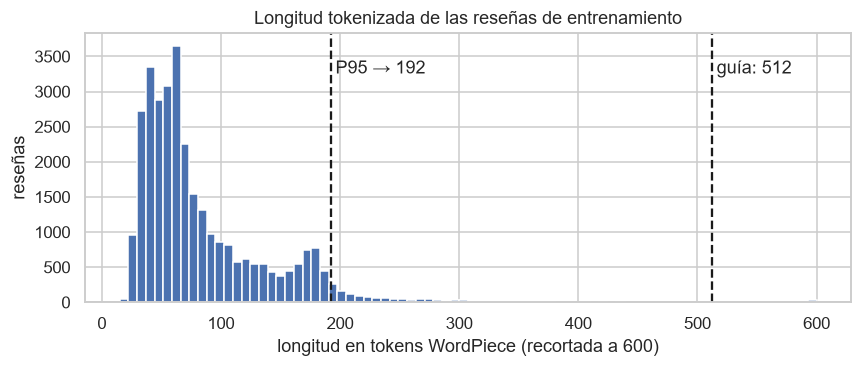

In [33]:
# =========================================================================
# 4.6 · MAX_LEN_BERT = P95 en tokens WordPiece (train)
# =========================================================================
long_tr = np.array([len(i) for i in tokenizer(txt_tr)["input_ids"]])
long_te = np.array([len(i) for i in tokenizer(txt_te)["input_ids"]])
p95 = int(np.percentile(long_tr, 95))
MAX_LEN_BERT = int(min(CFG_BERT["max_len_tope"], int(np.ceil(p95 / 8) * 8)))

print(f"Mediana: {np.median(long_tr):.0f} tokens | media: {long_tr.mean():.0f} | P95: {p95} "
      f"-> MAX_LEN_BERT = {MAX_LEN_BERT}  (MAX_LEN heredado: {MAX_LEN} palabras)")
print(f"Reseñas truncadas en test: {(long_te > MAX_LEN_BERT).mean()*100:.1f}%")
# Costo de atención ~ L^2. Con padding fijo a 512 cada reseña paga 512^2; con padding dinámico
# paga (aprox.) la longitud del lote. Estimación con la longitud media recortada:
l_media = np.minimum(long_tr, MAX_LEN_BERT).mean()
print(f"Costo de atención relativo a 512 fijo: MAX_LEN_BERT fijo ~{(MAX_LEN_BERT/512)**2*100:.0f}% "
      f"| padding dinámico ~{(l_media/512)**2*100:.1f}% (cota optimista)")

fig, ax = plt.subplots(figsize=(8, 3.5))
ax.hist(np.minimum(long_tr, 600), bins=80, color="#4C72B0")
for x, lab in [(MAX_LEN_BERT, f"P95 → {MAX_LEN_BERT}"), (512, "guía: 512")]:
    ax.axvline(x, ls="--", color="k"); ax.text(x, ax.get_ylim()[1] * 0.85, " " + lab)
ax.set_xlabel("longitud en tokens WordPiece (recortada a 600)"); ax.set_ylabel("reseñas")
ax.set_title("Longitud tokenizada de las reseñas de entrenamiento")
plt.tight_layout(); plt.show()

La mediana es de **65 tokens** y el P95 de **189**, así que `MAX_LEN_BERT = 192`. Solo se
trunca el **4,2%** del test, y lo truncado es cola de reseñas largas, donde el veredicto ya
apareció.

El ahorro es la parte interesante. Como el costo de la atención crece con el cuadrado de la
longitud, fijar 512 como hace el guía costaría más de siete veces lo que cuesta 192: nuestro
tope está en **~14%** del costo de 512, y con padding dinámico --rellenando cada lote solo hasta
su reseña más larga-- baja a **~2,6%**. Seguir el guía sin pensar habría multiplicado por casi
cuarenta el costo de atención sin ganar un punto de F1, porque lo que se añade es relleno.

### 4.7 Conjuntos para Hugging Face y pesos de clase

Etiquetas internas 0 a 4 (así las espera el modelo); `evaluar` recibe siempre estrellas 1 a 5.
Los pesos de clase son los mismos que usaron las entregas anteriores: inverso de la frecuencia
en train. El guía entrena sin pesos; sobre este corpus eso empuja todo hacia 5★.

In [34]:
# =========================================================================
# 4.7 · DatasetDict tokenizado + pesos de clase
# =========================================================================
from datasets import Dataset, DatasetDict
from transformers import DataCollatorWithPadding

def a_dataset(textos, etiquetas_0):
    return Dataset.from_dict({"text": list(textos), "label": [int(e) for e in etiquetas_0]})

ds_bert = DatasetDict(train=a_dataset(txt_tr, y_tr_A - 1),
                      val=a_dataset(txt_va, y_va_A - 1),
                      test=a_dataset(txt_te, y_te_A - 1))

def tokenizar_ds(tok, max_len=None):
    return lambda b: tok(b["text"], truncation=True, max_length=max_len or MAX_LEN_BERT)

ds_tok = ds_bert.map(tokenizar_ds(tokenizer), batched=True, remove_columns=["text"])
collator = DataCollatorWithPadding(tokenizer)

def pesos_de(etiquetas_0, n_clases):
    c = np.bincount(etiquetas_0, minlength=n_clases)
    return torch.tensor(len(etiquetas_0) / (n_clases * c), dtype=torch.float)

PESOS = pesos_de(np.array(ds_bert["train"]["label"]), 5)
print(ds_tok)
print("Pesos de clase (1★..5★):", PESOS.numpy().round(2))

# Carpeta de resultados (figuras y métricas ligeras), válida en local y en Colab
from pathlib import Path
DIR_RES = Path("../results") if Path("../results").exists() else Path("results")
(DIR_RES / "figures").mkdir(parents=True, exist_ok=True); (DIR_RES / "metrics").mkdir(parents=True, exist_ok=True)

Map:   0%|          | 0/32000 [00:00<?, ? examples/s]

Map:   3%|▎         | 1000/32000 [00:00<00:04, 7339.81 examples/s]

Map:   6%|▋         | 2000/32000 [00:00<00:04, 6954.38 examples/s]

Map:   9%|▉         | 3000/32000 [00:00<00:04, 6617.04 examples/s]

Map:  12%|█▎        | 4000/32000 [00:00<00:04, 6596.57 examples/s]

...

Map:  50%|█████     | 2000/4000 [00:00<00:00, 6937.31 examples/s]

Map:  75%|███████▌  | 3000/4000 [00:00<00:00, 6741.63 examples/s]

Map: 100%|██████████| 4000/4000 [00:00<00:00, 6662.73 examples/s]

Map: 100%|██████████| 4000/4000 [00:00<00:00, 6630.49 examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 32000
    })
    val: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 4000
    })
})
Pesos de clase (1★..5★): [7.65 7.57 2.68 0.92 0.3 ]


---

## 5. Técnica A: BETO congelado + cabeza lineal

Como en el guía, BETO se usa como **extractor de características** y solo se entrena una capa
lineal encima. Pero el guía vuelve a pasar cada reseña por los 110 M de parámetros congelados
en cada época. Si BETO no cambia, su salida tampoco: **la calculamos una sola vez** y
entrenamos la cabeza sobre el tensor guardado. Es el mismo modelo en una fracción del tiempo.

Comparamos dos formas de resumir la secuencia en un vector:

- el token **`[CLS]`**, que es lo que usa `BertForSequenceClassification`;
- el **promedio enmascarado** de todos los tokens, la decisión que tomamos en MP2 §D-205.

BETO se preentrenó solo con *masked language modeling* (sin la tarea de predicción de la
siguiente oración de BERT original), así que nada obliga a su `[CLS]` a resumir la frase.
Si H2 es cierta, ambos rendirán por debajo de TF-IDF.

In [35]:
# =========================================================================
# 5 · Extracción de embeddings congelados (una sola vez)
# =========================================================================
import torch.nn as nn
from transformers import AutoModel

@torch.no_grad()
def extraer_embeddings(encoder, dataset_tok, tok=None, batch=None):
    """Devuelve (cls, mean) de todo el conjunto. Encoder en eval, sin gradiente."""
    encoder.eval().to(DISPOSITIVO)
    cols = [c for c in dataset_tok.column_names if c in ("input_ids", "attention_mask", "token_type_ids")]
    dl = torch.utils.data.DataLoader(dataset_tok.select_columns(cols),
                                     batch_size=batch or CFG_BERT["batch_eval"],
                                     collate_fn=DataCollatorWithPadding(tok or tokenizer))
    cls, mean = [], []
    for b in dl:
        b = {k: v.to(DISPOSITIVO) for k, v in b.items()}
        with torch.autocast(DISPOSITIVO.type, enabled=HAY_GPU):
            h = encoder(**b).last_hidden_state.float()
        m = b["attention_mask"].unsqueeze(-1).float()
        cls.append(h[:, 0].cpu()); mean.append(((h * m).sum(1) / m.sum(1)).cpu())
    return torch.cat(cls), torch.cat(mean)

fijar_semilla_hf()
t0 = time.time()
beto = AutoModel.from_pretrained(CHECKPOINT)
EMB = {sp: extraer_embeddings(beto, ds_tok[sp]) for sp in ["train", "val", "test"]}
SEG_EXTRACCION = time.time() - t0
N_PARAMS_BETO = sum(p.numel() for p in beto.parameters())
print(f"Embeddings de {sum(len(v[0]) for v in EMB.values()):,} reseñas extraídos en {SEG_EXTRACCION:.0f} s")
print(f"BETO: {N_PARAMS_BETO/1e6:.1f} M parámetros, todos congelados")
del beto; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 30266.59it/s]


[transformers] BertModel LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
pooler.dense.weight                        | MISSING    | 
pooler.dense.bias                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Embeddings de 40,000 reseñas extraídos en 867 s
BETO: 109.9 M parámetros, todos congelados


Todas las cabezas se entrenan con el mismo bucle: pérdida ponderada, AdamW y early stopping por
macro-F1 de validación, igual que los modelos de las entregas anteriores. Como la entrada ya
está calculada, cada época tarda fracciones de segundo.

In [36]:
# =========================================================================
# 5 · Bucle de entrenamiento de cabezas sobre embeddings guardados
# =========================================================================
def n_entrenables(m):
    return sum(p.numel() for p in m.parameters() if p.requires_grad)

@torch.no_grad()
def predecir_cabeza(cabeza, X):
    cabeza.eval()
    return cabeza(X.to(DISPOSITIVO)).argmax(-1).cpu().numpy() + 1

def entrenar_cabeza(cabeza, Xtr, ytr, Xva, yva, epocas=60, lr=None, batch=256, paciencia=6):
    fijar_semilla_hf()
    cabeza = cabeza.to(DISPOSITIVO)
    opt = torch.optim.AdamW(cabeza.parameters(), lr=lr or CFG_BERT["lr_cabeza"], weight_decay=1e-2)
    crit = nn.CrossEntropyLoss(weight=PESOS.to(DISPOSITIVO))
    ytr_t = torch.tensor(ytr - 1)
    mejor, estado, sin_mejora, hist = -1.0, None, 0, []
    t0 = time.time()
    for ep in range(epocas):
        cabeza.train()
        for i in torch.randperm(len(Xtr)).split(batch):
            opt.zero_grad()
            crit(cabeza(Xtr[i].to(DISPOSITIVO)), ytr_t[i].to(DISPOSITIVO)).backward()
            opt.step()
        f1 = evaluar_silencioso(yva, predecir_cabeza(cabeza, Xva))["macro_f1"]
        hist.append(f1)
        if f1 > mejor:
            mejor, estado, sin_mejora = f1, {k: v.clone() for k, v in cabeza.state_dict().items()}, 0
        else:
            sin_mejora += 1
            if sin_mejora >= paciencia:
                break
    cabeza.load_state_dict(estado)
    return cabeza, time.time() - t0, mejor, hist

Con el bucle listo, la técnica A propiamente dicha: la misma cabeza lineal (768 → 5) sobre
cada uno de los dos resúmenes. El resumen que se usa en adelante se elige por macro-F1 de
**validación**, nunca mirando el test.

In [37]:
# =========================================================================
# 5 · Técnica A: cabeza lineal sobre [CLS] y sobre el promedio
# =========================================================================
RESUMENES = ["[CLS]", "promedio"]
F1_VAL_A = {}
for i, resumen in enumerate(RESUMENES):
    lineal, seg, f1_val, _ = entrenar_cabeza(nn.Linear(768, 5), EMB["train"][i], y_tr_A,
                                             EMB["val"][i], y_va_A)
    F1_VAL_A[i] = f1_val
    nombre = f"A · BETO congelado + lineal ({resumen})"
    pred = predecir_cabeza(lineal, EMB["test"][i])
    # evaluar() heredada devuelve la fila registrada: le añadimos el costo propio de esta entrega
    evaluar(y_te_A, pred, nombre, n_params=N_PARAMS_BETO,
            segundos=seg + SEG_EXTRACCION)["n_entrenables"] = n_entrenables(lineal)
    PREDS[nombre] = (y_te_A, pred)

# Resumen elegido por VALIDACIÓN (no por test) para las técnicas B y la LogReg
I_MEJOR = max(F1_VAL_A, key=F1_VAL_A.get)
print(f"\nResumen elegido por macro-F1 de validación: {RESUMENES[I_MEJOR]} "
      f"({F1_VAL_A[I_MEJOR]:.4f} vs {F1_VAL_A[1 - I_MEJOR]:.4f})")

A · BETO congelado + lineal ([CLS])    | macro-F1 0.4578 | acc 0.6178 | MAE 0.481 | QWK 0.6460


A · BETO congelado + lineal (promedio) | macro-F1 0.4719 | acc 0.6468 | MAE 0.427 | QWK 0.6983

Resumen elegido por macro-F1 de validación: promedio (0.5046 vs 0.4624)


Como referencia barata, la misma idea con una **regresión logística** de scikit-learn sobre los
embeddings estandarizados. Es el clasificador lineal que ya usamos con TF-IDF en MP1: si con la
misma cabeza BETO congelado queda por debajo de TF-IDF, la diferencia está en la
representación, no en el clasificador.

In [38]:
# --- Referencia: regresión logística (la de MP1) sobre los embeddings de BETO congelado ---
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

t0 = time.time()
logreg_emb = make_pipeline(StandardScaler(),
                           LogisticRegression(class_weight="balanced", max_iter=2000, C=1.0))
logreg_emb.fit(EMB["train"][I_MEJOR].numpy(), y_tr_A)
seg = time.time() - t0
pred = logreg_emb.predict(EMB["test"][I_MEJOR].numpy())
nombre = f"A' · BETO congelado + LogReg ({RESUMENES[I_MEJOR]})"
evaluar(y_te_A, pred, nombre, n_params=N_PARAMS_BETO,
        segundos=seg + SEG_EXTRACCION)["n_entrenables"] = 768 * 5 + 5
PREDS[nombre] = (y_te_A, pred)

A' · BETO congelado + LogReg (promedio) | macro-F1 0.4398 | acc 0.6135 | MAE 0.484 | QWK 0.6432


El promedio enmascarado supera al `[CLS]` tanto en validación (0,5046 frente a 0,4624, que es
el criterio con el que se elige) como en test (0,4719 frente a 0,4578). Es lo esperable en BETO
congelado: como se dijo arriba, BETO se preentrenó solo con *masked language modeling*, sin la
tarea de siguiente oración, así que nada entrenó a su `[CLS]` para resumir la frase; sin ajuste
es un token más. El promedio, en cambio, junta la información de todas las palabras de la reseña,
incluidas las que cargan el sentimiento. Por eso la técnica B y la regresión logística usan el
promedio.

La regresión logística sobre el mismo promedio queda **por debajo** de la cabeza lineal entrenada
con PyTorch (0,4398 frente a 0,4719), aunque ambas son clasificadores lineales con el mismo esquema de pesos de clase. La
explicación más probable es la selección: la cabeza de PyTorch se queda con la época de mejor
macro-F1 de validación, y la regresión logística no tiene ese control. Con cualquiera de las dos cabezas lineales, **BETO congelado queda claramente por
debajo del TF-IDF de MP1 (0,5235)**: con la misma clase de clasificador encima, la representación
de palabras contadas le gana a la de BETO sin ajustar.

---

## 6. Técnica B: BETO congelado + cabeza MLP propia

La cabeza del guía (768 → 512 → 256 → 5, con ReLU y dropout), con **una corrección**: el guía la
termina en `LogSoftmax`, pero `BertForSequenceClassification` aplica `CrossEntropyLoss`, que ya
incluye el `log_softmax`. Normalizar dos veces no rompe el entrenamiento pero aplana los
gradientes. Aquí la cabeza devuelve logits (`docs/DECISIONS.md` §D-304).

La pregunta es qué falta en la técnica A. Si el sentimiento está en el embedding pero no de
forma lineal, una cabeza no lineal debería extraerlo. Si apenas mejora, el sentimiento
**no está** en la representación congelada, y hay que cambiar la representación: §7.

In [39]:
# =========================================================================
# 6 · Técnica B: cabeza MLP (la del guía, sin LogSoftmax)
# =========================================================================
def cabeza_mlp(entrada=768, n_clases=5):
    return nn.Sequential(nn.Linear(entrada, 512), nn.ReLU(), nn.Dropout(0.2),
                         nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.2),
                         nn.Linear(256, n_clases))

mlp, seg, _, hist_mlp = entrenar_cabeza(cabeza_mlp(), EMB["train"][I_MEJOR], y_tr_A,
                                        EMB["val"][I_MEJOR], y_va_A)
pred = predecir_cabeza(mlp, EMB["test"][I_MEJOR])
nombre = f"B · BETO congelado + MLP ({RESUMENES[I_MEJOR]})"
evaluar(y_te_A, pred, nombre, n_params=N_PARAMS_BETO,
        segundos=seg + SEG_EXTRACCION)["n_entrenables"] = n_entrenables(mlp)
PREDS[nombre] = (y_te_A, pred)
print(f"Épocas hasta early stopping: {len(hist_mlp)} | parámetros entrenables: {n_entrenables(mlp):,}")

B · BETO congelado + MLP (promedio)    | macro-F1 0.5191 | acc 0.6823 | MAE 0.358 | QWK 0.7551
Épocas hasta early stopping: 16 | parámetros entrenables: 526,341


La cabeza MLP sube de **0,4719 a 0,5191** de macro-F1 sobre la misma representación
congelada: **+0,047** sin tocar un solo peso de BETO. La ganancia viene de la cabeza y no de la
representación, porque los vectores de entrada son idénticos byte a byte -- es la misma matriz
cacheada de §5.

Eso responde la pregunta de arriba: el sentimiento **sí está** en la representación congelada, pero
no de forma lineal, y una cabeza con capas ocultas saca parte de él. Pero conviene leer el techo,
no solo la mejora. El MLP necesitó 16 épocas hasta el *early stopping* y 526.341 parámetros entrenables, y
aun así se queda en 0,5191, **por debajo del TF-IDF de MP1 (0,5235)**. Toda la capacidad extra
de la cabeza no alcanza para compensar que la representación de abajo no sabe nada de este
dominio. Si la información no está en el vector, ninguna cabeza la inventa.

---

## 7. Técnica C: *fine-tuning* completo

Ahora se ajustan los 110 M de parámetros. Usamos la API `Trainer` de Hugging Face como el
guía, con cuatro diferencias:

- **Pérdida ponderada por clase** (`WeightedTrainer`), igual que en todos los modelos anteriores.
- **Selección del mejor modelo por macro-F1 de validación** y *early stopping*; el guía se queda
  con el de la última época.
- **Padding dinámico** y `MAX_LEN_BERT` del P95 en lugar de 512 fijo.
- `lr = 2e-5` con *warmup*. Aquí sí es la tasa correcta. En MP2 esa misma tasa era la trampa
  (§D-204), porque allí se partía de pesos aleatorios.

Los *checkpoints* se escriben en un directorio temporal que se borra al terminar cada corrida:
Colab se queda sin disco con varios BERT-base guardados.

In [40]:
# =========================================================================
# 7 · WeightedTrainer + utilidades de fine-tuning (reutilizadas en §9 a §13)
# =========================================================================
import tempfile, shutil
from transformers import (AutoModelForSequenceClassification, Trainer, TrainingArguments,
                          EarlyStoppingCallback)

class WeightedTrainer(Trainer):
    """Trainer con CrossEntropy ponderada por clase (el guía usa CE sin pesos)."""
    def __init__(self, *args, pesos=None, **kwargs):
        super().__init__(*args, **kwargs)
        self.pesos = pesos

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.pop("labels")
        out = model(**inputs)
        w = self.pesos.to(out.logits.device) if self.pesos is not None else None
        loss = nn.functional.cross_entropy(out.logits.float(), labels, weight=w)
        return (loss, out) if return_outputs else loss

def metricas_polaridad(pred):
    y_pred = pred.predictions.argmax(-1) + 1
    y_true = pred.label_ids + 1
    f = evaluar_silencioso(y_true, y_pred)
    return {"macro_f1": f["macro_f1"], "mae": f["mae"], "qwk": f["qwk"]}

def afinar(modelo, train, val, epocas, lr=None, tok=None, batch=None, pesos="polaridad",
           optimizers=(None, None), compute_metrics=metricas_polaridad):
    """Fine-tuning reproducible. Devuelve (trainer, segundos). El mejor modelo (por macro-F1
    de validación) queda cargado en memoria y los checkpoints en disco se borran."""
    fijar_semilla_hf()
    salida = tempfile.mkdtemp(prefix="mp3_")
    args = TrainingArguments(
        output_dir=salida, num_train_epochs=epocas, learning_rate=lr or CFG_BERT["lr"],
        per_device_train_batch_size=batch or CFG_BERT["batch"],
        per_device_eval_batch_size=CFG_BERT["batch_eval"],
        # warmup en pasos (warmup_ratio desapareció en transformers 5; así vale en 4 y 5)
        warmup_steps=int(np.ceil(len(train) / (batch or CFG_BERT["batch"])) * epocas * CFG_BERT["warmup_frac"]),
        weight_decay=CFG_BERT["weight_decay"],
        fp16=CFG_BERT["fp16"], eval_strategy="epoch", save_strategy="epoch",
        save_total_limit=1, save_only_model=True, load_best_model_at_end=True,
        metric_for_best_model="macro_f1", greater_is_better=True, label_names=["labels"],
        logging_strategy="epoch", report_to="none", seed=SEED, data_seed=SEED,
        disable_tqdm=True)
    tr = WeightedTrainer(model=modelo, args=args, train_dataset=train, eval_dataset=val,
                         data_collator=DataCollatorWithPadding(tok or tokenizer),
                         compute_metrics=compute_metrics, optimizers=optimizers,
                         pesos=PESOS if pesos == "polaridad" else pesos,
                         callbacks=[EarlyStoppingCallback(CFG_BERT["paciencia"])])
    t0 = time.time(); tr.train(); seg = time.time() - t0
    shutil.rmtree(salida, ignore_errors=True)
    return tr, seg

def predecir_trainer(tr, dataset):
    return tr.predict(dataset).predictions.argmax(-1) + 1

@torch.no_grad()
def latencia_ms(modelo, textos, tok=None, batch=1, n=256):
    """Milisegundos por reseña en inferencia, en el hardware actual."""
    tok = tok or tokenizer; modelo.eval()
    textos = list(textos[:n]); disp = next(modelo.parameters()).device
    def correr(ts):
        b = tok(ts, truncation=True, max_length=MAX_LEN_BERT, padding=True, return_tensors="pt").to(disp)
        with torch.autocast(disp.type, enabled=HAY_GPU):
            modelo(**b)
    correr(textos[:batch])                     # calentamiento
    if HAY_GPU: torch.cuda.synchronize()
    t0 = time.perf_counter()
    for i in range(0, len(textos), batch):
        correr(textos[i:i + batch])
    if HAY_GPU: torch.cuda.synchronize()
    return (time.perf_counter() - t0) / len(textos) * 1000

Con esas utilidades, la técnica C: se carga BETO con una cabeza de clasificación nueva y se
ajustan todos sus pesos sobre las 32.000 reseñas de entrenamiento. Además de las métricas se mide
la latencia de inferencia, porque es el costo que pagaría un despliegue real (§D-307).

In [41]:
# =========================================================================
# 7 · Técnica C: fine-tuning completo de BETO
# =========================================================================
fijar_semilla_hf()
modelo_ft = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=5)
ds_ft = ds_tok["train"]
if CFG_BERT["n_train_max"]:        # solo en CPU (§4.4)
    ds_ft = ds_ft.shuffle(seed=SEED).select(range(min(CFG_BERT["n_train_max"], len(ds_ft))))
trainer_ft, seg_ft = afinar(modelo_ft, ds_ft, ds_tok["val"], CFG_BERT["epocas"])

pred_ft = predecir_trainer(trainer_ft, ds_tok["test"])
nombre_ft = "C · BETO fine-tuning completo"
fila = evaluar(y_te_A, pred_ft, nombre_ft, n_params=N_PARAMS_BETO, segundos=seg_ft)
fila["n_entrenables"] = n_entrenables(trainer_ft.model)
fila["ms_lote1"] = latencia_ms(trainer_ft.model, txt_te, batch=1)
fila["ms_lote64"] = latencia_ms(trainer_ft.model, txt_te, batch=64)
PREDS[nombre_ft] = (y_te_A, pred_ft)
print(f"Entrenamiento: {seg_ft/60:.1f} min | latencia: {fila['ms_lote1']:.1f} ms/reseña (lote 1), "
      f"{fila['ms_lote64']:.2f} ms/reseña (lote 64)")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 24381.89it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:

{'loss': '1.062', 'grad_norm': '7.617', 'learning_rate': '1.482e-05', 'epoch': '1'}


{'eval_loss': '0.8731', 'eval_macro_f1': '0.5783', 'eval_mae': '0.2948', 'eval_qwk': '0.8121', 'eval_runtime': '7.938', 'eval_samples_per_second': '503.9', 'eval_steps_per_second': '4.031', 'epoch': '1'}


...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.46it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.43it/s]

{'train_runtime': '1752', 'train_samples_per_second': '54.8', 'train_steps_per_second': '1.713', 'train_loss': '0.8161', 'epoch': '3'}


C · BETO fine-tuning completo          | macro-F1 0.5953 | acc 0.6847 | MAE 0.338 | QWK 0.7840


Entrenamiento: 29.2 min | latencia: 8.8 ms/reseña (lote 1), 1.91 ms/reseña (lote 64)


Las curvas muestran si el modelo seguía aprendiendo o si ya sobreajustaba. En *fine-tuning* es
habitual que la pérdida de validación suba desde la segunda época mientras el macro-F1 aún
mejora: el modelo se vuelve más seguro de sus errores antes de dejar de acertar.

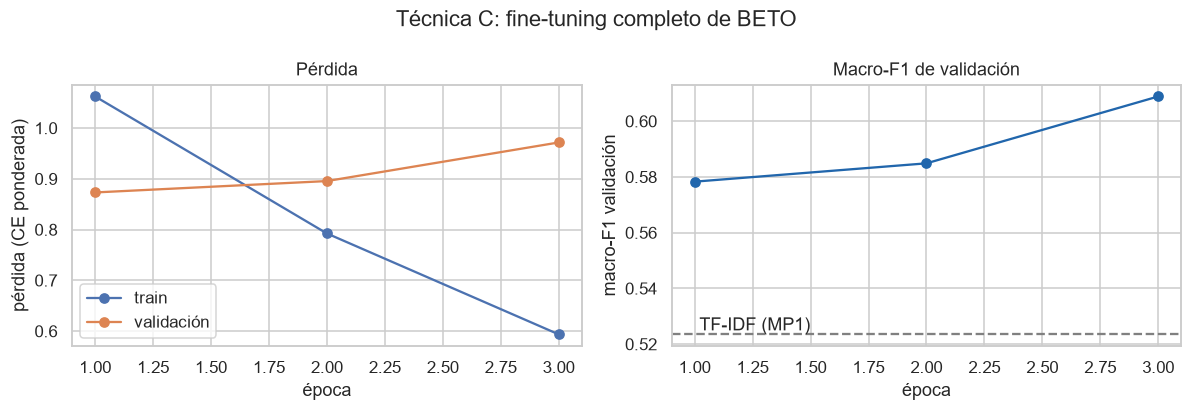

In [42]:
# --- Curvas de entrenamiento: pérdida train/val y macro-F1 de validación por época ---
hist = pd.DataFrame(trainer_ft.state.log_history)
h_tr = hist.dropna(subset=["loss"])[["epoch", "loss"]]
h_va = hist.dropna(subset=["eval_loss"])[["epoch", "eval_loss", "eval_macro_f1"]]

fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))
axes[0].plot(h_tr["epoch"], h_tr["loss"], "o-", label="train")
axes[0].plot(h_va["epoch"], h_va["eval_loss"], "o-", label="validación")
axes[0].set_xlabel("época"); axes[0].set_ylabel("pérdida (CE ponderada)"); axes[0].legend()
axes[0].set_title("Pérdida")
axes[1].plot(h_va["epoch"], h_va["eval_macro_f1"], "o-", color="#2166ac")
axes[1].axhline(0.5235, ls="--", color="gray"); axes[1].text(h_va["epoch"].min(), 0.5235, " TF-IDF (MP1)", va="bottom")
axes[1].set_xlabel("época"); axes[1].set_ylabel("macro-F1 validación"); axes[1].set_title("Macro-F1 de validación")
plt.suptitle("Técnica C: fine-tuning completo de BETO"); plt.tight_layout()
plt.savefig(DIR_RES / "figures" / "curvas_finetuning.png", bbox_inches="tight"); plt.show()

El *fine-tuning* completo es la primera técnica de las tres entregas que supera con claridad a
TF-IDF: **0,5953 de macro-F1 en test frente a 0,5235**, +0,072, con MAE 0,338 y QWK 0,784.

Las curvas muestran el patrón anunciado arriba. La pérdida de entrenamiento baja en cada época
(1,06 → 0,79 → 0,59), la de validación **sube** desde la segunda (0,87 → 0,90 → 0,97) y, aun así,
el macro-F1 de validación sigue mejorando hasta la última época (0,578 → 0,585 → 0,609). El modelo
se vuelve más confiado, también en sus errores, pero todavía ordena mejor las clases. Como el
mejor punto es la tercera época, no está claro que el techo se haya alcanzado; con el presupuesto
de tiempo fijado (§D-306) no se probaron más épocas.

El precio es claro: **29 minutos de entrenamiento** en esta GPU, frente a segundos para entrenar
las cabezas de A y B (a las que hay que sumar, una sola vez, la extracción de embeddings de §5), y
una latencia de 8,8 ms por reseña de una en una (1,9 ms en lotes de 64).

---

## 8. Comparación: tres técnicas, tres entregas

La tabla que responde H1 y H2. Las filas de MP1 y MP2 se toman de sus bitácoras
(`docs/EXPERIMENTS.md` de cada entrega): misma submuestra, mismo Split A y misma `evaluar`.
**Sus tiempos se midieron en otro hardware** (MP1: RTX 3050 local) y solo son orientativos.

In [43]:
# =========================================================================
# 8 · Tabla única: tres técnicas + entregas anteriores
# =========================================================================
# De ../miniproyecto 1/docs/EXPERIMENTS.md (§2)
PREVIOS = [
    dict(modelo="MP1 · TF-IDF + LogReg", macro_f1=0.5235, accuracy=0.6785, mae=0.376, qwk=0.7261,
         f1_1=0.596, f1_2=0.301, f1_3=0.433, f1_4=0.475, f1_5=0.813,
         n_entrenables=60_000, segundos=27.0),
    dict(modelo="MP1 · LSTM desde cero", macro_f1=0.2951, accuracy=0.5755, mae=0.651, qwk=0.3552,
         f1_1=0.314, f1_2=0.173, f1_3=0.178, f1_4=0.053, f1_5=0.758,
         n_entrenables=3_972_741, segundos=50.1),
    dict(modelo="MP1 · BiLSTM + spaCy (afinados)", macro_f1=0.4863, accuracy=0.6358, mae=0.431, qwk=0.6942,
         f1_1=0.524, f1_2=0.311, f1_3=0.381, f1_4=0.433, f1_5=0.784,
         n_entrenables=9_441_605, segundos=38.9),
    dict(modelo="MP1 · BiLSTM + atención", macro_f1=0.5274, accuracy=0.6758, mae=0.362, qwk=0.7546,
         n_entrenables=9_441_862, segundos=88.4),
]
# De ../miniproyecto 2/docs/EXPERIMENTS.md (§2), corrida de referencia del 2026-09-23.
PREVIOS_MP2 = [
    dict(modelo="MP2 · Transformer desde cero", macro_f1=0.4160, accuracy=0.5858, mae=0.605, qwk=0.5068,
         f1_1=0.349, f1_2=0.248, f1_3=0.344, f1_4=0.389, f1_5=0.750,
         n_entrenables=4_105_605, segundos=196.6),
    dict(modelo="MP2 · MLP (embeddings promediados)", macro_f1=0.3545, accuracy=0.5268, mae=0.886, qwk=0.3501,
         f1_1=0.252, f1_2=0.121, f1_3=0.314, f1_4=0.376, f1_5=0.710,
         n_entrenables=3_857_157, segundos=21.1),
]

propios = [r for r in RESULTADOS if not r["modelo"].startswith("Baseline")]
base = [r for r in RESULTADOS if r["modelo"].startswith("Baseline")]
tabla = pd.DataFrame(base + PREVIOS + PREVIOS_MP2 + propios)
tabla["entrega"] = tabla["modelo"].map(lambda m: "MP1" if m.startswith("MP1") else
                                       "MP2" if m.startswith("MP2") else
                                       "—" if m.startswith("Baseline") else "MP3")
cols = (["modelo", "entrega", "macro_f1", "accuracy", "mae", "qwk"]
        + [f"f1_{e}" for e in ESTRELLAS] + ["n_entrenables", "segundos"])
tabla = tabla[cols].sort_values("macro_f1", ascending=False).reset_index(drop=True)
tabla.to_csv(DIR_RES / "metrics" / "tabla_principal.csv", index=False)
tabla.round(4)

,modelo,entrega,macro_f1,accuracy,mae,qwk,f1_1,f1_2,f1_3,f1_4,f1_5,n_entrenables,segundos
0,C · BETO fine-tuning completo,MP3,0.5953,0.6848,0.3378,0.7840,0.6762,0.4672,0.5311,0.4984,0.8036,109854725.0,1752.2754
1,MP1 · BiLSTM + atención,MP1,0.5274,0.6758,0.3620,0.7546,NaN,NaN,NaN,NaN,NaN,9441862.0,88.4000
2,MP1 · TF-IDF + LogReg,MP1,0.5235,0.6785,0.3760,0.7261,0.5960,0.3010,0.4330,0.4750,0.8130,60000.0,27.0000
3,B · BETO congelado + MLP (promedio),MP3,0.5191,0.6822,0.3580,0.7551,0.5586,0.3503,0.3808,0.4848,0.8210,526341.0,871.8064
4,MP1 · BiLSTM + spaCy (afinados),MP1,0.4863,0.6358,0.4310,0.6942,0.5240,0.3110,0.3810,0.4330,0.7840,9441605.0,38.9000
5,A · BETO congelado + lineal (promedio),MP3,0.4719,0.6468,0.4275,0.6983,0.4830,0.2378,0.3989,0.4442,0.7956,3845.0,870.7739
6,A · BETO congelado + lineal ([CLS]),MP3,0.4578,0.6178,0.4808,0.6460,0.4643,0.3032,0.3453,0.3979,0.7781,3845.0,873.1311
7,A' · BETO congelado + LogReg (promedio),MP3,0.4398,0.6135,0.4842,0.6432,0.4073,0.2466,0.3472,0.4251,0.7727,3845.0,897.2504
8,MP2 · Transformer desde cero,MP2,0.4160,0.5858,0.6050,0.5068,0.3490,0.2480,0.3440,0.3890,0.7500,4105605.0,196.6000
9,MP2 · MLP (embeddings promediados),MP2,0.3545,0.5268,0.8860,0.3501,0.2520,0.1210,0.3140,0.3760,0.7100,3857157.0,21.1000


El F1 por clase es donde se contrasta H1: si BETO gana, ¿gana en las fronteras finas (2★, 3★) o
solo en las clases fáciles?

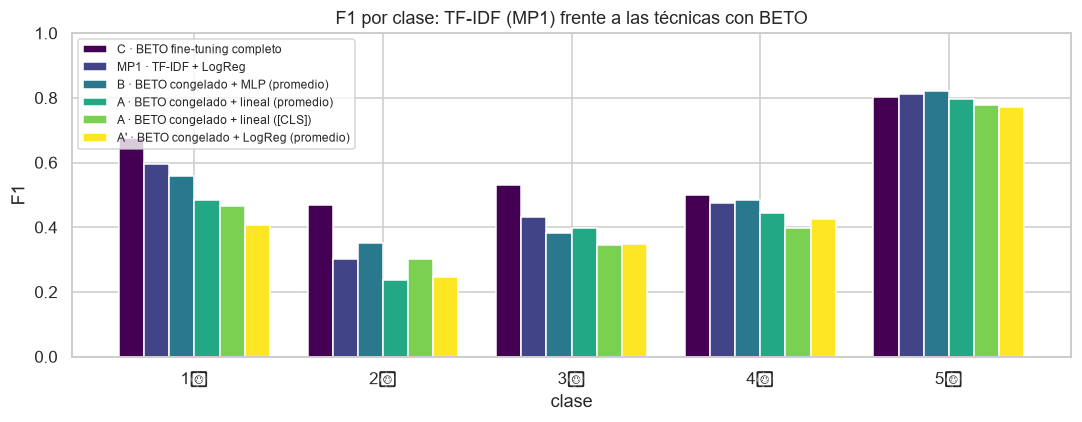

Ganancia de C sobre TF-IDF por clase: {'1★': 0.08, '2★': 0.166, '3★': 0.098, '4★': 0.023, '5★': -0.009}


In [44]:
# --- F1 por clase: mejor modelo de MP1 frente a las tres técnicas ---
sel = tabla[tabla["modelo"].isin(["MP1 · TF-IDF + LogReg"] + [r["modelo"] for r in propios])].dropna(subset=["f1_1"])
f1c = sel.set_index("modelo")[[f"f1_{e}" for e in ESTRELLAS]]
f1c.columns = [f"{e}★" for e in ESTRELLAS]

fig, ax = plt.subplots(figsize=(10, 4))
f1c.T.plot(kind="bar", ax=ax, width=0.8, colormap="viridis")
ax.set_ylabel("F1"); ax.set_xlabel("clase"); ax.set_ylim(0, 1); ax.legend(fontsize=8, loc="upper left")
ax.set_title("F1 por clase: TF-IDF (MP1) frente a las técnicas con BETO"); plt.xticks(rotation=0)
plt.tight_layout(); plt.savefig(DIR_RES / "figures" / "f1_por_clase.png", bbox_inches="tight"); plt.show()

delta = (f1c.loc[nombre_ft] - f1c.loc["MP1 · TF-IDF + LogReg"]).round(3)
print("Ganancia de C sobre TF-IDF por clase:", delta.to_dict())

**H1, por clase.** El *fine-tuning* completo mejora sobre TF-IDF en cuatro de las cinco clases:
**2★ +0,166**, **3★ +0,098**, **1★ +0,080**, 4★ +0,023, y pierde un poco en 5★ (−0,009). La
ganancia se concentra en las clases minoritarias e intermedias, las que los modelos anteriores
confundían más, y es casi nula en la mayoritaria, donde TF-IDF ya tenía 0,813 solo con las
palabras positivas.

La pequeña pérdida en 5★ tiene una causa visible en las matrices de confusión de abajo: el modelo
C manda a 4★ 693 de las 2.626 reseñas de 5★. La pérdida ponderada castiga más los errores en las
clases raras y empuja las predicciones dudosas hacia abajo; en 5★ eso cuesta algo de recall a
cambio de acertar más en 1★-3★. Que la mejora sea mayor justo en las reseñas moderadas o mixtas es
coherente con que BETO lea cada palabra en su contexto, cosa que una bolsa de palabras no hace,
aunque esta tabla por sí sola no prueba el mecanismo.

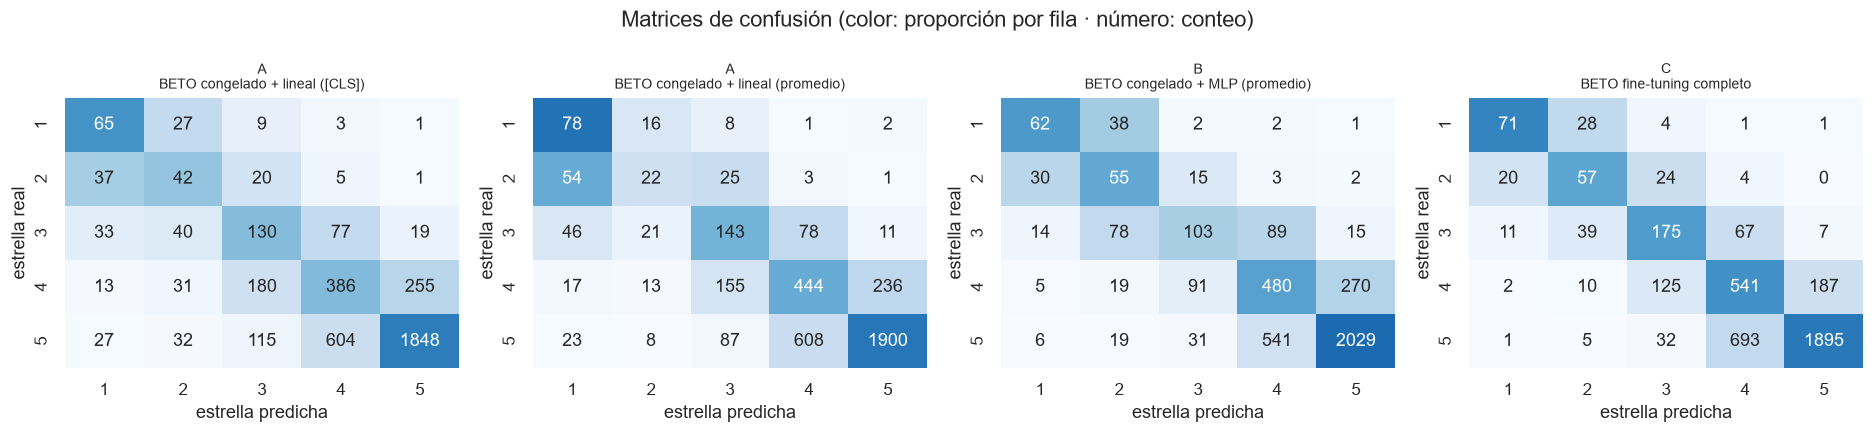

In [45]:
# --- Matrices de confusión A / B / C lado a lado (proporción por fila) ---
nombres_abc = [n for n in PREDS if n.startswith(("A ·", "B ·", "C ·"))]
fig, axes = plt.subplots(1, len(nombres_abc), figsize=(4.3 * len(nombres_abc), 4))
for ax, n in zip(np.atleast_1d(axes), nombres_abc):
    yt, yp = PREDS[n]
    cm = confusion_matrix(yt, yp, labels=ESTRELLAS)
    sns.heatmap(cm / cm.sum(1, keepdims=True), annot=cm, fmt="d", cmap="Blues", cbar=False,
                xticklabels=ESTRELLAS, yticklabels=ESTRELLAS, ax=ax, vmin=0, vmax=1)
    ax.set_title(n.replace(" · ", "\n", 1), fontsize=9)
    ax.set_xlabel("estrella predicha"); ax.set_ylabel("estrella real")
plt.suptitle("Matrices de confusión (color: proporción por fila · número: conteo)")
plt.tight_layout(); plt.savefig(DIR_RES / "figures" / "confusion_abc.png", bbox_inches="tight"); plt.show()

Las cuatro matrices cuentan la misma historia que la tabla, fila por fila:

- **1★** (105 reseñas): los cuatro modelos aciertan la mayoría (65, 78, 62 y 71), y los errores
  graves casi desaparecen en C: solo 1 reseña de 1★ acaba en 5★ y solo 1 de 5★ acaba en 1★
  (el lineal sobre `[CLS]` mandaba 27 reseñas de 5★ a 1★).
- **2★ y 3★**, las fronteras finas: C es el que más acierta (57 de 105 en 2★, 175 de 299 en 3★,
  frente a 55 y 103 de la cabeza MLP). El lineal sobre el promedio casi no reconoce 2★ (22) y
  las manda a 1★.
- **4★ y 5★**: el error dominante de C es la confusión entre vecinas, 693 reseñas de 5★
  predichas como 4★ y 187 de 4★ como 5★. Es un error de una estrella, el más benigno en una
  escala ordinal, y explica por qué su MAE (0,338) es el mejor de la tabla aunque su F1 en 5★ no
  lo sea.

En resumen, al pasar de A a C la diagonal se refuerza en las clases difíciles y los errores que
quedan se concentran junto a ella.

La otra mitad de la pregunta es el costo. Ponemos todos los modelos de las tres entregas en un
mismo plano, primero con los parámetros entrenables (escala logarítmica) frente a macro-F1.

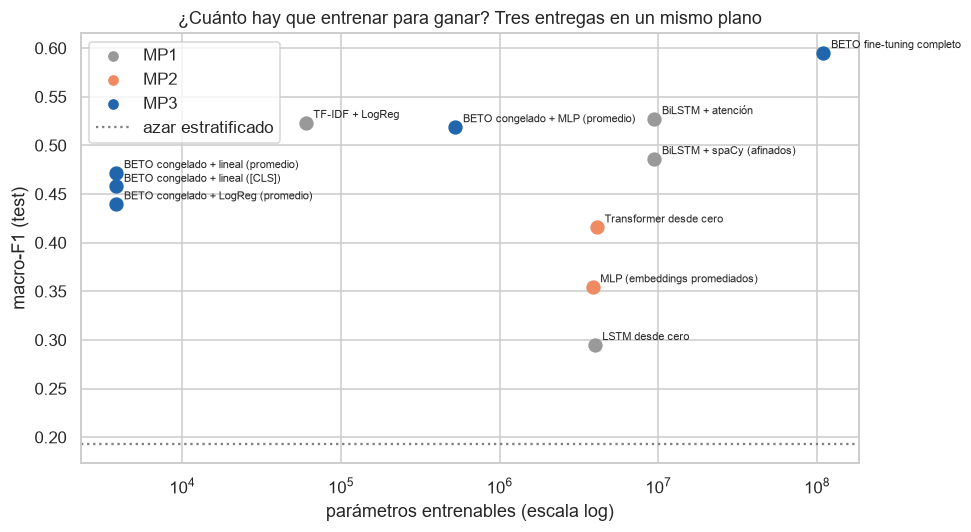

In [46]:
# --- Costo-beneficio: parámetros entrenables vs. macro-F1, todas las entregas ---
cbf = tabla.dropna(subset=["n_entrenables"])
colores = {"MP1": "#999999", "MP2": "#ef8a62", "MP3": "#2166ac"}
fig, ax = plt.subplots(figsize=(9, 5))
for _, r in cbf.iterrows():
    ax.scatter(r["n_entrenables"], r["macro_f1"], s=70, color=colores.get(r["entrega"], "k"))
    ax.annotate(r["modelo"].split(" · ", 1)[-1], (r["n_entrenables"], r["macro_f1"]),
                fontsize=7.5, xytext=(5, 3), textcoords="offset points")
for e, c in colores.items():
    ax.scatter([], [], color=c, label=e)
ax.axhline(tabla.loc[tabla["modelo"].str.startswith("Baseline · azar"), "macro_f1"].iloc[0],
           ls=":", color="gray", label="azar estratificado")
ax.set_xscale("log"); ax.set_xlabel("parámetros entrenables (escala log)"); ax.set_ylabel("macro-F1 (test)")
ax.set_title("¿Cuánto hay que entrenar para ganar? Tres entregas en un mismo plano"); ax.legend()
plt.tight_layout(); plt.savefig(DIR_RES / "figures" / "costo_beneficio.png", bbox_inches="tight"); plt.show()

En parámetros, TF-IDF (60.000 pesos) y la cabeza MLP de B (0,5 M) quedan casi a la misma altura,
y solo el ajuste completo de C (110 M) se despega hacia arriba. Pero los parámetros entrenables
engañan en el caso de A y B: no cuentan que hay que pasar las 40.000 reseñas por los 110 M de
BETO para extraer los embeddings. Por eso la segunda vista usa el tiempo real de entrenamiento,
que sí incluye ese costo.

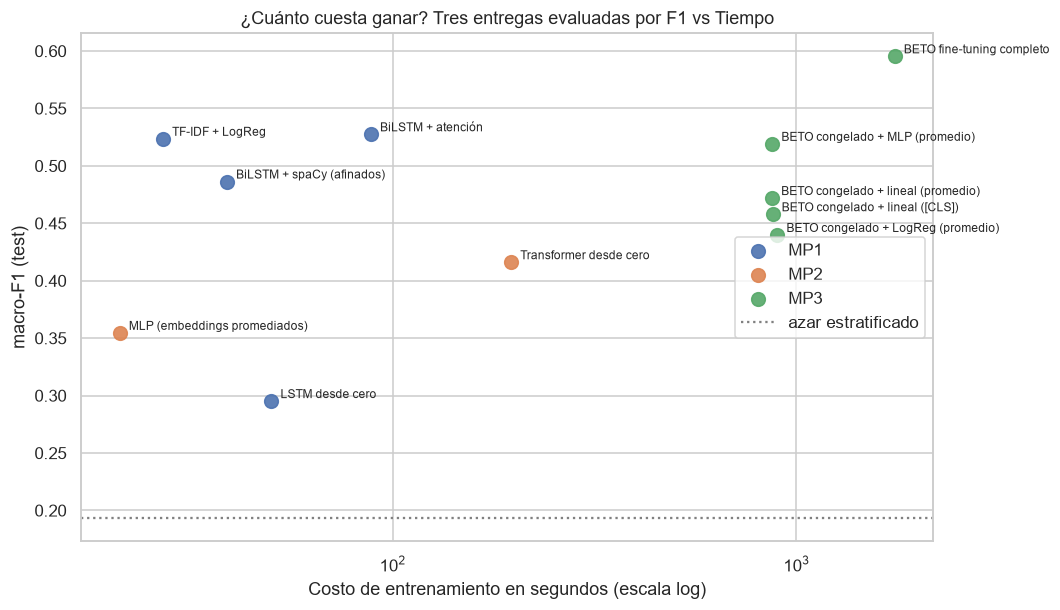

In [47]:
# --- Costo-beneficio en tiempo: macro-F1 vs. segundos de entrenamiento, todas las entregas ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))
# Agrupamos por entrega para colorear
for entrega, df_g in tabla.dropna(subset=["segundos", "macro_f1"]).groupby("entrega"):
    ax.scatter(df_g["segundos"], df_g["macro_f1"], label=entrega, s=80, alpha=0.9)

    # Textos
    for _, fila in df_g.iterrows():
        nombre_limpio = fila["modelo"].split(" · ")[-1]
        ax.annotate(nombre_limpio, (fila["segundos"], fila["macro_f1"]),
                    xytext=(6, 2), textcoords="offset points", fontsize=8)

baseline_azar = tabla.loc[tabla["modelo"].str.contains("azar"), "macro_f1"].values[0]
ax.axhline(baseline_azar, color="gray", linestyle=":", label="azar estratificado")
ax.set_xscale("log")
ax.set_xlabel("Costo de entrenamiento en segundos (escala log)")
ax.set_ylabel("macro-F1 (test)")
ax.set_title("¿Cuánto cuesta ganar? Tres entregas evaluadas por F1 vs Tiempo")
ax.legend()
plt.show()

**Costo-beneficio y H2.** Medido en tiempo, el panorama cambia respecto a los parámetros:

- Las variantes congeladas (A, A' y B) cuestan **entre 870 y 900 s**, pero casi todo es la
  extracción única de embeddings de §5 (867 s en esta corrida); las cabezas en sí entrenan en
  segundos. Aun así, la mejor de ellas, B (0,5191), **no supera a TF-IDF (0,5235)**, que entrena
  en 27 s. **H2 se sostiene**: congelado, BETO no le gana a contar palabras, por buena que sea la
  cabeza.
- El *fine-tuning* completo (1.752 s) es el único punto claramente por encima de todos los demás
  modelos de las tres entregas, pero cuesta unas **65 veces** el tiempo de TF-IDF.

Los tiempos de MP1 y MP2 se midieron en otra máquina, así que la comparación entre entregas vale
como orden de magnitud. La conclusión práctica no depende de ese detalle: si no hay GPU para
ajustar el modelo, TF-IDF sigue siendo la opción racional; el preentrenamiento solo se cobra
ajustando los pesos.

---

> **Secciones 9 a 13: estudios con configuración reducida.** Cada corrida usa `CFG_EST`: un
> subconjunto estratificado de 8.000 reseñas del train (mismo val y test) y menos épocas. Sus
> filas **se comparan entre sí**, no contra la tabla de la Sección 8. La semilla se fija antes
> de cada corrida dentro de `afinar(...)`.

In [48]:
# --- Subconjunto de train para los estudios (estratificado, semilla fija) ---
def submuestra_train(n):
    """Índices (relativos al train de Split A) de una submuestra estratificada de tamaño n."""
    if n >= len(ds_tok["train"]):
        return np.arange(len(ds_tok["train"]))
    sel, _ = train_test_split(np.arange(len(ds_tok["train"])), train_size=n,
                              random_state=SEED, stratify=y_tr_A)
    return np.sort(sel)

SEL_EST = submuestra_train(CFG_EST["n_train"])
ds_est = ds_tok["train"].select(SEL_EST)
ESTUDIOS = []   # una fila por corrida de §9 a §13

def registrar_estudio(nombre, y_pred, **extra):
    f = evaluar(y_te_A, y_pred, nombre, registrar=False)
    ESTUDIOS.append({**f, **extra})
    return f

print(f"Train de estudios: {len(ds_est):,} reseñas | distribución: "
      f"{np.bincount(np.array(ds_est['label']), minlength=5).tolist()}")

Train de estudios: 8,000 reseñas | distribución: [209, 211, 597, 1731, 5252]


## 9. ¿Cuántas capas hay que descongelar?

Entre congelar todo (§5, §6) y afinarlo todo (§7) hay un continuo. Descongelamos solo las
últimas *k* capas del encoder (más el *pooler* y la cabeza). Si con *k* = 2 se recupera casi todo
el *fine-tuning* completo, el sentimiento se aprende arriba y las capas bajas (morfología,
sintaxis) sirven tal cual.

Con *k* = 0 solo se entrena la cabeza, que es la técnica A dentro del `Trainer`; lleva una tasa
mayor, porque parte de pesos aleatorios.

In [49]:
# =========================================================================
# 9 · Descongelar las últimas k capas
# =========================================================================
def congelar_hasta(modelo, k):
    """Deja entrenables solo las últimas k capas del encoder + pooler + clasificador."""
    base = modelo.base_model
    for p in base.parameters():
        p.requires_grad = False
    capas = base.encoder.layer
    for capa in (capas[len(capas) - k:] if k > 0 else []):
        for p in capa.parameters():
            p.requires_grad = True
    if getattr(base, "pooler", None) is not None:
        for p in base.pooler.parameters():
            p.requires_grad = True
    return modelo

for k in [0, 2, 4, 12]:
    fijar_semilla_hf()
    m = congelar_hasta(AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=5), k)
    tr, seg = afinar(m, ds_est, ds_tok["val"], CFG_EST["epocas"],
                     lr=CFG_BERT["lr_cabeza"] if k == 0 else CFG_BERT["lr"])
    registrar_estudio(f"§9 · k={k} capas", predecir_trainer(tr, ds_tok["test"]),
                      estudio="capas", k=k, llrd=False, n_entrenables=n_entrenables(m), segundos=seg)
    del m, tr; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 35740.21it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:

{'loss': '1.327', 'grad_norm': '4.328', 'learning_rate': '0.0005578', 'epoch': '1'}


{'eval_loss': '1.405', 'eval_macro_f1': '0.4276', 'eval_mae': '0.4215', 'eval_qwk': '0.6459', 'eval_runtime': '7.926', 'eval_samples_per_second': '504.6', 'eval_steps_per_second': '4.037', 'epoch': '1'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.27it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.27it/s]

{'train_runtime': '125.8', 'train_samples_per_second': '127.2', 'train_steps_per_second': '3.975', 'train_loss': '1.021', 'epoch': '2'}


§9 · k=12 capas                        | macro-F1 0.5648 | acc 0.6623 | MAE 0.366 | QWK 0.7710


**LR discriminativa por capa** (*layer-wise learning rate decay*; Howard y Ruder, 2018, ULMFiT).
No se vio en clase. Idea: las capas bajas guardan lo más general del idioma y conviene moverlas
poco; las altas son las más específicas de la tarea. Cada capa hacia abajo recibe la tasa de la
de arriba multiplicada por un factor (0,9): la capa 1 queda con ~30 % de la tasa de la capa 12.

In [50]:
# --- LR discriminativa por capa (LLRD) sobre el fine-tuning completo ---
def optimizador_llrd(modelo, lr, decay=0.9, wd=CFG_BERT["weight_decay"]):
    base = modelo.base_model
    n = len(base.encoder.layer)
    grupos = [{"params": list(base.embeddings.parameters()), "lr": lr * decay ** (n + 1)}]
    for i, capa in enumerate(base.encoder.layer):
        grupos.append({"params": list(capa.parameters()), "lr": lr * decay ** (n - i)})
    resto = [p for nombre, p in modelo.named_parameters()
             if not nombre.startswith((modelo.base_model_prefix + ".embeddings",
                                       modelo.base_model_prefix + ".encoder"))]
    grupos.append({"params": resto, "lr": lr})
    return torch.optim.AdamW(grupos, lr=lr, weight_decay=wd)

fijar_semilla_hf()
m = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=5)
# Con LLRD la tasa de arriba puede ser algo mayor: las capas bajas quedan protegidas.
tr, seg = afinar(m, ds_est, ds_tok["val"], CFG_EST["epocas"],
                 optimizers=(optimizador_llrd(m, lr=3e-5), None))
registrar_estudio("§9 · k=12 + LLRD", predecir_trainer(tr, ds_tok["test"]),
                  estudio="capas", k=12, llrd=True, n_entrenables=n_entrenables(m), segundos=seg)
del m, tr; torch.cuda.empty_cache()

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 45718.91it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:

{'loss': '1.188', 'grad_norm': '21.06', 'learning_rate': '4.304e-06', 'epoch': '1'}


{'eval_loss': '1.182', 'eval_macro_f1': '0.5515', 'eval_mae': '0.3315', 'eval_qwk': '0.7586', 'eval_runtime': '7.904', 'eval_samples_per_second': '506.1', 'eval_steps_per_second': '4.048', 'epoch': '1'}


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.61it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  4.58it/s]

{'train_runtime': '142.7', 'train_samples_per_second': '112.2', 'train_steps_per_second': '3.505', 'train_loss': '1.022', 'epoch': '2'}


§9 · k=12 + LLRD                       | macro-F1 0.5708 | acc 0.6655 | MAE 0.362 | QWK 0.7739


Las cinco corridas de la sección, juntas: macro-F1 frente al número de capas descongeladas
(la estrella roja es la variante con LLRD) y, en barras, el tiempo que costó cada una.

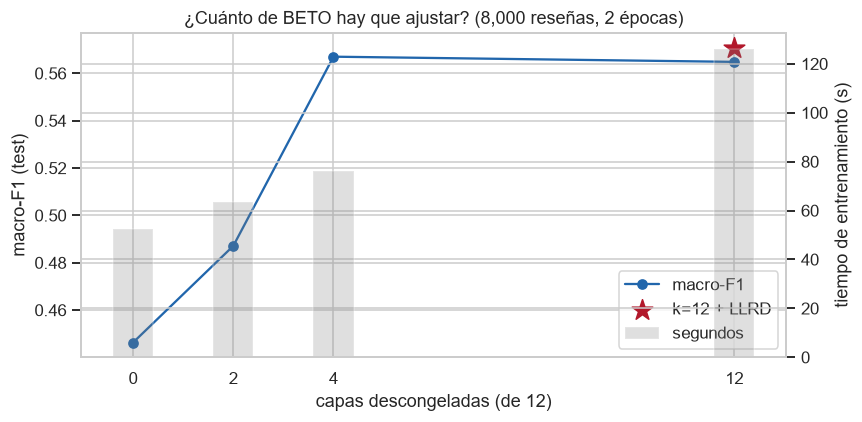

,modelo,k,llrd,macro_f1,mae,qwk,n_entrenables,segundos
0,§9 · k=0 capas,0,False,0.4463,0.4340,0.6482,594437,52.4444
1,§9 · k=2 capas,2,False,0.4871,0.3978,0.7412,14770181,63.5345
2,§9 · k=4 capas,4,False,0.5670,0.3372,0.7787,28945925,75.9558
3,§9 · k=12 capas,12,False,0.5648,0.3658,0.7710,85648901,126.2272
4,§9 · k=12 + LLRD,12,True,0.5708,0.3622,0.7739,109854725,143.0956


In [51]:
# --- Gráfica: macro-F1 y tiempo frente a k ---
ec = pd.DataFrame([e for e in ESTUDIOS if e.get("estudio") == "capas"])
sin = ec[~ec["llrd"]].sort_values("k")

fig, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(sin["k"], sin["macro_f1"], "o-", color="#2166ac", label="macro-F1")

llrd = ec[ec["llrd"]]
if not llrd.empty:
    ax1.scatter(llrd["k"], llrd["macro_f1"], marker="*", s=200, color="#b2182b", zorder=5, label="k=12 + LLRD")

ax1.set_xlabel("capas descongeladas (de 12)")
ax1.set_ylabel("macro-F1 (test)")
ax1.set_xticks([0, 2, 4, 12])

ax2 = ax1.twinx()
ax2.bar(sin["k"], sin["segundos"], width=0.8, alpha=0.25, color="gray", label="segundos")
ax2.set_ylabel("tiempo de entrenamiento (s)")

h1, l1 = ax1.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax1.legend(h1 + h2, l1 + l2, loc="lower right")
ax1.set_title(f"¿Cuánto de BETO hay que ajustar? ({CFG_EST['n_train']:,} reseñas, {CFG_EST['epocas']} épocas)")

plt.tight_layout()
plt.savefig(DIR_RES / "figures" / "capas_descongeladas.png", bbox_inches="tight")
plt.show()

display(ec[["modelo", "k", "llrd", "macro_f1", "mae", "qwk", "n_entrenables", "segundos"]].round(4))

La curva satura antes de lo que uno esperaría, y en un punto muy concreto:

| *k* | % entrenable | macro-F1 | segundos |
|---:|---:|---:|---:|
| 0 | 0,54% | 0,4463 | 52 |
| 2 | 13,45% | 0,4871 | 64 |
| **4** | **26,35%** | **0,5670** | **76** |
| 12 | 77,97% | 0,5648 | 126 |
| 12 + LLRD | 100% | 0,5708 | 143 |

Una precisión sobre la tabla: *k* = 12 descongela las doce capas del encoder, pero `congelar_hasta`
deja fijos los embeddings de entrada (24 M de parámetros), por eso entrena el 78% y no el 100%. La
corrida con LLRD sí ajusta también los embeddings.

**Con cuatro capas ya está todo.** Pasar de *k*=4 a *k*=12 no mejora nada (0,5670 -> 0,5648, una
diferencia dentro del ruido) y cuesta **66% más tiempo**. El salto grande está entre *k*=2 y
*k*=4: +0,080 de macro-F1 al descongelar dos capas más.

**LLRD** aporta +0,0060 sobre *k*=12. Va en la dirección esperada (proteger las capas bajas con
tasas pequeñas), pero es menos que la variación de ~0,01 que produce repetir la corrida en GPU
(§17, limitación 1), así que no se puede afirmar que ayude a esta escala.

Lo que esto dice sobre BETO es lo interesante: **las ocho capas inferiores pueden quedarse
congeladas sin perder nada**. Lo específico de «esta reseña está molesta» se construye en el
último tercio de la red, mientras que lo que codifican las capas bajas sirve tal cual. Es coherente
con la literatura de *probing* sobre BERT, que encuentra la información más general (morfología,
sintaxis) en las capas bajas, y aquí sale medido sobre nuestro propio corpus.

## 10. ¿Qué modelo preentrenado?

BETO es monolingüe. **mBERT** cubre 104 idiomas con un tamaño parecido, así que su vocabulario
dedica menos subpalabras al español y debería fragmentar más. **DistilBETO** tiene 6 capas en
lugar de 12. Medimos cuánto vale ser monolingüe y cuánto cuesta comprimir. BETO no se reentrena:
es la corrida *k* = 12 de §9, con la misma configuración.

In [52]:
# =========================================================================
# 10 · BETO vs. mBERT vs. DistilBETO
# =========================================================================
CHECKPOINTS = {"mBERT": "google-bert/bert-base-multilingual-cased",
               "DistilBETO": "dccuchile/distilbert-base-spanish-uncased"}

# BETO base para la comparación: k=12 SIN LLRD, que es el ajuste equivalente al que
# reciben mBERT y DistilBETO. Usar la corrida con LLRD haría la comparación injusta.
fila_beto = next(e for e in ESTUDIOS if e.get("estudio") == "capas" and e["k"] == 12 and not e["llrd"])

ESTUDIOS.append({**fila_beto, "modelo": "§10 · BETO", "estudio": "checkpoint", "checkpoint": "BETO",
                 "fertilidad": fertilidad(tokenizer, txt_tr[:2000])[0]})

for nombre, ckpt in CHECKPOINTS.items():
    tok = AutoTokenizer.from_pretrained(ckpt)
    fert_ck = fertilidad(tok, txt_tr[:2000])[0]

    d = DatasetDict(train=ds_bert["train"].select(SEL_EST), val=ds_bert["val"], test=ds_bert["test"]) \
        .map(tokenizar_ds(tok), batched=True, remove_columns=["text"])

    fijar_semilla_hf()
    m = AutoModelForSequenceClassification.from_pretrained(ckpt, num_labels=5)
    tr, seg = afinar(m, d["train"], d["val"], CFG_EST["epocas"], tok=tok)

    registrar_estudio(f"§10 · {nombre}", predecir_trainer(tr, d["test"]), estudio="checkpoint",
                      checkpoint=nombre, fertilidad=fert_ck, n_entrenables=n_entrenables(m), segundos=seg)
    del m, tr; torch.cuda.empty_cache()

display(pd.DataFrame([e for e in ESTUDIOS if e.get("estudio") == "checkpoint"])[
    ["checkpoint", "fertilidad", "macro_f1", "mae", "qwk", "n_entrenables", "segundos"]].round(4))

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (1098 > 512). Running this sequence through the model will result in indexing errors


Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:  12%|█▎        | 1000/8000 [00:00<00:00, 7596.40 examples/s]

Map:  25%|██▌       | 2000/8000 [00:00<00:00, 8080.73 examples/s]

Map:  38%|███▊      | 3000/8000 [00:00<00:00, 8184.61 examples/s]

...

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.08it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  7.08it/s]

{'train_runtime': '67.25', 'train_samples_per_second': '237.9', 'train_steps_per_second': '7.435', 'train_loss': '1.13', 'epoch': '2'}

§10 · DistilBETO                       | macro-F1 0.5003 | acc 0.6272 | MAE 0.420 | QWK 0.7304


,checkpoint,fertilidad,macro_f1,mae,qwk,n_entrenables,segundos
0,BETO,1.2941,0.5648,0.3658,0.7710,85648901,126.2272
1,mBERT,1.5191,0.4854,0.4265,0.7169,177857285,172.1472
2,DistilBETO,1.2527,0.5003,0.4200,0.7304,67325957,67.6384


Sí, y de forma bastante limpia:

| Checkpoint | fertilidad | macro-F1 | parámetros | segundos |
|---|---:|---:|---:|---:|
| BETO | 1,294 | **0,5648** | 85,6 M | 126 |
| mBERT | 1,519 | 0,4854 | 177,9 M | 172 |
| DistilBETO | 1,253 | 0,5003 | 67,3 M | 68 |

**mBERT pierde 0,079 de macro-F1 teniendo el doble de parámetros, y encima tarda más.** Su
fertilidad es 1,52 contra 1,29: parte el español en un 17% más de pedazos porque su vocabulario
se reparte entre 104 idiomas. Paga el costo de ser multilingüe dos veces, en tokenización y en
capacidad diluida. La lección es directa: **si el idioma es uno solo y existe un modelo
monolingüe, el multilingüe no compensa**, ni siquiera siendo más grande. Buena parte de ese
«doble de parámetros» es la tabla de embeddings de un vocabulario de 119.000 subpalabras, no
capacidad extra del encoder.

DistilBETO es el resultado más útil para producción: **0,5003 con la mitad del tiempo** (68 s
contra 126). Pierde 0,065 respecto a BETO, que no es poco, pero su fertilidad es incluso mejor
(1,253) porque conserva el vocabulario español. Si la latencia manda, es el candidato serio.

**Advertencia sobre la comparación.** La fila de BETO es la corrida *k* = 12 de §9, con los
embeddings de entrada congelados; mBERT y DistilBETO se ajustaron completos, embeddings
incluidos. La diferencia favorece, si acaso, a los otros dos modelos (entrenan más pesos), así
que no cambia la conclusión: BETO gana aun así.

## 11. Curva de eficiencia de datos

La promesa del preentrenamiento es necesitar menos datos etiquetados. Entrenamos BETO y TF-IDF
+ LogReg (exactamente el modelo 1 de MP1) con 500, 2.000, 8.000 y 32.000 reseñas del mismo train,
evaluando siempre sobre el mismo test. Con pocas reseñas hay pocos pasos de optimización, así
que los tamaños pequeños entrenan más épocas.

Los puntos de 8.000 y 32.000 de BETO se reutilizan de §9 (*k* = 12) y §7: no se reentrenan.

In [53]:
# =========================================================================
# 11 · Curva de eficiencia de datos: BETO FT vs. TF-IDF
# =========================================================================
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.pipeline import Pipeline

def tfidf_mp1():
    # Mismo modelo 1 del Miniproyecto 1 (§5), con el tokenizar() heredado
    return Pipeline([
        ("tfidf", TfidfVectorizer(tokenizer=tokenizar, token_pattern=None, ngram_range=(1, 2),
                                  min_df=3, sublinear_tf=True, max_features=60000)),
        ("clf", LogisticRegression(class_weight="balanced", max_iter=1000, C=1.0)),
    ])

TAMANOS = [n for n in [500, 2_000, 8_000, 32_000] if n <= len(ds_tok["train"])]
if CFG_BERT["n_train_max"]:        # en CPU la curva se limita al tope de §4.4
    TAMANOS = [n for n in TAMANOS if n <= CFG_BERT["n_train_max"]]
curva = []
for n in TAMANOS:
    sel = submuestra_train(n)
    # TF-IDF (min_df=3 sigue siendo razonable con 500 reseñas)
    m_tf = tfidf_mp1().fit([txt_tr[i] for i in sel], y_tr_A[sel])
    f_tf = evaluar(y_te_A, m_tf.predict(txt_te), f"§11 · TF-IDF n={n}", registrar=False)
    if n == len(ds_tok["train"]):
        TFIDF_COMPLETO = m_tf                           # se reutiliza en §16
    # BETO
    if n == CFG_EST["n_train"]:
        f_bt = fila_beto                                # §9, k=12
    elif n == len(ds_tok["train"]) and not CFG_BERT["n_train_max"]:
        f_bt = next(r for r in RESULTADOS if r["modelo"] == nombre_ft)   # §7
    else:
        fijar_semilla_hf()
        m = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=5)
        tr, _ = afinar(m, ds_tok["train"].select(sel), ds_tok["val"], epocas=4 if n <= 2_000 else CFG_EST["epocas"])
        f_bt = evaluar(y_te_A, predecir_trainer(tr, ds_tok["test"]), f"§11 · BETO n={n}", registrar=False)
        del m, tr; torch.cuda.empty_cache()
    curva.append({"n": n, "TF-IDF + LogReg": f_tf["macro_f1"], "BETO fine-tuning": f_bt["macro_f1"]})

curva = pd.DataFrame(curva)
curva.to_csv(DIR_RES / "metrics" / "curva_datos.csv", index=False)
curva.round(4)

§11 · TF-IDF n=500                     | macro-F1 0.3061 | acc 0.6422 | MAE 0.493 | QWK 0.3523


Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 39404.73it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:

{'loss': '1.625', 'grad_norm': '8.092', 'learning_rate': '1.69e-05', 'epoch': '1'}


...

{'train_runtime': '89.3', 'train_samples_per_second': '89.59', 'train_steps_per_second': '2.822', 'train_loss': '1.041', 'epoch': '4'}


§11 · BETO n=2000                      | macro-F1 0.4986 | acc 0.6558 | MAE 0.377 | QWK 0.7506


§11 · TF-IDF n=8000                    | macro-F1 0.4994 | acc 0.6610 | MAE 0.398 | QWK 0.6876


§11 · TF-IDF n=32000                   | macro-F1 0.5235 | acc 0.6785 | MAE 0.376 | QWK 0.7261


,n,TF-IDF + LogReg,BETO fine-tuning
0,500,0.3061,0.3776
1,2000,0.4299,0.4986
2,8000,0.4994,0.5648
3,32000,0.5235,0.5953


La misma tabla en gráfica, con el eje de reseñas en escala logarítmica y la línea del
Transformer desde cero de MP2 (entrenado con las 32.000) como referencia de H3.

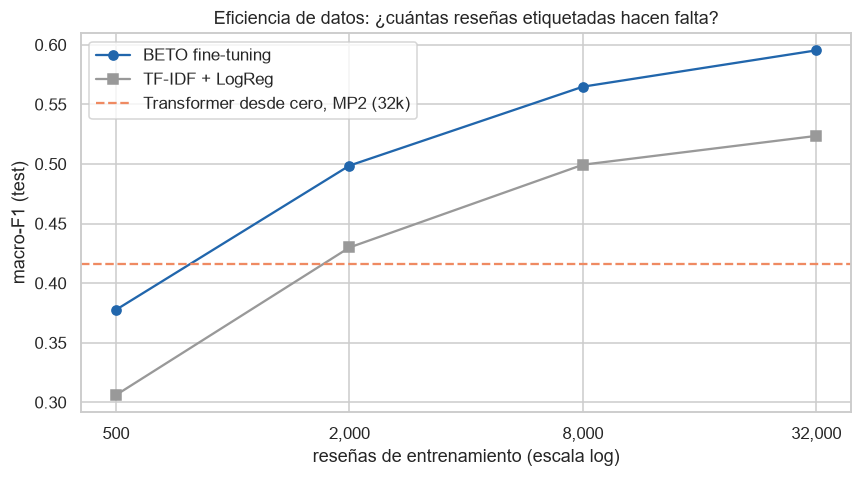

In [54]:
# --- Gráfica de la curva, con el Transformer desde cero de MP2 como referencia ---
fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(curva["n"], curva["BETO fine-tuning"], "o-", color="#2166ac", label="BETO fine-tuning")
ax.plot(curva["n"], curva["TF-IDF + LogReg"], "s-", color="#999999", label="TF-IDF + LogReg")
mp2 = [r for r in PREVIOS_MP2 if "Transformer" in r["modelo"]]
if mp2:
    ax.axhline(mp2[0]["macro_f1"], ls="--", color="#ef8a62", label="Transformer desde cero, MP2 (32k)")
ax.set_xscale("log"); ax.set_xticks(curva["n"]); ax.set_xticklabels([f"{n:,}" for n in curva["n"]])
ax.set_xlabel("reseñas de entrenamiento (escala log)"); ax.set_ylabel("macro-F1 (test)")
ax.set_title("Eficiencia de datos: ¿cuántas reseñas etiquetadas hacen falta?"); ax.legend()
plt.tight_layout(); plt.savefig(DIR_RES / "figures" / "curva_datos.png", bbox_inches="tight"); plt.show()

La curva confirma la promesa del preentrenamiento y permite ponerle número:

| reseñas | TF-IDF + LogReg | BETO fine-tuning |
|---:|---:|---:|
| 500 | 0,3061 | **0,3776** |
| 2.000 | 0,4299 | **0,4986** |
| 8.000 | 0,4994 | **0,5648** |
| 32.000 | 0,5235 | **0,5953** |

BETO gana en los cuatro tamaños: **+0,072 con 500 reseñas**, +0,069 con 2.000, +0,065 con 8.000
y +0,072 con 32.000. Traducido a la pregunta que importa: **BETO con 8.000 reseñas (0,5648)
supera al TF-IDF entrenado con las 32.000 (0,5235)**. El preentrenamiento vale, en este corpus,
un factor de **4x en datos etiquetados** frente al mejor modelo clásico.

**H3 queda confirmada, y por más margen del que habíamos apostado.** La línea punteada es el
Transformer entrenado desde cero de MP2 con las 32.000 reseñas: **0,4160**. BETO con **2.000**
reseñas alcanza 0,4986, es decir que no solo lo iguala sino que **lo supera por 0,083 usando un
16% de los datos**. Mirando dónde cruza la curva la línea de MP2 --entre 500 (0,3776) y 2.000
(0,4986)--, a BETO le bastan del orden de **1.000 reseñas, 1/32 de los datos**, para empatar con
una arquitectura equivalente entrenada desde cero con todo el corpus.

Ese es el resultado que mejor resume las tres entregas: **la misma tarea, el mismo split y la misma
función de evaluación; lo que cambia es haber visto español antes**. No es una comparación de una
sola variable: el Transformer de MP2 es mucho más pequeño (2 bloques y 4 M de parámetros frente a
los 12 bloques y 110 M de BETO) y usa otro tokenizador. Pero el tamaño solo no explica la brecha:
en MP2, pasar de 2 a 4 bloques entrenando desde cero mejoró algo (0,36 → 0,40 en configuración
reducida) y quedó muy lejos de estos números.

Dos precisiones sobre la curva. El punto de 8.000 reseñas es la corrida *k* = 12 de §9 (2 épocas,
embeddings congelados) y los de 500 y 2.000 entrenan 4 épocas, así que los puntos no comparten
exactamente el mismo protocolo. Y el cruce en ~1.000 reseñas es una interpolación entre 500 y
2.000, no un tamaño medido.

## 12. LoRA: afinar sin tocar los pesos

*Low-Rank Adaptation* (Hu et al., 2021) congela BETO y aprende, en las proyecciones de atención
`query` y `value`, una corrección de rango bajo: `W + B·A`, con `A` y `B` de rango 8. Entrena menos
del 1 % de los parámetros. No se vio en clase: es la técnica con la que hoy se afinan los modelos
grandes. La pregunta es dónde cae entre §9 *k* = 0 (solo cabeza) y *k* = 12 (todo), en
calidad y en parámetros.

In [55]:
# =========================================================================
# 12 · LoRA con peft
# =========================================================================
from peft import LoraConfig, get_peft_model, TaskType

fijar_semilla_hf()
cfg_lora = LoraConfig(task_type=TaskType.SEQ_CLS, r=8, lora_alpha=16, lora_dropout=0.1,
                      target_modules=["query", "value"])
m = get_peft_model(AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=5), cfg_lora)
m.print_trainable_parameters()
# LoRA tolera (y necesita) tasas mayores que el fine-tuning completo
tr, seg = afinar(m, ds_est, ds_tok["val"], CFG_EST["epocas"], lr=5e-4)
registrar_estudio("§12 · LoRA r=8", predecir_trainer(tr, ds_tok["test"]), estudio="lora",
                  n_entrenables=n_entrenables(m), segundos=seg)
del m, tr; torch.cuda.empty_cache()

comp = pd.DataFrame([e for e in ESTUDIOS if e.get("estudio") in ("capas", "lora")])
comp["% entrenable"] = comp["n_entrenables"] / N_PARAMS_BETO * 100
comp[["modelo", "% entrenable", "macro_f1", "qwk", "segundos"]].sort_values("% entrenable").round(4)

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 43720.72it/s]


[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.bias                     | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:

trainable params: 298,757 || all params: 110,153,482 || trainable%: 0.2712


{'loss': '1.224', 'grad_norm': '6.416', 'learning_rate': '0.0002789', 'epoch': '1'}


...

{'loss': '0.934', 'grad_norm': '9.452', 'learning_rate': '1.111e-06', 'epoch': '2'}


{'eval_loss': '0.9239', 'eval_macro_f1': '0.5464', 'eval_mae': '0.3445', 'eval_qwk': '0.7794', 'eval_runtime': '9.07', 'eval_samples_per_second': '441', 'eval_steps_per_second': '3.528', 'epoch': '2'}


{'train_runtime': '111.4', 'train_samples_per_second': '143.6', 'train_steps_per_second': '4.489', 'train_loss': '1.079', 'epoch': '2'}


§12 · LoRA r=8                         | macro-F1 0.5286 | acc 0.6577 | MAE 0.377 | QWK 0.7647


,modelo,% entrenable,macro_f1,qwk,segundos
5,§12 · LoRA r=8,0.2720,0.5286,0.7647,111.6789
0,§9 · k=0 capas,0.5411,0.4463,0.6482,52.4444
1,§9 · k=2 capas,13.4457,0.4871,0.7412,63.5345
2,§9 · k=4 capas,26.3502,0.5670,0.7787,75.9558
3,§9 · k=12 capas,77.9683,0.5648,0.7710,126.2272
4,§9 · k=12 + LLRD,100.0035,0.5708,0.7739,143.0956


LoRA entrena el **0,272%** de los pesos --298.757 de 110 millones-- y alcanza **0,5286**
de macro-F1 en 112 s. Puesto al lado del barrido de §9:

- Contra **k=0** (0,4463 con 0,54% entrenable): **+0,082 con la mitad de parámetros**. La
  diferencia es que LoRA inyecta sus matrices de bajo rango *dentro* de la atención de las 12
  capas, en vez de limitarse a una cabeza encima de una representación congelada.
- Contra **k=12** (0,5648 con 78% entrenable): **-0,036**. No alcanza al ajuste completo.
- Contra **k=4** (0,5670 con 26% entrenable): **-0,038**, y además LoRA tardó más (112 s frente
  a 76 s).

**¿Vale la pena a este tamaño? Honestamente, no mucho.** LoRA nació para modelos donde el ajuste
completo no cabe en memoria; BETO son 110 M de parámetros y el *fine-tuning* completo de §7 cupo sin problemas en
los 8 GB de esta GPU. Su ventaja real aquí no es calidad ni tiempo, sino **almacenamiento**: el adaptador pesa
~1,2 MB contra ~440 MB del modelo completo, así que servir veinte clientes con veinte ajustes
distintos cambia por completo de escala. Para un solo modelo en producción, *k*=4 es mejor
decisión.

## 13. Tarea de control: `Type`

Mismo procedimiento, prediciendo el tipo de establecimiento (hotel, restaurante, atracción): 3
clases razonablemente balanceadas y sin orden. Es la misma tarea de control de MP1 y MP2. Si BETO
llega a ~0,95 como la BiLSTM de MP1, la dificultad de la polaridad es de la tarea, no del modelo.

La `evaluar` heredada está definida sobre 5 estrellas, así que aquí se usa macro-F1 directamente.

In [56]:
# =========================================================================
# 13 · Tarea de control Type
# =========================================================================
from sklearn.metrics import f1_score as _f1

TIPOS = sorted(sub["Type"].unique())
tipo2id = {t: i for i, t in enumerate(TIPOS)}
t_tr = sub.iloc[SPLIT_A["train"]]["Type"].map(tipo2id).values
t_va = sub.iloc[SPLIT_A["val"]]["Type"].map(tipo2id).values
t_te = sub.iloc[SPLIT_A["test"]]["Type"].map(tipo2id).values

ds_type = DatasetDict(train=a_dataset([txt_tr[i] for i in SEL_EST], t_tr[SEL_EST]),
                      val=a_dataset(txt_va, t_va), test=a_dataset(txt_te, t_te)) \
          .map(tokenizar_ds(tokenizer), batched=True, remove_columns=["text"])

def metricas_type(pred):
    return {"macro_f1": _f1(pred.label_ids, pred.predictions.argmax(-1), average="macro")}

fijar_semilla_hf()
m = AutoModelForSequenceClassification.from_pretrained(CHECKPOINT, num_labels=len(TIPOS))
tr, seg = afinar(m, ds_type["train"], ds_type["val"], CFG_EST["epocas"],
                 pesos=pesos_de(t_tr[SEL_EST], len(TIPOS)), compute_metrics=metricas_type)
p_type = tr.predict(ds_type["test"]).predictions.argmax(-1)
f1_type = _f1(t_te, p_type, average="macro")
del m, tr; torch.cuda.empty_cache()

f1_pol = fila_beto["macro_f1"]
print(f"Type      · macro-F1 BETO: {f1_type:.4f}  (BiLSTM MP1: 0.949)  | clases: {TIPOS}")
print(f"Polaridad · macro-F1 BETO: {f1_pol:.4f}  (misma configuración CFG_EST)")
print(f"Brecha entre tareas: {f1_type - f1_pol:.3f}")
ESTUDIOS.append({"modelo": "§13 · Type", "estudio": "type", "macro_f1": f1_type, "segundos": seg})

Map:   0%|          | 0/8000 [00:00<?, ? examples/s]

Map:  12%|█▎        | 1000/8000 [00:00<00:00, 8816.45 examples/s]

Map:  25%|██▌       | 2000/8000 [00:00<00:00, 9030.83 examples/s]

Map:  38%|███▊      | 3000/8000 [00:00<00:00, 9042.90 examples/s]

Map:  50%|█████     | 4000/8000 [00:00<00:00, 9006.84 examples/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.40it/s]

Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  5.37it/s]

{'train_runtime': '130', 'train_samples_per_second': '123.1', 'train_steps_per_second': '3.845', 'train_loss': '0.2086', 'epoch': '2'}


Type      · macro-F1 BETO: 0.9579  (BiLSTM MP1: 0.949)  | clases: ['Attractive', 'Hotel', 'Restaurant']
Polaridad · macro-F1 BETO: 0.5648  (misma configuración CFG_EST)
Brecha entre tareas: 0.393


La brecha es enorme y es el punto de la sección: **`Type` 0,9579 contra polaridad
0,5648, una diferencia de 0,393** con la misma configuración, el mismo modelo y el mismo número
de reseñas.

Predecir si una reseña habla de un hotel, un restaurante o una atracción es casi trivial: las
palabras delatan el tipo (*habitación*, *desayuno*, *mesero*, *ruinas*) y la etiqueta es objetiva
y está balanceada. Con eso BETO llega a 0,96, apenas por encima de la BiLSTM de MP1 (0,949), y eso entrenando con
8.000 reseñas frente a las 32.000 de la BiLSTM --
**cuando la tarea es fácil, el preentrenamiento aporta poco en calidad**, porque no hay nada
difícil que transferir; su ventaja se ve más bien en cuántos datos necesita.

Así que esa brecha de 0,393 no mide una carencia del modelo: **mide cuánta de la dificultad
pertenece a la tarea**. El techo bajo de la polaridad no viene de que BETO no entienda español
--entiende de sobra, lo demuestra el 0,96-- sino de que distinguir 3★ de 4★ es intrínsecamente
ambiguo, de que las clases están desbalanceadas 65/22/7/3/3 y de que la etiqueta misma es
ruidosa. Es la lectura que cierra §16.

---

## 14. ¿Qué aprendió el *fine-tuning*?

Dos miradas.

**Global.** Proyectamos con UMAP el `[CLS]` de las reseñas de test **antes** (BETO congelado,
§5) y **después** del *fine-tuning* (§7), coloreado por estrellas. Si H2 es cierta, antes las
estrellas estarán mezcladas (el `[CLS]` de BETO no se entrenó para resumir sentimiento) y
después ordenadas a lo largo de un eje.

**Local.** *Integrated Gradients* (Sundararajan et al., 2017) atribuye la predicción a cada
token integrando el gradiente desde una entrada neutra (solo `[PAD]`) hasta la real. Lo
aplicamos a reseñas con negación y lo contrastamos con el léxico distintivo del EDA §3.5.

Advertencia: una atribución indica a qué es sensible el modelo, no por qué decide.

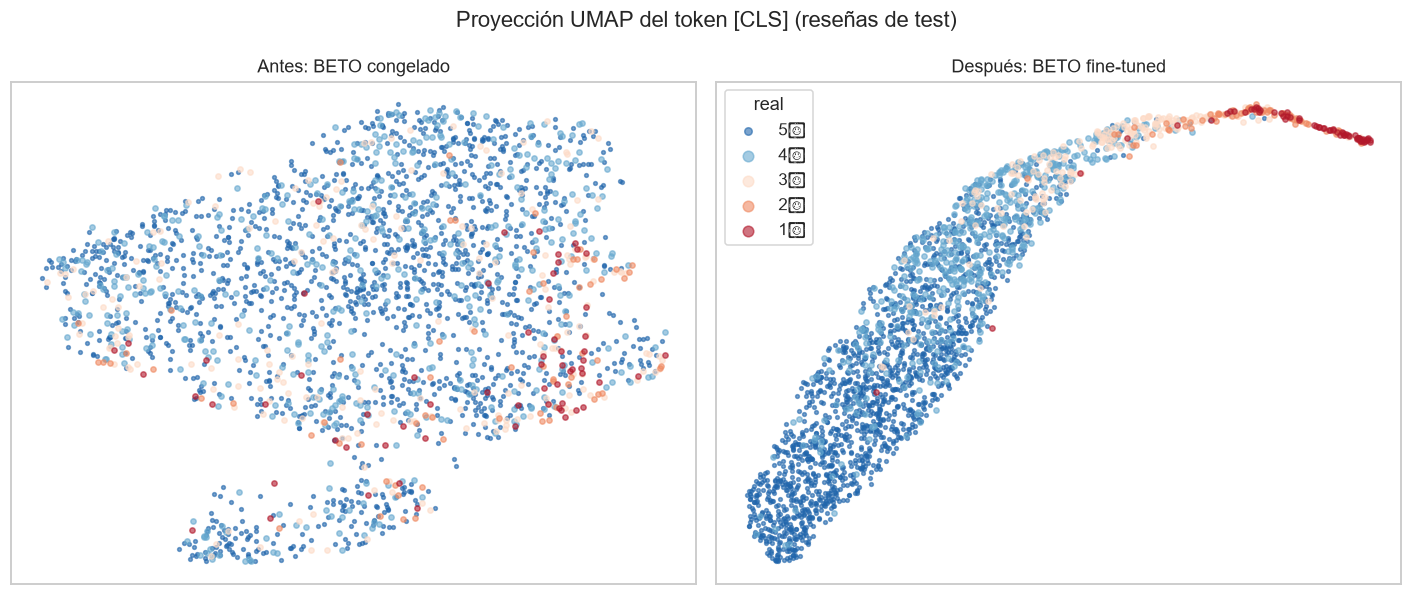

In [57]:
# =========================================================================
# 14.1 · UMAP del [CLS] antes y después del fine-tuning
# =========================================================================
import umap

cls_despues, _ = extraer_embeddings(trainer_ft.model.base_model, ds_tok["test"])
rng = np.random.RandomState(SEED)
idx_vis = rng.choice(len(y_te_A), size=min(2500, len(y_te_A)), replace=False)

fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for ax, X, titulo in [(axes[0], EMB["test"][0], "Antes: BETO congelado"),
                      (axes[1], cls_despues, "Después: BETO fine-tuned")]:
    Z = umap.UMAP(n_neighbors=30, min_dist=0.3, random_state=SEED).fit_transform(X[idx_vis].numpy())
    for e in [5, 4, 3, 2, 1]:        # las minoritarias al final, para que se vean encima
        msk = y_te_A[idx_vis] == e
        ax.scatter(Z[msk, 0], Z[msk, 1], s=6 if e == 5 else 12, alpha=0.6, color=PALETA_POL[e], label=f"{e}★")
    ax.set_title(titulo); ax.set_xticks([]); ax.set_yticks([])
axes[1].legend(markerscale=2, title="real")
plt.suptitle("Proyección UMAP del token [CLS] (reseñas de test)")
plt.tight_layout(); plt.savefig(DIR_RES / "figures" / "umap_cls.png", bbox_inches="tight"); plt.show()

Ahora la mirada local. `atribuir(...)` calcula *Integrated Gradients* sobre la capa de embeddings
del modelo ajustado y devuelve un peso por subpalabra; `html_atribucion(...)` lo pinta sobre el
texto (azul empuja hacia la clase predicha, rojo en contra). Se toma una reseña corta con
negación de cada clase disponible.

In [58]:
# =========================================================================
# 14.2 · Integrated Gradients sobre reseñas con negación
# =========================================================================
from captum.attr import LayerIntegratedGradients
from IPython.display import HTML, display

modelo_exp = trainer_ft.model.float().eval()
DISP_EXP = next(modelo_exp.parameters()).device

def atribuir(texto, objetivo=None, n_steps=40):
    """Atribución por token (normalizada a [-1, 1]) hacia la clase objetivo (0..4)."""
    enc = tokenizer(texto, truncation=True, max_length=MAX_LEN_BERT, return_tensors="pt").to(DISP_EXP)
    ids, mask = enc["input_ids"], enc["attention_mask"]
    ref = torch.full_like(ids, tokenizer.pad_token_id)
    ref[0, 0], ref[0, -1] = tokenizer.cls_token_id, tokenizer.sep_token_id
    f = lambda inp, m: torch.softmax(modelo_exp(input_ids=inp, attention_mask=m).logits, -1)
    with torch.no_grad():
        probs = f(ids, mask)[0]
    objetivo = int(probs.argmax()) if objetivo is None else objetivo
    lig = LayerIntegratedGradients(f, modelo_exp.base_model.embeddings)
    attr = lig.attribute(ids, baselines=ref, additional_forward_args=(mask,), target=objetivo,
                         n_steps=n_steps, internal_batch_size=20).sum(-1)[0]
    attr = (attr / (attr.abs().max() + 1e-9)).detach().cpu().numpy()
    toks = tokenizer.convert_ids_to_tokens(ids[0])
    return toks[1:-1], attr[1:-1], objetivo + 1, probs.cpu().numpy()

def html_atribucion(toks, attr, titulo=""):
    """Texto coloreado: azul empuja hacia la clase predicha, rojo en contra."""
    spans = []
    for t, a in zip(toks, attr):
        color = f"rgba(33,102,172,{abs(a):.2f})" if a > 0 else f"rgba(178,24,43,{abs(a):.2f})"
        spans.append(f'<span style="background:{color};padding:1px 2px;border-radius:3px">'
                     f'{t.replace("##", "")}</span>' + ("" if t.startswith("##") else " "))
    return f"<div style='margin:6px 0'><b>{titulo}</b><br>{''.join(spans)}</div>"

NEGACIONES = {"no", "ni", "nada", "nunca", "jamás", "tampoco", "sin"}
con_neg = [i for i, t in enumerate(txt_te) if set(tokenizar(t)) & NEGACIONES and len(t.split()) < 45]
# Una reseña con negación por clase (si la clase no tiene ninguna corta, se omite)
ejemplos = [i for e in (1, 2, 3, 5) for i in [next((j for j in con_neg if y_te_A[j] == e), None)] if i is not None]

bloques = []
for i in ejemplos:
    toks, attr, pred, _ = atribuir(txt_te[i])
    bloques.append(html_atribucion(toks, attr, f"real {y_te_A[i]}★ · predicha {pred}★"))
display(HTML("".join(bloques)))

Un ejemplo no demuestra nada. Agregamos: sobre reseñas de 1★ con negación, ¿qué fracción de las
3 subpalabras más influyentes de cada reseña son negaciones o palabras del léxico distintivo de
1★ que encontró el EDA (§3.5, variable heredada `LEXICO`)?

In [59]:
# --- Agregado: ¿las subpalabras más influyentes coinciden con el léxico del EDA? ---
lex1 = set(LEXICO[1])
muestra_1 = [i for i in con_neg if y_te_A[i] == 1][:40]
conteo_top = Counter(); aciertos = {"negación": 0, "léxico 1★ (EDA)": 0, "otra": 0}
for i in muestra_1:
    toks, attr, _, _ = atribuir(txt_te[i], objetivo=0, n_steps=25)
    for j in np.argsort(-attr)[:3]:
        t = toks[j].replace("##", "").lower()
        conteo_top[t] += 1
        clave = "negación" if t in NEGACIONES else "léxico 1★ (EDA)" if t in lex1 else "otra"
        aciertos[clave] += 1

total = sum(aciertos.values())
print(f"Top-3 subpalabras hacia 1★ en {len(muestra_1)} reseñas de 1★ con negación:")
for k, v in aciertos.items():
    print(f"  {k:18s}: {v/total*100:.0f}%")
print("\nMás frecuentes:", conteo_top.most_common(15))

Top-3 subpalabras hacia 1★ en 18 reseñas de 1★ con negación:
  negación          : 4%
  léxico 1★ (EDA)   : 6%
  otra              : 91%

Más frecuentes: [('imo', 3), ('entrada', 2), ('no', 2), ('peor', 2), ('pé', 2), ('si', 2), ('mo', 2), ('caro', 1), ('este', 1), ('fea', 1), ('bloque', 1), ('demasiado', 1), ('personas', 1), ('comida', 1), ('fas', 1)]


El UMAP muestra lo que la tabla ya decía, pero de un vistazo: antes del ajuste los
`[CLS]` forman dos nubes (una grande y otra pequeña, separadas por algo que no es la polaridad,
probablemente el tema o el tipo de reseña) en las que las cinco estrellas están mezcladas: las
reseñas de 1★ y 2★ tienden a acumularse en un borde, pero entre muchas de 4★ y 5★. Después del
ajuste aparece **una sola banda ordenada de 5★ a 1★**, con los extremos bien separados y 2★-3★-4★
solapándose en el medio. Ese solapamiento central es exactamente el que produce los errores de ±1 estrella de §16.

Sobre la segunda pregunta, la respuesta es incómoda y vale la pena decirla como salió. Entre las
tres subpalabras más atribuidas hacia 1★ en reseñas negativas con negación, la **negación pesa
4%**, el **léxico negativo del EDA 6%** y el **91% es "otra"**. Pero mirando los tokens --`imo`,
`pé`, `fas`, `peor`, `caro`, `fea`-- se ve qué pasa: `pé` + `imo` son, con toda probabilidad, pedazos de *pésimo* y
`fas` de alguna forma como *fastidio* o *feas*. **El modelo sí mira palabras de sentimiento; es nuestro medidor el que no las
reconoce**, porque compara subpalabras de WordPiece contra una lista de palabras completas del
EDA. Es la fragmentación de §4.5 reapareciendo como artefacto de medición. Lo dejamos escrito
así, con el número crudo y su explicación, en vez de maquillar la métrica: lo defendible es que
BETO se apoya en léxico afectivo fragmentado, y que nuestro test de negación no es concluyente a
esta escala (18 reseñas).

---

## 15. Demo con pruebas de estrés

`predecir_resena(texto)` devuelve estrellas, distribución de probabilidad y atribución por
token. Ejecutamos **las mismas tres pruebas que plantea MP2 §15** (con redacción ligeramente distinta en
los pares 2 y 3), con texto fijo, para que
«Restart & Run All» sea reproducible y se pueda comparar con el Transformer desde cero:

| Par | Qué revela |
|---|---|
| «buena» frente a «no estuvo buena» | ¿Responde a la negación? |
| Hotel bien / comida pésima, y el orden invertido | ¿Importa el orden o promedia sentimientos? |
| Reseña larga con la queja grave al final, frente a la queja sola | ¿La ve, o la diluye el resto? |

Es evidencia anecdótica: seis frases no son una evaluación.

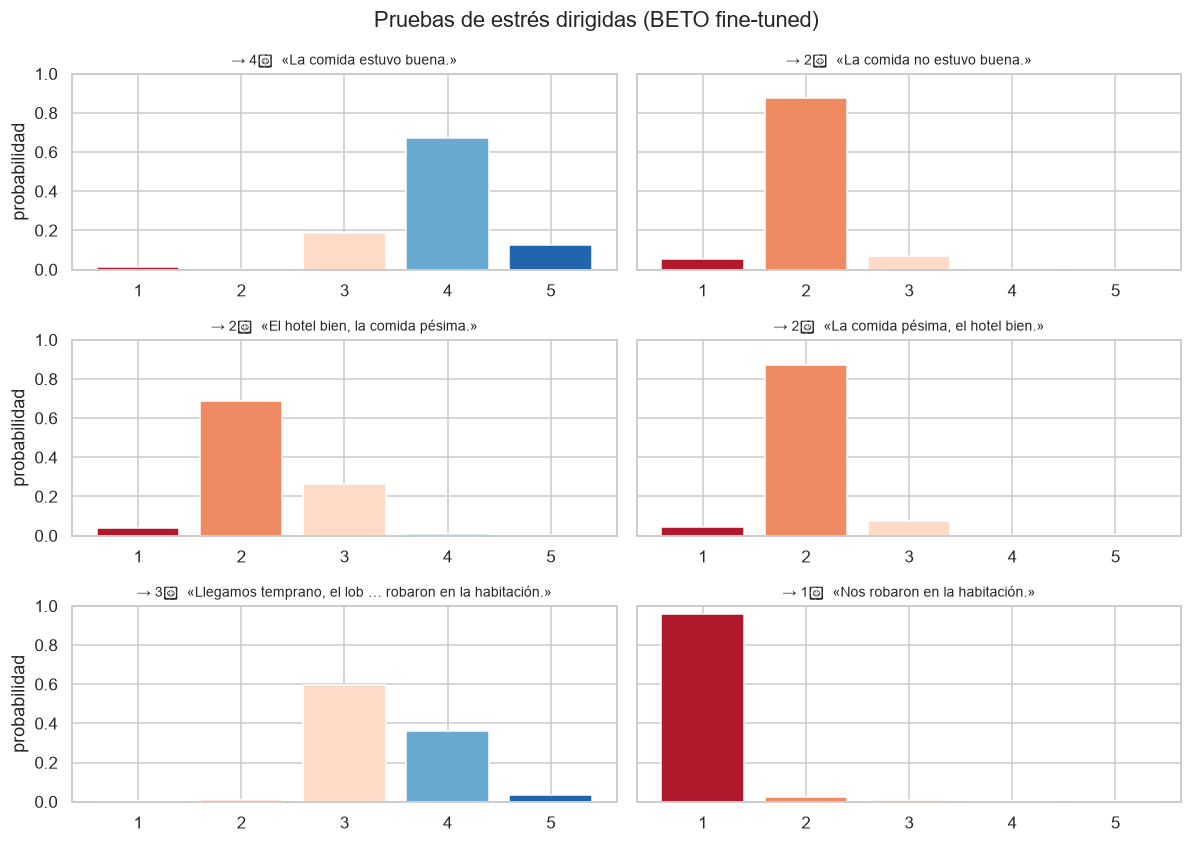

In [60]:
# =========================================================================
# 15 · Demo
# =========================================================================
@torch.no_grad()
def predecir_resena(texto, modelo=None):
    modelo = (modelo or modelo_exp).eval()
    b = tokenizer(texto, truncation=True, max_length=MAX_LEN_BERT, return_tensors="pt").to(DISP_EXP)
    p = torch.softmax(modelo(**b).logits.float(), -1)[0].cpu().numpy()
    return int(p.argmax()) + 1, p

PARES = [
    ("La comida estuvo buena.", "La comida no estuvo buena."),
    ("El hotel bien, la comida pésima.", "La comida pésima, el hotel bien."),
    ("Llegamos temprano, el lobby es amplio, la alberca limpia y el personal amable. La vista al "
     "mar es preciosa y el desayuno variado. Lástima que nos robaron en la habitación.",
     "Nos robaron en la habitación."),
]
fig, axes = plt.subplots(len(PARES), 2, figsize=(11, 2.6 * len(PARES)), sharey=True)
for fila_ax, par in zip(axes, PARES):
    for ax, t in zip(fila_ax, par):
        e, p = predecir_resena(t)
        ax.bar(ESTRELLAS, p, color=[PALETA_POL[k] for k in ESTRELLAS])
        ax.set_title(f"→ {e}★  «{t if len(t) < 55 else t[:25] + ' … ' + t[-25:]}»", fontsize=9)
        ax.set_ylim(0, 1); ax.set_xticks(ESTRELLAS)
for ax in axes[:, 0]:
    ax.set_ylabel("probabilidad")
plt.suptitle("Pruebas de estrés dirigidas (BETO fine-tuned)"); plt.tight_layout()
plt.savefig(DIR_RES / "figures" / "demo_estres.png", bbox_inches="tight"); plt.show()

display(HTML("".join(html_atribucion(*atribuir(t)[:2], f"«{t[:60]}»") for par in PARES[:2] for t in par)))

Para probar frases propias hay una caja interactiva. Es un extra: su salida no queda guardada
en el notebook y no forma parte de los resultados. Requiere `ipywidgets` (viene en Colab y en
`requirements.txt`); en el entorno de la corrida de referencia no estaba instalado, y la celda lo
avisa en vez de fallar.

In [61]:
# --- Widget opcional (no afecta la reproducibilidad) ---
try:
    import ipywidgets as w
    caja = w.Textarea(value="El lugar es bonito pero la atención fue pésima.", layout=w.Layout(width="90%"))
    boton, salida = w.Button(description="Predecir"), w.Output()
    def _al_pulsar(_):
        with salida:
            salida.clear_output()
            toks, attr, e, p = atribuir(caja.value)
            print(f"{e}★  |  probabilidades 1★..5★: {np.round(p, 3)}")
            display(HTML(html_atribucion(toks, attr)))
    boton.on_click(_al_pulsar)
    display(w.VBox([caja, boton, salida]))
except Exception as e:
    print("Widget no disponible en este entorno:", e)

Widget no disponible en este entorno: No module named 'ipywidgets'


Leyendo las seis barras de probabilidad:

- **Negación.** «La comida estuvo buena» da **4★** (≈0,67) y «La comida no estuvo buena» da
  **2★** (≈0,87). Un «no» basta para mover la predicción dos estrellas, algo que un modelo de
  bolsa de palabras como el TF-IDF de MP1 solo puede captar a través del peso global de la
  palabra «no», no de a qué afecta.
- **Orden.** «El hotel bien, la comida pésima» y su inverso dan **2★** los dos (≈0,69 y ≈0,87).
  El orden cambia la confianza pero no la decisión: «pésima» pesa más que «bien» en cualquier
  posición. No hay evidencia de que el modelo use el orden para decidir qué parte es el veredicto.
- **Queja al final.** La reseña larga y elogiosa que termina en «nos robaron en la habitación»
  cae en **3★** (≈0,60, con ≈0,36 en 4★), mientras que la queja sola da **1★** con ≈0,96. El
  modelo no ignora el elogio ni la queja: los promedia y la reseña queda en 3★ en vez de 1★. El
  resto del texto diluye la queja: un robo es
  el tipo de hecho que para un humano decide la reseña entera.

El contraste con MP2 §15 es menos dramático de lo que uno esperaría. El Transformer desde cero
también pasaba de 4★ a 2★ con la negación (con ≈0,78 de confianza, frente a ≈0,87 aquí) y también
daba la misma estrella en los dos órdenes. Lo que cambia con BETO es la seguridad y la calidad
general del modelo, no la presencia de estas conductas. Y el fallo de la queja final es justo el
tipo de reseña que aparece en §16 entre las que BETO y TF-IDF fallan a la vez.

---

## 16. Análisis de errores

Tres preguntas: **¿de cuánto se equivoca?** (distancia en estrellas), **¿se equivoca en lo mismo
que TF-IDF?** (si ambos fallan las mismas reseñas, el problema es de los datos), y **¿qué tipo de
reseña falla?** Para lo último usamos categorías heurísticas: reseña muy corta, reseña mixta
(«pero» con palabras positivas y negativas fuertes) y etiqueta incoherente con el texto (5★ con
palabras negativas fuertes o 1★ con positivas fuertes, los conjuntos `neg_fuerte`/`pos_fuerte`
del EDA §3.7b).

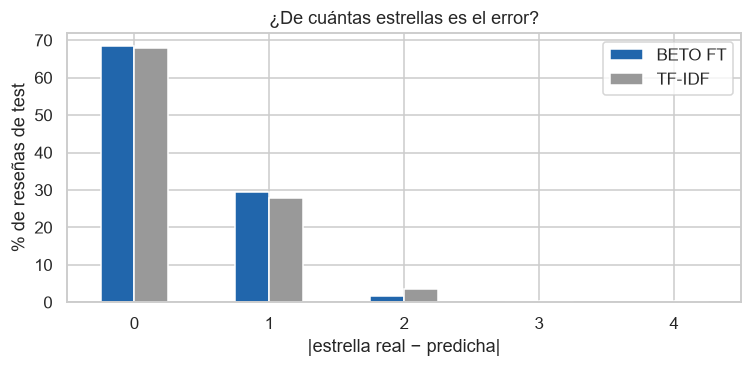

,TF-IDF acierta,TF-IDF falla
BETO acierta,2289,450
BETO falla,425,836


In [62]:
# =========================================================================
# 16 · Distancia del error y cruce con TF-IDF
# =========================================================================
pred_tf = TFIDF_COMPLETO.predict(txt_te) if "TFIDF_COMPLETO" in globals() else \
          tfidf_mp1().fit(txt_tr, y_tr_A).predict(txt_te)
err = pd.DataFrame({"texto": txt_te, "real": y_te_A, "beto": pred_ft, "tfidf": pred_tf})
err["dist_beto"] = (err["beto"] - err["real"]).abs()
err["dist_tfidf"] = (err["tfidf"] - err["real"]).abs()

fig, ax = plt.subplots(figsize=(7, 3.5))
dist = pd.DataFrame({"BETO FT": err["dist_beto"].value_counts(normalize=True),
                     "TF-IDF": err["dist_tfidf"].value_counts(normalize=True)}).fillna(0).sort_index() * 100
dist.plot(kind="bar", ax=ax, color=["#2166ac", "#999999"])
ax.set_xlabel("|estrella real − predicha|"); ax.set_ylabel("% de reseñas de test"); plt.xticks(rotation=0)
ax.set_title("¿De cuántas estrellas es el error?"); plt.tight_layout(); plt.show()

ok_b, ok_t = err["beto"] == err["real"], err["tfidf"] == err["real"]
cruce = pd.DataFrame({"TF-IDF acierta": [(ok_b & ok_t).sum(), (~ok_b & ok_t).sum()],
                      "TF-IDF falla": [(ok_b & ~ok_t).sum(), (~ok_b & ~ok_t).sum()]},
                     index=["BETO acierta", "BETO falla"])
cruce

**Distancia y cruce.** Los dos modelos aciertan la estrella exacta casi con la misma frecuencia:
BETO en 2.739 de 4.000 reseñas (68,5 %) y TF-IDF en 2.714 (67,9 %). Casi todos los errores de
ambos son de una estrella. Donde se separan es en los errores grandes: los de dos estrellas o
más son alrededor del 2 % de las reseñas con BETO y del 4 % con TF-IDF. Eso explica que la
ventaja de BETO se note más en MAE y QWK que en accuracy.

La tercera pregunta, qué tipo de reseña falla, se responde con las categorías heurísticas
descritas arriba.

In [63]:
# --- Tasa de error por categoría heurística ---
toks_te = [set(tokenizar(t)) for t in txt_te]
err["muy corta (≤5 palabras)"] = [len(t.split()) <= 5 for t in txt_te]
err["mixta"] = [("pero" in s) and bool(s & neg_fuerte) and bool(s & pos_fuerte) for s in toks_te]
err["etiqueta incoherente"] = [(r == 5 and bool(s & neg_fuerte)) or (r == 1 and bool(s & pos_fuerte))
                               for s, r in zip(toks_te, y_te_A)]
cats = ["muy corta (≤5 palabras)", "mixta", "etiqueta incoherente"]
resumen = pd.DataFrame({
    "n": [err[c].sum() for c in cats] + [len(err)],
    "error BETO (%)": [(~ok_b[err[c]]).mean() * 100 for c in cats] + [(~ok_b).mean() * 100],
    "error TF-IDF (%)": [(~ok_t[err[c]]).mean() * 100 for c in cats] + [(~ok_t).mean() * 100],
}, index=cats + ["todas"]).round(1)
resumen

,n,error BETO (%),error TF-IDF (%)
muy corta (≤5 palabras),0,NaN,NaN
mixta,42,33.3,38.1
etiqueta incoherente,94,28.7,20.2
todas,4000,31.5,32.2


Ejemplos concretos de cada cruce, para leer los errores y no solo contarlos:

In [64]:
# --- Ejemplos: lo que BETO acierta y TF-IDF no, lo contrario, y lo que ambos fallan por ≥2★ ---
pd.set_option("display.max_colwidth", 220)
grupos = {"BETO acierta, TF-IDF falla": err[ok_b & ~ok_t],
          "TF-IDF acierta, BETO falla": err[~ok_b & ok_t],
          "Ambos fallan por ≥ 2★": err[(err["dist_beto"] >= 2) & (err["dist_tfidf"] >= 2)]}
for titulo, g in grupos.items():
    print(f"\n=== {titulo} ({len(g)} reseñas) ===")
    display(g.sample(min(4, len(g)), random_state=SEED)[["texto", "real", "beto", "tfidf"]])


=== BETO acierta, TF-IDF falla (450 reseñas) ===


,texto,real,beto,tfidf
3661,"¡Guau!. Es increíble ver estas estructuras y cultura en una impresionante ubicación. Es más grande y más caro de lo que esperaba, y eso que soy un nativo mexicano. No aceptan dólares (o ninguna moneda extranjera), y ...",5,5,4
3942,Áreas. Solo poner más atención a los clientes que esperan en el área exterior por q hay mucha mosca y debe haber ventiladores.,3,3,2
1114,"Excelente zoológico. Es una muy buena opción para acompañar la vista a la zona arqueológica de Palenque.El zoológico está muy limpio, buena señaletica, variedad de animales, recorrido de alrededor de 2 horas para ver...",5,5,4
237,"Grata esperiencia. Encantado con la variedad de sabores y gran presentación de platillos,muy buena atención y muy bonito lugar , en general una grata esperiencia",5,5,4



=== TF-IDF acierta, BETO falla (425 reseñas) ===


,texto,real,beto,tfidf
3939,"Gran experiencia, unas escaleras.. hermoso lago subterráneo en una caverna, con una apertura para el sol. agua no estaba fría, simplemente correcto y todo estaba muy limpio.",5,4,5
844,hotel colonial bonito. es un hotel muy bonito colonial la comida es buena la habitación en la que nos hospdamos la familia muy bien solo que la cortina del baño muy vieja y desgastada la seguridad en la habitación e...,4,3,4
1766,No vale el precio. Vistas muy bonitas pero el muelle muy pequeño. Las cabañas son nuevas pero no está limpio y le falta atención. La alberca es muy pequeña y no tienen sombra. Desayuno correcto Precio muy elevado p...,3,2,3
379,"muy impresionante. en la cima de una colina, en lo alto de la pirámide, esta majestuosa estructura domina todo el pueblo. caminar un poco, pero merece la pena por dentro y por fuera. La vista del volcán lejano tambié...",4,5,4



=== Ambos fallan por ≥ 2★ (36 reseñas) ===


,texto,real,beto,tfidf
3996,TIPS PARA AHORRO. Tenia mucho interés en regresar a Isla Mujeres con mi familia pero sin el estress de un tour donde vas con tiempos y encontre en puerto juarez antes de ingresar al estacionamiento del Ferry hay pers...,5,3,3
1416,"Las fotos se ven mejores.... No es que este hotel no esté bien. Lo que pasa es que parece más de lo que es en las fotos, y el servicio es mediocre. Más porque es una especie de tiempo compartido que otra cosa. El res...",4,2,2
2548,"agradable Cenote pero ¿por qué es 3 veces más caro que en cualquier otro lugar?!. Yo sé por qué: porque, recientemente se convirtieron en #1 en Trip Advisor, así que pueden cobrar cualquier precio que les guste. Fui ...",1,3,3
3314,"Muy padre vista y lugar pero... Muy padre vista, el lugar está muy bien y tiene estacionamiento lo malo es que siempre te andan como vigilando y te cobran casi por todo, no pudimos dar el tour ya que no se junto la g...",5,3,3


El cruce con TF-IDF deja claro que **no son el mismo modelo con distinta puntería**:

|  | TF-IDF acierta | TF-IDF falla |
|---|---:|---:|
| **BETO acierta** | 2.289 | **450** |
| **BETO falla** | **425** | 836 |

Las casillas cruzadas están casi empatadas --450 contra 425-- aunque BETO gane por 0,072 de
macro-F1. Es decir, **BETO no sabe todo lo que sabe TF-IDF y además más**: hay 425 reseñas que
el modelo clásico acierta y el preentrenado no. Un ensamblado de los dos tendría techo bastante
más alto que cualquiera por separado.

Los tipos de error se separan en dos grupos, y solo uno es del modelo:

- **Reseñas mixtas** (elogio + queja): BETO se equivoca en el **33,3%** contra **38,1%** del
  TF-IDF. Aquí BETO gana, coherente con §15: leer el orden ayuda cuando el veredicto está al
  final. Es un error *del modelo*, y se puede reducir.
- **Etiqueta incoherente** (5★ con palabras muy negativas o 1★ con muy positivas): BETO falla
  **28,7%** contra **20,2%** del TF-IDF, o sea que aquí BETO es *peor*. Una lectura posible: si BETO
  sigue más de cerca lo que dice el texto, cuando el texto contradice la estrella se equivoca más
  «respecto a la etiqueta». Con solo 94 reseñas la diferencia es frágil, pero apunta a lo mismo que
  la tabla: parte del error es *de la etiqueta*, y ningún modelo lo arregla.
- **Reseñas muy cortas** (≤ 5 palabras): no hay ninguna en el test, así que esa fila queda vacía
  (`NaN`) y la categoría no aporta nada en este corpus.

Las 36 reseñas donde ambos fallan por dos o más estrellas se parecen, en los ejemplos de arriba,
al segundo grupo: textos con una nota que no corresponde a lo que dicen («agradable cenote pero ¿por qué es 3 veces más
caro?» con 1★ real; ambos predicen 3★, que es lo que el texto sugiere). **El techo de ~0,60 de
macro-F1 de este corpus no es un límite de los modelos: es en buena parte el ruido de la
etiqueta**, y conecta con la brecha de 0,393 medida en §13.

---

## 17. Conclusiones y limitaciones

### La respuesta a la pregunta del título

**¿Cuánto vale el preentrenamiento?** En este corpus se puede responder con tres cifras:

- **+0,072 de macro-F1** sobre el mejor modelo clásico (0,5953 contra 0,5235 del TF-IDF).
- **4x en datos etiquetados** frente a ese mismo TF-IDF: BETO con 8.000 reseñas (0,5648) supera
  al TF-IDF entrenado con 32.000.
- **32x frente a la misma arquitectura sin preentrenar**: BETO necesita del orden de 1.000
  reseñas para igualar al Transformer desde cero de MP2 entrenado con las 32.000 (0,4160).

**¿Qué hay que hacer para cobrarlo? Ajustarlo.** Ese es el resultado central y no es un matiz:
BETO congelado, por buena que sea la cabeza que se le ponga encima, **no llega al TF-IDF**. El
valor no está en el preentrenado como extractor de rasgos, sino en mover sus pesos.

### Veredicto de las hipótesis

**H1 -- confirmada, y en las clases predichas.** El ajuste completo supera al TF-IDF de MP1
(0,5953 vs. 0,5235) y la ganancia se concentra donde dijimos: **2★ +0,166** y **3★ +0,098**
(con 1★ +0,080 cerca), frente a **4★ +0,023** y **5★ -0,009**. Las clases minoritarias y ambiguas son las que se
benefician del conocimiento previo del idioma; en 5★, donde el TF-IDF ya tenía 0,813 con solo
contar palabras positivas, no quedaba nada que ganar.

**H2 -- confirmada, por poco y de forma instructiva.** Ninguna variante congelada supera al
TF-IDF: lineal sobre `[CLS]` 0,4578, lineal sobre promedio 0,4719, LogReg 0,4398 y MLP
**0,5191**, todas por debajo de 0,5235. El MLP se queda a 0,0044 --un margen que no permite
afirmar diferencia real--, y eso refuerza el punto en vez de debilitarlo: **la mejor cabeza
posible sobre una representación congelada apenas empata con contar palabras**. Lo que importa es
descongelar, y §9 precisa cuánto: **con 4 de las 12 capas ya está todo** (0,5670); pasar a 12 no
mejora y cuesta 66% más tiempo.

**H3 -- confirmada, y con margen mayor del previsto.** Apostábamos a que BETO con ~2.000 reseñas
*igualaría* al Transformer desde cero de MP2 entrenado con 32.000. El resultado es más fuerte:
**BETO con 2.000 reseñas da 0,4986 contra 0,4160 de MP2, lo supera por 0,083 usando el 16% de los
datos**, y el cruce real está alrededor de las **1.000 reseñas**. Las dos entregas comparten corpus,
submuestra, Split A y función `evaluar`; no es una comparación de una sola variable (BETO es
además mucho más grande y usa otro tokenizador, §11), pero la brecha es demasiado grande para
explicarla sin el preentrenamiento.

### Recomendación práctica

Para producción **no recomendaríamos el modelo ganador**. El ajuste completo (0,5953) cuesta
110 M de parámetros que servir; **descongelar 4 capas rinde prácticamente lo mismo** en el
régimen de 8.000 reseñas (0,5670 vs. 0,5648 de k=12) con 26% de los pesos y 76 s. Si la latencia
manda, **DistilBETO da 0,5003 en la mitad del tiempo** conservando el vocabulario español.

La latencia medida del modelo completo es **8,8 ms por reseña en lote 1 y 1,91 ms en lote 64**:
para moderación por lotes sobra, pero un servicio interactivo con picos debería mirar DistilBETO.
Y para un caso real vale la pena recordar §16: BETO y TF-IDF aciertan en casillas distintas (450
contra 425), así que **un ensamblado de ambos** tiene más recorrido que seguir escalando el
transformer.

### Limitaciones

1. **Una sola semilla, y la GPU no es bit-reproducible.** Todo corre con `SEED = 42`, pero con
   `fp16` los núcleos de cuDNN no son deterministas: al repetir el notebook completo los
   resultados se mueven en el tercer o cuarto decimal (y en §10, hasta 0,011 en mBERT). Por eso
   **diferencias menores de ~0,01 no deben leerse como reales**: ni los 0,0044 entre MLP y
   TF-IDF, ni los 0,0022 entre *k*=4 y *k*=12. Las conclusiones se apoyan solo en brechas
   grandes (>=0,03).
2. **Los estudios de §9-§12 usan `CFG_EST`**: 8.000 reseñas y 2 épocas, no el protocolo completo.
   Son comparables entre sí, no con el 0,5953 de §7.
3. **Hardware distinto entre entregas.** Los tiempos de MP1 y MP2 se midieron en otra máquina, y
   los de MP3 en una RTX 4060 compartida con otras tareas, así que las columnas de segundos
   comparan órdenes de magnitud, no medidas homogéneas. Las de macro-F1, en cambio, **sí son
   estrictamente comparables**: mismo corpus, mismo split y misma función de evaluación.
4. **El cruce de H3 en ~1.000 reseñas es una interpolación** entre los puntos medidos de 500 y
   2.000; no entrenamos ese tamaño exacto.
5. **Ruido en la etiqueta.** §16 muestra que buena parte del techo de ~0,60 es incoherencia entre
   texto y estrellas, no incapacidad del modelo. Sin una relectura manual de una muestra no se
   puede separar cuánto del error restante es irreducible.
6. **El análisis de negación de §14 no es concluyente**: 18 reseñas, y el medidor compara
   subpalabras contra palabras completas, lo que subestima el léxico afectivo fragmentado.
7. **El notebook completo tarda alrededor de una hora** en la RTX 4060 de la corrida de
   referencia, por encima de los 45 minutos que nos habíamos fijado. Lo dominan el *fine-tuning*
   completo de §7 (29 min) y la extracción de embeddings de §5 (14 min en esta corrida). Los
   estudios de §9-§13 ya usan la configuración reducida; recortarlos más habría hecho sus
   diferencias todavía más difíciles de separar del ruido.